In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression


In [3]:
data_dir = os.path.expanduser("~/DataFiles")
racmo_smb_file = data_dir + "/smbgl_monthlyS_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_t2m_file = data_dir + "/tas_monthlyA_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_mask_file = data_dir + "/TotIS_RACMO_ANT27_IMBIE2.nc"
ant11_mask_file = data_dir + "/ANT11_masks.nc"
ant27_ref_file  = data_dir + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc"
accum_data_file   = data_dir + "/AccumCoresData.csv"
water_data_file   = data_dir + "/WaterCoresData.csv"
accum_coords_file = data_dir + "/AccumCoresCoords.csv"
water_coords_file = data_dir + "/WaterCoresCoords.csv"


In [4]:
smb_ds = xr.open_dataset(racmo_smb_file)
smb_ann = (smb_ds["smbgl"].squeeze("height").groupby("time.year").sum("time").sel(year=slice(1979, 2025)))
t2m_ds = xr.open_dataset(racmo_t2m_file)
t2m_ann = (t2m_ds["tas"].squeeze("height").groupby("time.year").mean("time").sel(year=slice(1979, 2025)))
lat_racmo, lon_racmo = smb_ann["lat"].values, smb_ann["lon"].values
NY, NX = lat_racmo.shape; years_obs = smb_ann["year"].values
print("ANT11 grid:", (NY, NX), " years", int(years_obs.min()), "-", int(years_obs.max()))



ANT11 grid: (591, 726)  years 1979 - 2025


In [5]:
mask_ds = xr.open_dataset(ant11_mask_file)
cell_area_m2 = mask_ds["Area"].values * 1e6
ice_sheet    = mask_ds["Icesheet_Only"].values == 1
def to_xyz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)
ref27 = xr.open_dataset(ant27_ref_file)["smb"].squeeze("height")
lat27, lon27 = ref27["lat"].values, ref27["lon"].values
gi = xr.open_dataset(racmo_mask_file)["GroundedIce"].values
gi = np.where(np.isfinite(gi), gi, 0).astype(int); _gm = gi > 0
_, _idx = cKDTree(to_xyz(lat27[_gm].ravel(), lon27[_gm].ravel())).query(to_xyz(lat_racmo.ravel(), lon_racmo.ravel()))
basin_mask = np.where(ice_sheet.ravel(), gi[_gm].ravel()[_idx], 0).reshape(NY, NX)
grounded_mask = np.load(os.path.expanduser("~/DataFiles/ANT11_grounded_mask.npy"))
basin_mask = np.where(grounded_mask, basin_mask, 0)      # drop floating ice shelves -> grounded ice only

basin_flat = basin_mask.reshape(-1); valid_cells = basin_flat > 0
basin_ids  = basin_flat[valid_cells].astype(int); basin_ids_unique = np.unique(basin_ids)
region_names = ["AIS", "WAIS", "EAIS", "AP"]
print("grounded cells:", int(valid_cells.sum()))


grounded cells: 101022


In [6]:
def basin_sums_Gt(field3d, years):
    mass = field3d * cell_area_m2
    df = pd.DataFrame(index=list(np.asarray(years)), columns=basin_ids_unique, dtype=float)
    for t, yr in enumerate(np.asarray(years)):
        flat = mass[t].reshape(-1)[valid_cells]
        s = pd.DataFrame({"basin": basin_ids, "m": flat}).groupby("basin")["m"].sum() / 1e12
        df.loc[yr, s.index] = s.values
    return df


In [7]:
smb_basin_obs = basin_sums_Gt(smb_ann.values, years_obs)
ais_rac  = smb_basin_obs.sum(axis=1).astype(float)
wais_rac = smb_basin_obs[[3,7,8,9,10]].sum(axis=1).astype(float)
eais_rac = smb_basin_obs[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float)
ap_rac   = smb_basin_obs[[4,5,6]].sum(axis=1).astype(float)
raw_series = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}


In [8]:
accum_data_raw = pd.read_csv(accum_data_file, header=None)
water_data_raw = pd.read_csv(water_data_file, header=None)
def extract_cores(raw_df, yr_min, yr_max, transpose=True):
    years_col = raw_df.iloc[2:, 0].astype(int)
    m = (years_col >= yr_min) & (years_col <= yr_max)
    arr = raw_df.iloc[2:, 1:][m].to_numpy()[::-1].astype(float)
    return arr.T if transpose else arr
N_CAL = 42; CAL_YEARS = slice(1979, 2020); recon_years = np.arange(1801, 2001)
accum_cores_cal  = extract_cores(accum_data_raw, 1979, 2020)
water_cores_cal  = extract_cores(water_data_raw, 1979, 2020)
accum_cores_full = extract_cores(accum_data_raw, 1801, 2000, transpose=False)
water_cores_full = extract_cores(water_data_raw, 1801, 2000, transpose=False)
accum_coords = pd.read_csv(accum_coords_file, header=None)
water_coords = pd.read_csv(water_coords_file, header=None)
core_lats  = accum_coords.iloc[:, 2].values; core_lons  = (accum_coords.iloc[:, 3].values + 360) % 360
water_lats = water_coords.iloc[:, 2].values; water_lons = (water_coords.iloc[:, 3].values + 360) % 360
print("accum cores:", accum_cores_full.shape[1], " water cores:", water_cores_full.shape[1])


accum cores: 84  water cores: 80


In [9]:
def nearest_ij(lat2d, lon2d, tlat, tlon):
    lon360 = (lon2d + 360) % 360
    d2 = (lat2d - tlat)**2 + (lon360 - (tlon + 360) % 360)**2
    return np.unravel_index(np.argmin(d2), d2.shape)
smb_cal = smb_ann.sel(year=CAL_YEARS).values; t2m_cal = t2m_ann.sel(year=CAL_YEARS).values
accum_pts = np.zeros((84, N_CAL)); R_accum = np.zeros(84)
for i in range(84):
    j, k = nearest_ij(lat_racmo, lon_racmo, core_lats[i], core_lons[i])
    smb_pt = smb_cal[:, j, k]; obs = accum_cores_cal[i, :]; accum_pts[i, :] = smb_pt
    v = np.isfinite(obs) & np.isfinite(smb_pt)
    reg = LinearRegression().fit(smb_pt[v].reshape(-1,1), obs[v].reshape(-1,1))
    R_accum[i] = np.var(obs[v].reshape(-1,1) - reg.predict(smb_pt[v].reshape(-1,1)), ddof=1)
_valid = np.isfinite(accum_cores_cal) & np.isfinite(accum_pts)
_off = (np.nanmean(np.where(_valid, accum_cores_cal, np.nan), axis=1)
        - np.nanmean(np.where(_valid, accum_pts, np.nan), axis=1))
y_e_accum = accum_pts + _off[:, None]
y_e_water = np.zeros((80, N_CAL)); R_water = np.zeros(80)
for i in range(80):
    j, k = nearest_ij(lat_racmo, lon_racmo, water_lats[i], water_lons[i])
    t_pt = t2m_cal[:, j, k]; obs = water_cores_cal[i, :]
    v = np.isfinite(obs) & np.isfinite(t_pt)
    reg = LinearRegression().fit(t_pt[v].reshape(-1,1), obs[v].reshape(-1,1))
    y_e_water[i, :] = t_pt * reg.coef_[0][0] + reg.intercept_[0]
    R_water[i] = np.var(obs[v].reshape(-1,1) - reg.predict(t_pt[v].reshape(-1,1)), ddof=1)
y_e_smb = np.vstack([y_e_accum, y_e_water]); R_smb_diag = np.concatenate([R_accum, R_water])
proxy_smb = np.hstack([accum_cores_full, water_cores_full])
print("PSMs ready:", y_e_smb.shape)


PSMs ready: (164, 42)


In [10]:
def run_ensrf_spatial_unc(prior_cells, y_e, R_diag_vec, proxy_data_full, n_proxy, integ):
    Ns = prior_cells.shape[1]
    post_mean = np.zeros((200, Ns), np.float32); post_std = np.zeros((200, Ns), np.float32)
    reg_ens = np.zeros((200, N_CAL, integ.shape[0]))
    for i in range(200):
        X_mean = prior_cells.mean(axis=0); X_dev = prior_cells - X_mean
        for j in range(n_proxy):
            if np.isnan(proxy_data_full[i, j]): continue
            y_mean = y_e[j, :].mean(); y_var = np.var(y_e[j, :], ddof=1)
            if not np.isfinite(y_mean) or y_var == 0: continue
            y_dev = y_e[j, :] - y_mean
            K = ((X_dev.T @ y_dev) / (N_CAL - 1)) / (y_var + R_diag_vec[j])
            X_mean = X_mean + K * (proxy_data_full[i, j] - y_mean)
            alpha = 1.0 / (1.0 + np.sqrt(R_diag_vec[j] / (y_var + R_diag_vec[j])))
            X_dev = X_dev - alpha * np.outer(y_dev, K)
        post_mean[i] = X_mean; post_std[i] = X_dev.std(axis=0, ddof=1)
        reg_ens[i] = (integ @ (X_mean[None, :] + X_dev).T).T
    return post_mean, post_std, reg_ens


In [11]:
_va = cell_area_m2.reshape(-1)[valid_cells]
_regions = {"AIS": basin_ids > 0, "WAIS": np.isin(basin_ids,[3,7,8,9,10]),
            "EAIS": np.isin(basin_ids,[1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(basin_ids,[4,5,6])}
A_smb   = np.vstack([np.where(_regions[r], _va, 0) / 1e12 for r in region_names])
A_basin = np.vstack([np.where(basin_ids == b, _va, 0) / 1e12 for b in basin_ids_unique])
A_all   = np.vstack([A_smb, A_basin])

smb_cells = smb_ann.sel(year=CAL_YEARS).values.reshape(N_CAL, -1)[:, valid_cells].astype(np.float32)
print("Running SMB EnSRF (%d grounded cells) ..." % smb_cells.shape[1])
smb_post_v, smb_std_v, reg_ens_all = run_ensrf_spatial_unc(smb_cells, y_e_smb, R_smb_diag, proxy_smb, 164, A_all)

smb_reg_ens_raw   = reg_ens_all[:, :, :4]
smb_basin_ens_raw = reg_ens_all[:, :, 4:]
racmo_smb_recon_raw = np.full((200, NY*NX), np.nan, np.float32)
racmo_smb_recon_raw[:, valid_cells] = smb_post_v
racmo_smb_recon_raw = racmo_smb_recon_raw.reshape(200, NY, NX)
smb_reg_mean_raw = smb_reg_ens_raw.mean(1); smb_reg_std_raw = smb_reg_ens_raw.std(1, ddof=1)
print("Raw reconstruction ready.")



Running SMB EnSRF (101022 grounded cells) ...
Raw reconstruction ready.


In [12]:
W, FMAX, TAPER_YRS = 31, 5.0, 0        # TAPER_YRS>0 ramps the factor back to 1 over N years after the split
SPLIT_YEAR = 1956                      # <-- tweakable: correction applied THROUGH this year (inclusive)
BASE_END   = 1900                      # baseline + GGM window end — held FIXED at 1900

i_split = int(np.clip(SPLIT_YEAR - 1801 + 1, 0, 200))   # first uncorrected index
i_base  = BASE_END - 1801 + 1                            # = 100, fixed

_r = lambda x: pd.Series(np.asarray(x, float)).rolling(W, center=True, min_periods=max(4, W//2))
roll_mean = lambda x: _r(x).mean().values
roll_var  = lambda x: _r(x).var(ddof=1).values
dvar = lambda x: np.var(np.asarray(x,float)-np.polyval(np.polyfit(np.arange(len(x)),np.asarray(x,float),1),
                                                        np.arange(len(x))), ddof=1)

# --- LTV amplitude per region over the FIXED 1801-BASE_END window (feeds the null) ---
reg_var_raw = smb_reg_ens_raw.var(1, ddof=1)
sig_total_ltv = {}
for k, r in enumerate(region_names):
    v_mean = dvar(smb_reg_mean_raw[0:i_base, k]); v_post = reg_var_raw[0:i_base, k].mean()
    sig_total_ltv[r] = np.sqrt(v_mean + v_post)
    print(f"{r}: sigma_mean {np.sqrt(v_mean):6.1f}   LTV total {sig_total_ltv[r]:6.1f}   "
          f"x{sig_total_ltv[r]/np.sqrt(v_mean):.2f}")

# --- per-basin time-varying factor, applied only through SPLIT_YEAR ---
mean_b = smb_basin_ens_raw.mean(1); var_b = smb_basin_ens_raw.var(1, ddof=1)
f_b = np.ones_like(mean_b)
for b in range(mean_b.shape[1]):
    v_mean, v_post = roll_var(mean_b[:, b]), roll_mean(var_b[:, b])
    f = np.sqrt((v_mean + v_post) / np.maximum(v_mean, 1e-12))
    f_b[:, b] = np.clip(pd.Series(f).ffill().bfill().values, 1.0, FMAX)

f_use = f_b.copy()
f_use[i_split:, :] = 1.0                                   # uncorrected from SPLIT_YEAR+1 onward
if TAPER_YRS > 0:                                          # optional smooth hand-off at the split
    f_edge = f_b[max(i_split-1, 0), :]
    for j in range(TAPER_YRS):
        i = i_split + j
        if i < f_use.shape[0]:
            f_use[i, :] = 1.0 + (f_edge - 1.0) * (1.0 - (j+1)/TAPER_YRS)
print(f"split at {SPLIT_YEAR}: factor there = {f_b[max(i_split-1,0)].mean():.2f}  "
      f"(set TAPER_YRS>0 to smooth the hand-off)")

# --- build the working series: corrected mean, spread preserved; baseline fixed to 1801-BASE_END ---
base_b   = mean_b[0:i_base].mean(0)
mean_cor = base_b + (mean_b - base_b) * f_use
smb_basin_ens = mean_cor[:, None, :] + (smb_basin_ens_raw - mean_b[:, None, :])
bcol = {b: i for i, b in enumerate(basin_ids_unique)}
reg_cols = {"AIS":  [bcol[b] for b in basin_ids_unique],
            "WAIS": [bcol[b] for b in [3,7,8,9,10] if b in bcol],
            "EAIS": [bcol[b] for b in [1,2,11,12,13,14,15,16,17,18] if b in bcol],
            "AP":   [bcol[b] for b in [4,5,6] if b in bcol]}
smb_reg_ens  = np.stack([smb_basin_ens[:, :, reg_cols[r]].sum(2) for r in region_names], axis=2)
smb_reg_mean = smb_reg_ens.mean(1); smb_reg_std = smb_reg_ens.std(1, ddof=1)
ais_rac_recon, wais_rac_recon, eais_rac_recon, ap_rac_recon = (smb_reg_mean[:, k] for k in range(4))
ais_rac_std,  wais_rac_std,  eais_rac_std,  ap_rac_std      = (smb_reg_std[:, k]  for k in range(4))
smb_std_by_region = {"AIS": ais_rac_std, "WAIS": wais_rac_std, "EAIS": eais_rac_std, "AP": ap_rac_std}
recon_series = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}

bcell = np.full((NY, NX), -1, int)
for i, b in enumerate(basin_ids_unique): bcell[basin_mask == b] = i
valid2d = bcell >= 0
cellmean = np.nanmean(racmo_smb_recon_raw[:i_base], axis=0)
fcell = f_use[:, np.where(valid2d, bcell, 0)]; fcell[:, ~valid2d] = 1.0
racmo_smb_recon = cellmean[None] + (racmo_smb_recon_raw - cellmean[None]) * fcell
smb_basin_recon = basin_sums_Gt(racmo_smb_recon, recon_years)
print(f"Working series: LTV-corrected 1801-{SPLIT_YEAR}, raw {SPLIT_YEAR+1}-2000.")






AIS: sigma_mean   87.1   LTV total  108.0   x1.24
WAIS: sigma_mean   82.7   LTV total   85.7   x1.04
EAIS: sigma_mean   69.2   LTV total   90.1   x1.30
AP: sigma_mean   30.9   LTV total   36.4   x1.18
split at 1956: factor there = 1.19  (set TAPER_YRS>0 to smooth the hand-off)


/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_42183/3291816055.py:61: RuntimeWarning: Mean of empty slice
  cellmean = np.nanmean(racmo_smb_recon_raw[:i_base], axis=0)


Working series: LTV-corrected 1801-1956, raw 1957-2000.


In [13]:
def _ggm_psi(kappa, phi, K):
    d = 0.5*kappa; a = 1.0-phi; psi = np.empty(K); psi[0] = 1.0
    for k in range(1, K): psi[k] = psi[k-1]*(d+k-1.0)/k*a
    return psi
def _ggm_acf(kappa, phi, n, K=None):
    if K is None: K = int(min(20000, max(2000, 30*n if phi > 0.02 else 20000)))
    psi = _ggm_psi(kappa, phi, K+n)
    return np.array([np.dot(psi[:K], psi[h:h+K]) for h in range(n)])
def _toeplitz(r):
    n = len(r); idx = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :]); return r[idx]
def ggm_fit(x, kappa0=1.0, phi0=0.1, bounds=((0.0,4.0),(1e-4,1.0))):
    from scipy.optimize import minimize
    x = np.asarray(x, float); x = x - x.mean(); n = len(x)
    def negll(th):
        r = _ggm_acf(th[0], th[1], n)
        try: L = np.linalg.cholesky(_toeplitz(r))
        except np.linalg.LinAlgError: return 1e12
        z = np.linalg.solve(L, x); s2 = (z@z)/n
        return 0.5*(n*np.log(2*np.pi*s2) + 2.0*np.log(np.diag(L)).sum() + n)
    res = minimize(negll, [kappa0, phi0], method="L-BFGS-B", bounds=bounds)
    r = _ggm_acf(*res.x, n); L = np.linalg.cholesky(_toeplitz(r)); z = np.linalg.solve(L, x)
    return dict(kappa=res.x[0], phi=res.x[1], sigma_w=np.sqrt((z@z)/n))

ggm_fits = {}
for k, r in enumerate(region_names):
    f_raw = ggm_fit(smb_reg_mean_raw[0:100, k])                    # SHAPE from RAW mean (old)
    f     = ggm_fit(smb_reg_mean[0:100, k])                        # SHAPE from VARIANCE-CORRECTED mean (new)
    marg = np.sqrt(_ggm_acf(f["kappa"], f["phi"], 1)[0]) * f["sigma_w"]
    f["sigma_w"] *= sig_total_ltv[r] / marg                        # AMPLITUDE from LTV (unchanged)
    ggm_fits[r] = f
    print(f"{r}: kappa {f['kappa']:.2f} (raw was {f_raw['kappa']:.2f})  phi {f['phi']:.3f}  "
          f"sigma_w {f['sigma_w']:.1f}  (= LTV {sig_total_ltv[r]:.1f})")





AIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 108.0  (= LTV 108.0)
WAIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 85.7  (= LTV 85.7)
EAIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 90.1  (= LTV 90.1)
AP: kappa 0.63 (raw was 0.63)  phi 0.014  sigma_w 32.6  (= LTV 36.4)


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


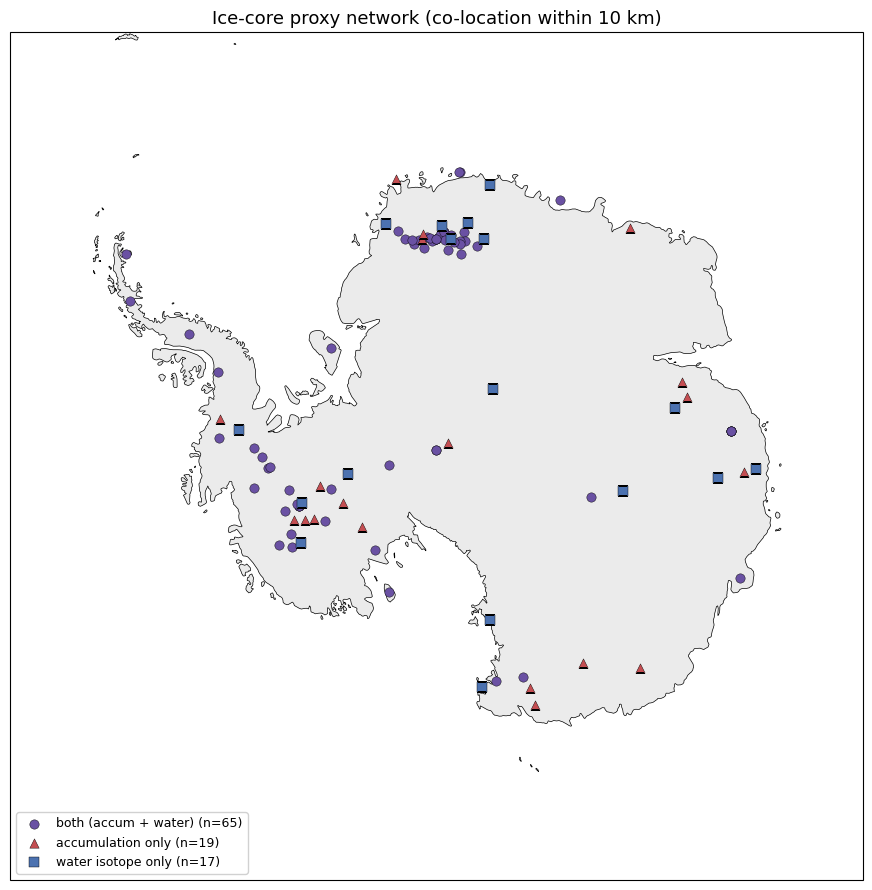

In [14]:
_xyz = lambda lat, lon: np.stack([np.cos(np.deg2rad(lat))*np.cos(np.deg2rad(lon)),
                                  np.cos(np.deg2rad(lat))*np.sin(np.deg2rad(lon)), np.sin(np.deg2rad(lat))], -1)
chord_km = lambda d: 2*np.arcsin(np.clip(d/2, 0, 1))*6371.0
MATCH_KM = 10.0
acc_xyz, wat_xyz = _xyz(core_lats, core_lons), _xyz(water_lats, water_lons)
acc_has_water = chord_km(cKDTree(wat_xyz).query(acc_xyz)[0]) < MATCH_KM
wat_has_acc   = chord_km(cKDTree(acc_xyz).query(wat_xyz)[0]) < MATCH_KM
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0); ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
for lon, lat, c, mk, lbl in [
        (core_lons[acc_has_water], core_lats[acc_has_water], "#6A51A3", "o", "both (accum + water)"),
        (core_lons[~acc_has_water], core_lats[~acc_has_water], "#C44E52", "^", "accumulation only"),
        (water_lons[~wat_has_acc], water_lats[~wat_has_acc], "#4C72B0", "s", "water isotope only")]:
    ax.scatter(lon, lat, s=45, c=c, marker=mk, edgecolor="k", linewidth=0.3,
               transform=ccrs.PlateCarree(), zorder=3, label=f"{lbl} (n={len(lon)})")
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
ax.set_title(f"Ice-core proxy network (co-location within {MATCH_KM:.0f} km)", fontsize=13)
plt.tight_layout(); plt.show()


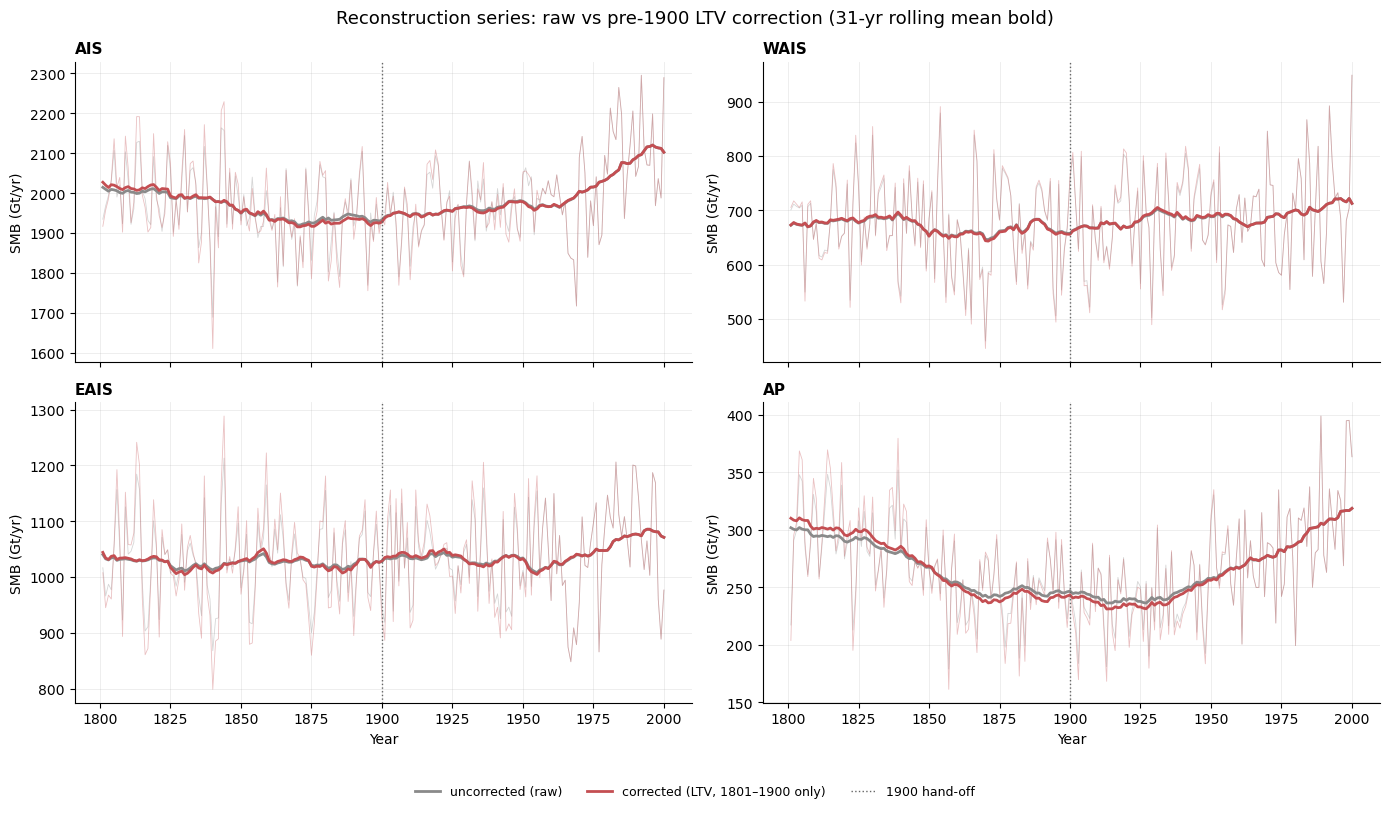

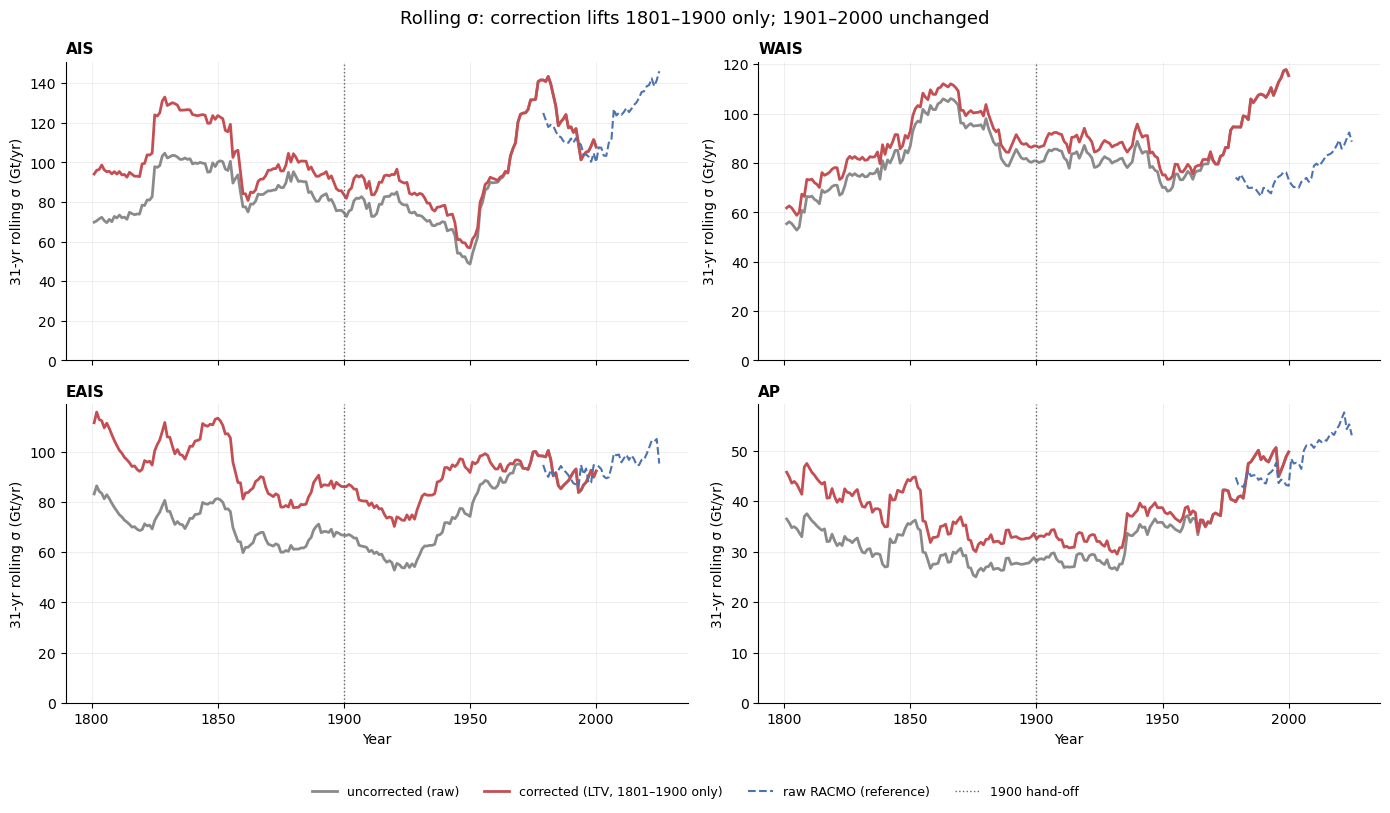

In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

Wr = 31
_rr = lambda x: pd.Series(np.asarray(x, float)).rolling(Wr, center=True, min_periods=max(4, Wr//2))
r_mean = lambda x: _rr(x).mean().values
r_std  = lambda x: _rr(x).std(ddof=1).values
years_r = np.arange(1801, 1801 + smb_reg_mean.shape[0])
C_RAW, C_COR, C_REF = "#8a8a8a", "#C44E52", "#4C72B0"

# --- Figure 1: series (annual faint, 31-yr rolling mean bold) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    ax.plot(years_r, smb_reg_mean_raw[:, k], color=C_RAW, lw=0.6, alpha=0.35)
    ax.plot(years_r, smb_reg_mean[:, k],     color=C_COR, lw=0.6, alpha=0.35)
    ax.plot(years_r, r_mean(smb_reg_mean_raw[:, k]), color=C_RAW, lw=2)
    ax.plot(years_r, r_mean(smb_reg_mean[:, k]),     color=C_COR, lw=2)
    ax.axvline(1900, color="0.4", lw=1.0, ls=":")
    ax.set_title(r, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel("SMB (Gt/yr)"); ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.legend(handles=[Line2D([0],[0], color=C_RAW, lw=2, label="uncorrected (raw)"),
                    Line2D([0],[0], color=C_COR, lw=2, label="corrected (LTV, 1801–1900 only)"),
                    Line2D([0],[0], color="0.4", lw=1.0, ls=":", label="1900 hand-off")],
           loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Reconstruction series: raw vs pre-1900 LTV correction ({Wr}-yr rolling mean bold)", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

# --- Figure 2: rolling standard deviation, with the raw-RACMO reference ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    ax.plot(years_r, r_std(smb_reg_mean_raw[:, k]), color=C_RAW, lw=2)
    ax.plot(years_r, r_std(smb_reg_mean[:, k]),     color=C_COR, lw=2)
    ry = raw_series[r].index.values
    ax.plot(ry, _rr(raw_series[r].values).std(ddof=1).values, color=C_REF, lw=1.5, ls="--")
    ax.axvline(1900, color="0.4", lw=1.0, ls=":")
    ax.set_title(r, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel(f"{Wr}-yr rolling σ (Gt/yr)"); ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.legend(handles=[Line2D([0],[0], color=C_RAW, lw=2, label="uncorrected (raw)"),
                    Line2D([0],[0], color=C_COR, lw=2, label="corrected (LTV, 1801–1900 only)"),
                    Line2D([0],[0], color=C_REF, lw=1.5, ls="--", label="raw RACMO (reference)"),
                    Line2D([0],[0], color="0.4", lw=1.0, ls=":", label="1900 hand-off")],
           loc="lower center", ncol=4, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Rolling σ: correction lifts 1801–1900 only; 1901–2000 unchanged", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()


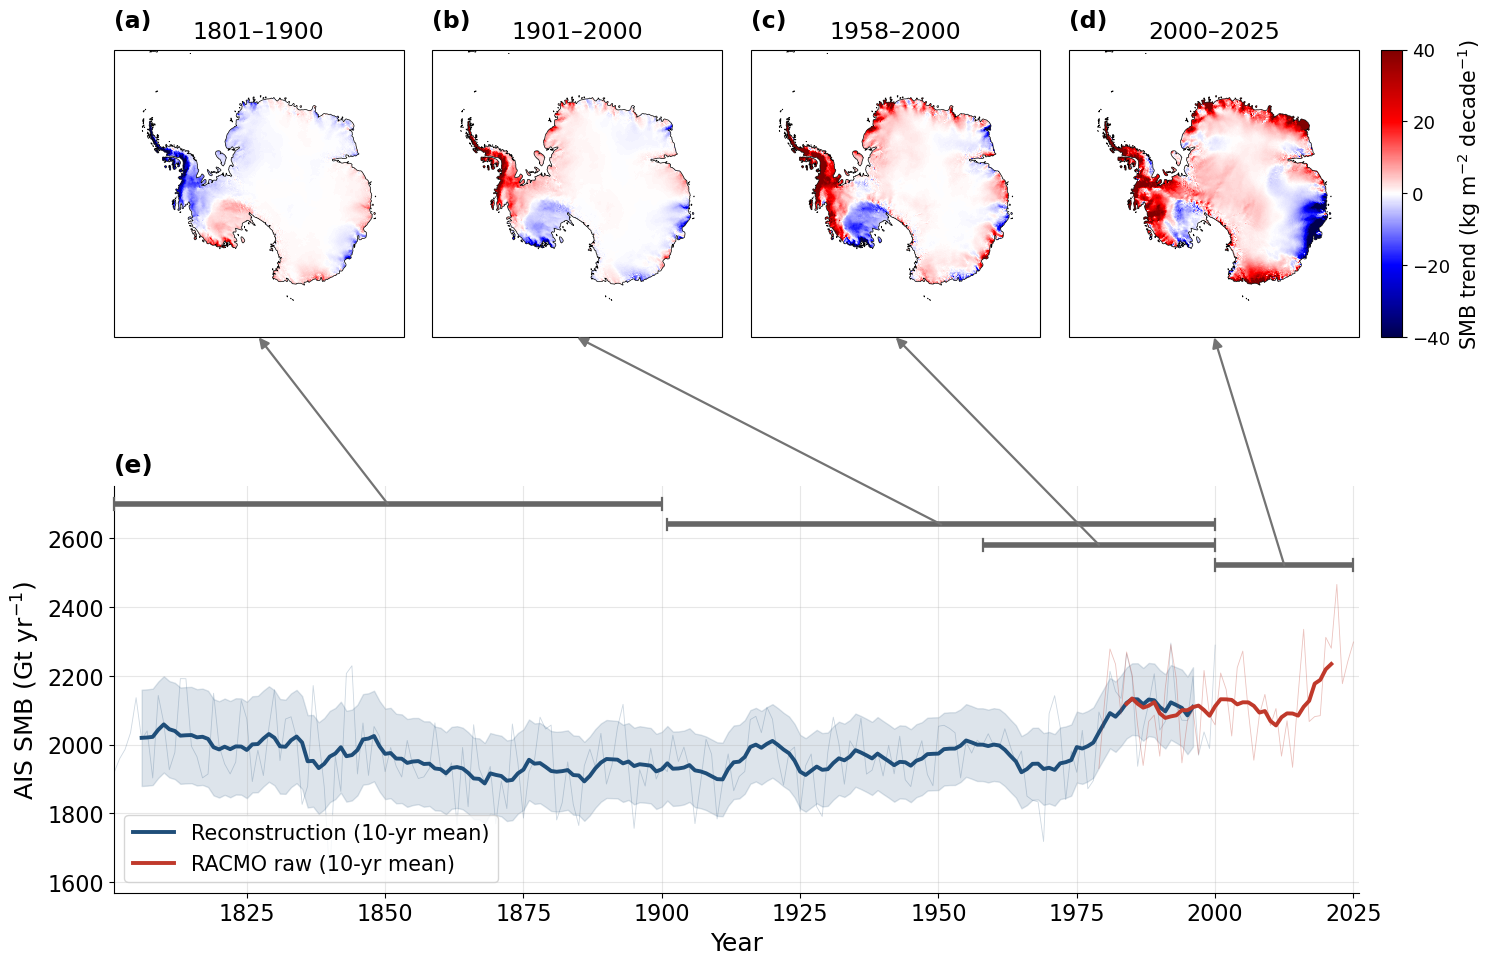

In [49]:
# ===== Stacked figure: AIS SMB time series + spatial-trend maps (true 10-yr mean, vertical cbar, arrows) =====
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs, cartopy.feature as cfeature
from matplotlib.transforms import blended_transform_factory
from matplotlib.patches import ConnectionPatch

def spatial_trend(cube, y0, y1, off):
    sub = cube[y0-off:y1-off+1]
    t = np.arange(sub.shape[0], dtype=float); X = np.vstack([t, np.ones_like(t)]).T
    beta, *_ = np.linalg.lstsq(X, sub.reshape(sub.shape[0], -1), rcond=None)
    return beta[0].reshape(sub.shape[1], sub.shape[2]) * 10
roll = lambda s, w=10: pd.Series(np.asarray(s, float)).rolling(w, center=True, min_periods=w).mean().values  # true 10-yr

# panel (c): reconstruction 1958–1978  +  raw RACMO 1979–2000
cube_c = np.concatenate([racmo_smb_recon[1958-1801:1979-1801],     # 1958–1978 (recon)
                         smb_ann.values[1979-1979:2000-1979+1]],   # 1979–2000 (RACMO)
                        axis=0)

C_REC, C_RAC = "#1f4e79", "#c0392b"; CMAP = "seismic"
periods = [("(a)", "1801–1900", racmo_smb_recon, 1801, 1900, 1801),
           ("(b)", "1901–2000", racmo_smb_recon, 1901, 2000, 1801),
           ("(c)", "1958–2000", cube_c,          1958, 2000, 1958),   # hybrid recon+RACMO
           ("(d)", "2000–2025", smb_ann.values,  2000, 2025, 1979)]

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 4, height_ratios=[1.0, 1.35], hspace=0.40, wspace=0.10,
                       left=0.07, right=0.90, top=0.94, bottom=0.09)
map_axes = []
for j, (letter, yrs, cube, y0, y1, off) in enumerate(periods):
    axm = fig.add_subplot(gs[0, j], projection=ccrs.SouthPolarStereo()); map_axes.append(axm)
    axm.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = axm.pcolormesh(lon_racmo, lat_racmo, spatial_trend(cube, y0, y1, off),
                        transform=ccrs.PlateCarree(), vmin=-40, vmax=40, cmap=CMAP, zorder=1)
    axm.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    axm.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
    axm.set_title(yrs, fontsize=17, pad=8, color="black")
    axm.text(0.0, 1.06, letter, transform=axm.transAxes, ha="left", va="bottom",
             fontsize=17, fontweight="bold", color="black")

p0 = map_axes[0].get_position(); p3 = map_axes[3].get_position()
cax = fig.add_axes([p3.x1 + 0.015, p3.y0, 0.014, p3.height])
cb = fig.colorbar(im, cax=cax, orientation="vertical")
cb.set_label("SMB trend (kg m$^{-2}$ decade$^{-1}$)", fontsize=15); cb.ax.tick_params(labelsize=13)

axt = fig.add_subplot(gs[1, :])
std = 2*smb_reg_std[:, 0]
axt.plot(recon_years, recon_series["AIS"], color=C_REC, lw=0.6, alpha=0.22)
axt.fill_between(recon_years, roll(recon_series["AIS"]-std), roll(recon_series["AIS"]+std), color=C_REC, alpha=0.15)
axt.plot(recon_years, roll(recon_series["AIS"]), color=C_REC, lw=2.8, label="Reconstruction (10-yr mean)")
axt.plot(raw_series["AIS"].index, raw_series["AIS"].values, color=C_RAC, lw=0.6, alpha=0.30)
axt.plot(raw_series["AIS"].index, roll(raw_series["AIS"].values), color=C_RAC, lw=2.8, label="RACMO raw (10-yr mean)")
axt.set_xlim(1801, 2026); axt.set_xlabel("Year", fontsize=18)
axt.set_ylabel("AIS SMB (Gt yr$^{-1}$)", fontsize=18)
axt.tick_params(labelsize=16); axt.grid(alpha=0.3); axt.legend(fontsize=15, loc="lower left")
for sp in ("top", "right"): axt.spines[sp].set_visible(False)
axt.text(0.0, 1.02, "(e)", transform=axt.transAxes, fontsize=18, fontweight="bold", va="bottom")

# --- neutral period bars + arrows linking each span to its map ---
_lo, _hi = axt.get_ylim(); axt.set_ylim(_lo, _hi + 0.26*(_hi-_lo))
trans = blended_transform_factory(axt.transData, axt.transAxes)
for (letter, _yrs, _cube, y0, y1, _off), axm, yl in zip(periods, map_axes, [0.955, 0.905, 0.855, 0.805]):
    axt.plot([y0, y1], [yl, yl], color="0.4", lw=4, solid_capstyle="butt", transform=trans, clip_on=False, zorder=6)
    for xx in (y0, y1):
        axt.plot([xx, xx], [yl-0.014, yl+0.014], color="0.4", lw=1.6, transform=trans, clip_on=False, zorder=6)
    con = ConnectionPatch(xyA=(0.5*(y0+y1), yl), coordsA=trans, xyB=(0.5, 0.0), coordsB=axm.transAxes,
                          arrowstyle="-|>", color="0.45", lw=1.6, mutation_scale=15, zorder=10)
    fig.add_artist(con)
plt.show()


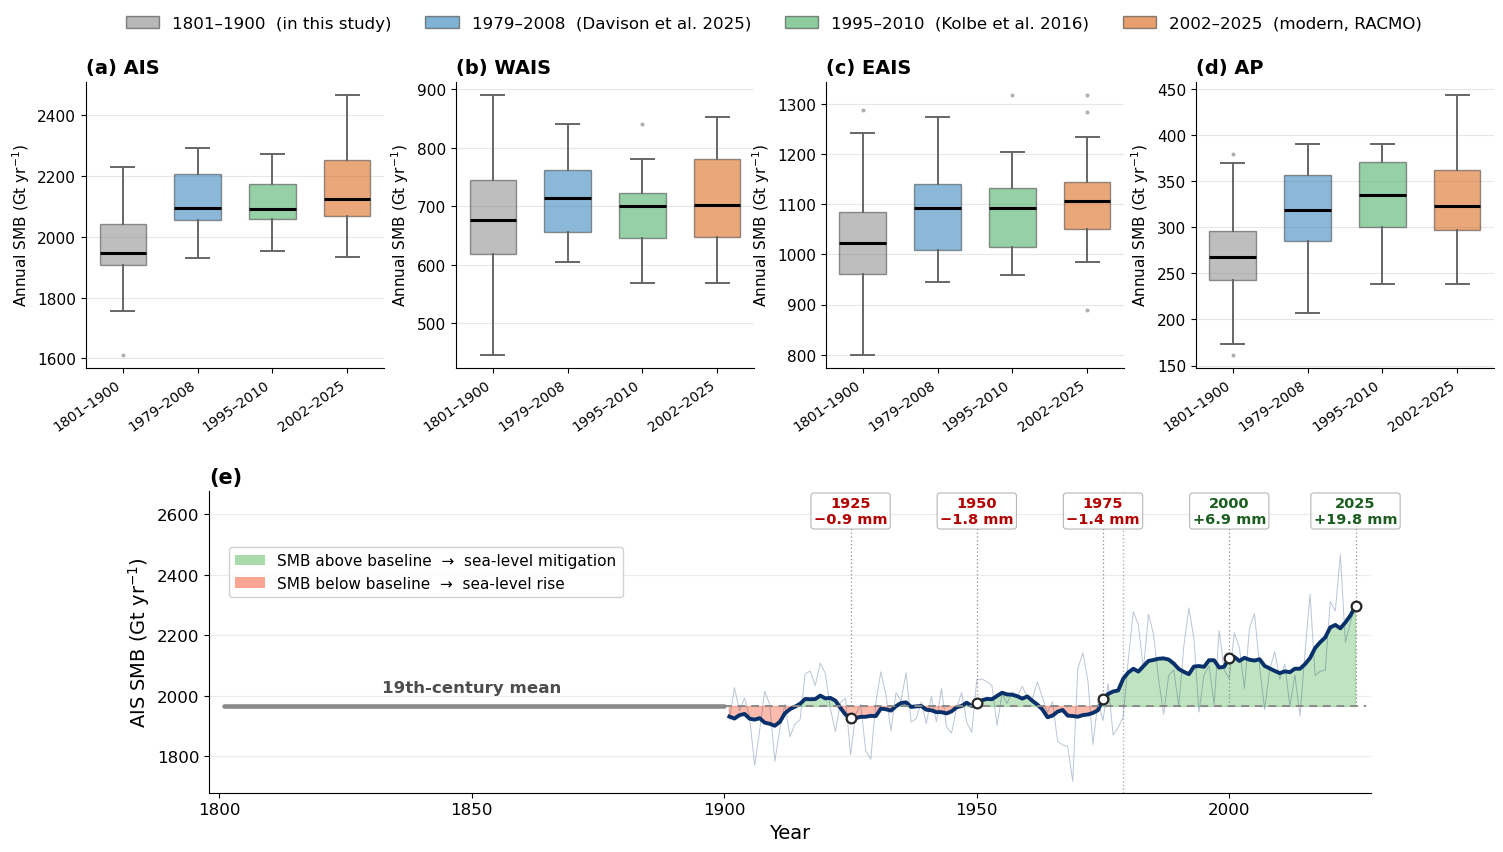

In [79]:
# ===== Regional boxplots (with study key) + AIS SMB 1901–2025 with 25-yr mitigation checkpoints =====
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
GT = 361.8

def region_vals(r, y0, y1, src):
    s = pd.Series(recon_series[r], index=recon_years) if src == "recon" else raw_series[r]
    return s.loc[y0:y1].values

periods4 = [("1801–1900", 1801, 1900, "recon"), ("1979–2008", 1979, 2008, "raw"),
            ("1995–2010", 1995, 2010, "raw"), ("2002–2025", 2002, 2025, "raw")]
PLAB4 = [p[0] for p in periods4]
PCOL4 = ["#8a8a8a", "#2C7FB8", "#41ab5d", "#D95F0E"]
STUDY = ["1801–1900  (in this study)", "1979–2008  (Davison et al. 2025)",
         "1995–2010  (Kolbe et al. 2016)", "2002–2025  (modern, RACMO)"]

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 12, height_ratios=[0.95, 1.0], hspace=0.42, wspace=1.4,
                       left=0.07, right=0.95, top=0.88, bottom=0.09)
fig.legend(handles=[Patch(facecolor=PCOL4[i], alpha=0.6, edgecolor="0.25", label=STUDY[i]) for i in range(4)],
           loc="upper center", ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.97))

# --- row 0: regional boxplots (a)-(d) ---
for j, r in enumerate(region_names):
    axb = fig.add_subplot(gs[0, 3*j:3*j+3])
    data = [region_vals(r, y0, y1, src) for (_, y0, y1, src) in periods4]
    bp = axb.boxplot(data, positions=range(4), widths=0.62, patch_artist=True, manage_ticks=False,
                     medianprops=dict(color="black", lw=2.2), whiskerprops=dict(color="0.4", lw=1.4),
                     capprops=dict(color="0.4", lw=1.4), flierprops=dict(marker=".", ms=4, mfc="0.4", mec="0.4", alpha=0.4))
    for patch, c in zip(bp["boxes"], PCOL4):
        patch.set_facecolor(c); patch.set_alpha(0.55); patch.set_edgecolor("0.25")
    axb.set_xticks(range(4)); axb.set_xticklabels(PLAB4, rotation=35, ha="right", fontsize=10)
    axb.set_title(f"({chr(97+j)}) {r}", fontsize=14, fontweight="bold", loc="left")
    axb.set_ylabel("Annual SMB (Gt yr$^{-1}$)", fontsize=11)
    axb.tick_params(axis="y", labelsize=11); axb.grid(axis="y", alpha=0.3); axb.set_axisbelow(True)
    for sp in ("top", "right"): axb.spines[sp].set_visible(False)

# --- row 1 (e): AIS SMB 1901–2025, area = mitigation, with 25-yr checkpoints ---
axz = fig.add_subplot(gs[1, 1:11])
ais = pd.Series(recon_series["AIS"], index=recon_years); base = ais.loc[1801:1900].mean()
ts = pd.concat([ais.loc[1901:1978], raw_series["AIS"].loc[1979:2025]])
roll = lambda s: pd.Series(np.asarray(s, float)).rolling(11, center=True, min_periods=6).mean().values
rollv = roll(ts.values); C_TS, C_POS, C_NEG = "#08306b", "#74c476", "#fb6a4a"

axz.fill_between(ts.index, base, rollv, where=(rollv >= base), color=C_POS, alpha=0.45, interpolate=True, zorder=1)
axz.fill_between(ts.index, base, rollv, where=(rollv <  base), color=C_NEG, alpha=0.45, interpolate=True, zorder=1)
axz.plot([1801, 1900], [base, base], color=PCOL4[0], lw=3.3, solid_capstyle="round", zorder=4)
axz.plot([1900, 2027], [base, base], color=PCOL4[0], lw=1.4, ls=(0, (4, 3)), zorder=4)
axz.annotate("19th-century mean", (1850, base), textcoords="offset points", xytext=(0, 8),
             ha="center", va="bottom", fontsize=12, fontweight="bold", color="0.3")
axz.plot(ts.index, ts.values, color=C_TS, lw=0.7, alpha=0.28, zorder=2)
axz.plot(ts.index, rollv, color=C_TS, lw=2.8, zorder=3)
axz.axvline(1979, color="0.7", lw=1.0, ls=":", zorder=1)

allv = np.concatenate([ts.values, [base]]); span = np.ptp(allv)
lo_y, hi_y = allv.min() - 0.05*span, allv.max() + 0.28*span
axz.set_xlim(1798, 2028); axz.set_ylim(lo_y, hi_y)
y_lab = hi_y - 0.02*span
for cy in [1925, 1950, 1975, 2000, 2025]:
    cum = (ts.loc[1901:cy] - base).sum() / GT
    yc = np.interp(cy, ts.index, rollv)
    axz.plot([cy, cy], [base, y_lab - 0.10*span], color="0.55", lw=0.9, ls=(0, (1, 2)), zorder=3)
    axz.plot(cy, yc, "o", ms=7, mfc="white", mec="0.15", mew=1.6, zorder=5)
    axz.annotate(f"{cy}\n{'+' if cum >= 0 else '−'}{abs(cum):.1f} mm", (cy, y_lab), ha="center", va="top",
                 fontsize=10.5, fontweight="bold", color=("#1b5e20" if cum >= 0 else "#b30000"),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", lw=0.8, alpha=0.95))
axz.set_xlabel("Year", fontsize=14); axz.set_ylabel("AIS SMB (Gt yr$^{-1}$)", fontsize=14)
axz.tick_params(labelsize=12); axz.grid(axis="y", alpha=0.25); axz.set_axisbelow(True)
for sp in ("top", "right"): axz.spines[sp].set_visible(False)
axz.legend(handles=[Patch(facecolor=C_POS, alpha=0.6, label="SMB above baseline  →  sea-level mitigation"),
                    Patch(facecolor=C_NEG, alpha=0.6, label="SMB below baseline  →  sea-level rise")],
           fontsize=11, loc="upper left", bbox_to_anchor=(0.01, 0.84), framealpha=0.9)
axz.set_title("(e)", fontsize=15, fontweight="bold", loc="left")
plt.show()


In [18]:
ib = slice(0, 100)   # 1801–1900 (recon index)
print("Reconstructed 1801–1900 mean SMB")
print(f"{'region':<6}{'mean (Gt/yr)':>14}{'±1σ':>8}{'±2σ':>8}{'interann. σ':>13}")
for k, r in enumerate(region_names):
    ens = smb_reg_ens[ib, :, k]                 # (100 years, members)
    memmean = ens.mean(0)                        # each member's 1801–1900 mean
    mu, sig = memmean.mean(), memmean.std(ddof=1)     # baseline mean & its 1σ uncertainty
    iav = smb_reg_ens[ib, :, k].mean(1).std(ddof=1)   # year-to-year spread of the ensemble-mean
    print(f"{r:<6}{mu:>14.1f}{sig:>8.1f}{2*sig:>8.1f}{iav:>13.1f}")
mu0 = smb_reg_ens[ib, :, 0].mean(0).mean()
sig0 = smb_reg_ens[ib, :, 0].mean(0).std(ddof=1)
print(f"\nAntarctic Ice Sheet, 1801–1900 SMB = {mu0:.0f} ± {2*sig0:.0f} Gt/yr (2σ)"
      f"   ≈ {mu0/361.8:.2f} ± {2*sig0/361.8:.2f} mm SLE/yr")

print("\nRACMO 2000–2025 mean SMB")
print(f"{'region':<6}{'mean (Gt/yr)':>14}{'interann. σ':>13}{'SE of mean':>12}")
for r in region_names:
    v = raw_series[r].loc[2000:2025].values
    mu, sd = v.mean(), v.std(ddof=1); se = sd/np.sqrt(len(v))
    print(f"{r:<6}{mu:>14.1f}{sd:>13.1f}{se:>12.1f}")
mu0 = raw_series["AIS"].loc[2000:2025].mean()
sd0 = raw_series["AIS"].loc[2000:2025].std(ddof=1)
print(f"\nAntarctic Ice Sheet, 2000–2025 RACMO SMB = {mu0:.0f} Gt/yr "
      f"(interannual σ {sd0:.0f})   ≈ {mu0/361.8:.2f} mm SLE/yr")



Reconstructed 1801–1900 mean SMB
region  mean (Gt/yr)     ±1σ     ±2σ  interann. σ
AIS           1965.1    63.2   126.3        109.8
WAIS           670.5    21.7    43.4         89.1
EAIS          1024.7    57.5   115.0         93.3
AP             269.9    18.4    36.8         45.1

Antarctic Ice Sheet, 1801–1900 SMB = 1965 ± 126 Gt/yr (2σ)   ≈ 5.43 ± 0.35 mm SLE/yr

RACMO 2000–2025 mean SMB
region  mean (Gt/yr)  interann. σ  SE of mean
AIS           2147.9        129.0        25.3
WAIS           707.5         83.1        16.3
EAIS          1107.6         97.1        19.0
AP             332.8         52.0        10.2

Antarctic Ice Sheet, 2000–2025 RACMO SMB = 2148 Gt/yr (interannual σ 129)   ≈ 5.94 mm SLE/yr


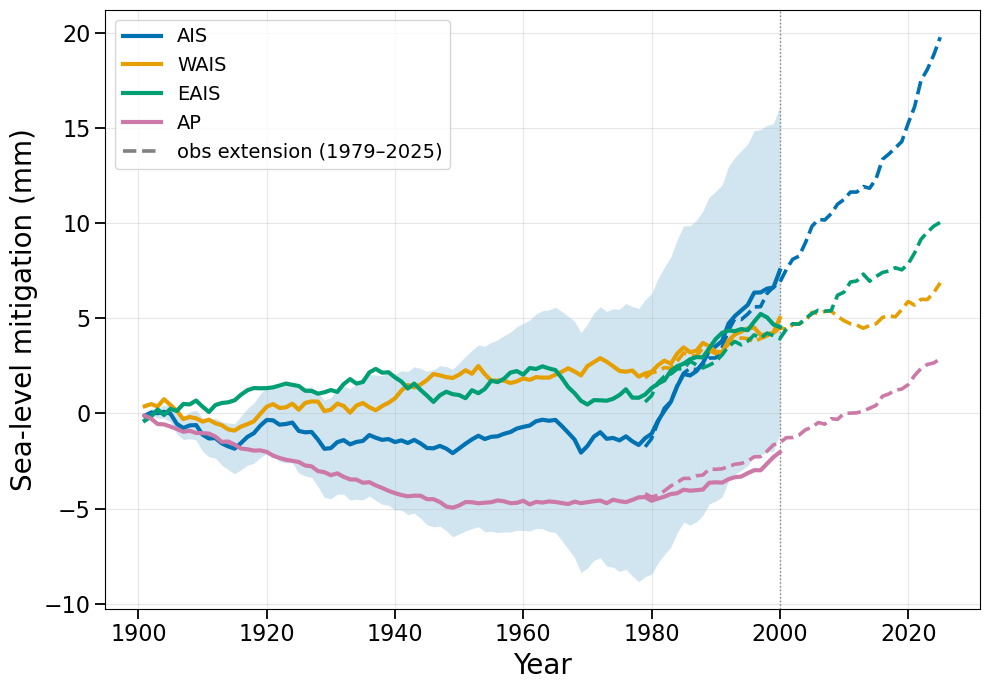

In [19]:
from matplotlib.lines import Line2D
CB = {"AIS": "#0072B2", "WAIS": "#E69F00", "EAIS": "#009E73", "AP": "#CC79A7"}
region_idx = {"AIS":0, "WAIS":1, "EAIS":2, "AP":3}
def sea_level_mitigation(ts, baseline=slice(0, 100)):
    ts = np.asarray(ts, float); return np.cumsum(ts - ts[baseline].mean()) / 361.8
def extend_slm(recon_ts, obs_ts, baseline=slice(0, 100)):
    r = np.asarray(recon_ts, float); base = r[baseline].mean(); cum = np.sum(r[:178] - base) / 361.8
    return cum + np.cumsum((np.asarray(obs_ts) - base) / 361.8)
def slm_sigma(k):
    ens = smb_reg_ens[:, :, k]
    return np.stack([sea_level_mitigation(ens[:, m]) for m in range(ens.shape[1])]).std(0, ddof=1)

cent_years = np.arange(1901, 2001)
fig, ax = plt.subplots(figsize=(10, 7))
slm_ais = sea_level_mitigation(recon_series["AIS"]); sig_ais = slm_sigma(0)
ax.fill_between(cent_years, (slm_ais - 2*sig_ais)[100:], (slm_ais + 2*sig_ais)[100:],
                color=CB["AIS"], alpha=0.18, lw=0, zorder=1)
for r in region_names:
    col = CB[r]
    ax.plot(cent_years, sea_level_mitigation(recon_series[r])[100:], color=col, lw=3.0, zorder=3)
    ax.plot(years_obs, extend_slm(recon_series[r], raw_series[r]), color=col, lw=2.6, ls="--", zorder=3)
ax.axvline(2000, color="gray", lw=1.0, ls=":", zorder=2)
ax.set_xlabel("Year", fontsize=20)
ax.set_ylabel("Sea-level mitigation (mm)", fontsize=20)
ax.tick_params(axis="both", which="major", labelsize=16, length=7, width=1.3)
ax.grid(alpha=0.3)
handles = [Line2D([0],[0], color=CB[r], lw=3.0, label=r) for r in region_names]
handles += [Line2D([0],[0], color="gray", lw=2.6, ls="--", label="obs extension (1979–2025)")]
ax.legend(handles=handles, fontsize=14)
plt.tight_layout(); plt.show()


In [20]:
GT = 361.8
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
def combined(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:2025]])
def baseline_error(r):
    k = region_idx[r]; ib = [y-1801 for y in range(1801, 1901)]
    return smb_reg_ens[ib, :, k].mean(0).std(ddof=1)
def mitig(r, y0, y1):
    c = combined(r); base = c.loc[1801:1900].mean()
    return (c.loc[y0:y1] - base).sum() / GT                      # cumulative mitigation over window (mm)
def mitig_2sig(r, y0, y1):
    return 2 * baseline_error(r) * (y1 - y0 + 1) / GT            # 2σ from baseline-mean uncertainty

for (y0, y1) in [(1901, 2025), (1980, 2025), (1901, 2000)]:
    print(f"\nCumulative sea-level mitigation {y0}–{y1}  (mm SLE, positive = sea level lowered)")
    for r in region_names:
        print(f"  {r:<5}: {mitig(r,y0,y1):+7.2f} ± {mitig_2sig(r,y0,y1):.2f} (2σ)")



Cumulative sea-level mitigation 1901–2025  (mm SLE, positive = sea level lowered)
  AIS  :  +19.77 ± 43.64 (2σ)
  WAIS :   +6.86 ± 14.99 (2σ)
  EAIS :  +10.04 ± 39.72 (2σ)
  AP   :   +2.87 ± 12.71 (2σ)

Cumulative sea-level mitigation 1980–2025  (mm SLE, positive = sea level lowered)
  AIS  :  +21.53 ± 16.06 (2σ)
  WAIS :   +5.00 ± 5.52 (2σ)
  EAIS :   +9.44 ± 14.62 (2σ)
  AP   :   +7.09 ± 4.68 (2σ)

Cumulative sea-level mitigation 1901–2000  (mm SLE, positive = sea level lowered)
  AIS  :   +6.89 ± 34.91 (2σ)
  WAIS :   +4.51 ± 11.99 (2σ)
  EAIS :   +3.92 ± 31.77 (2σ)
  AP   :   -1.54 ± 10.17 (2σ)


reg   kappa    ToE
AIS    0.00   2004
WAIS   0.00   None
EAIS   0.00   2021
AP     0.63   None


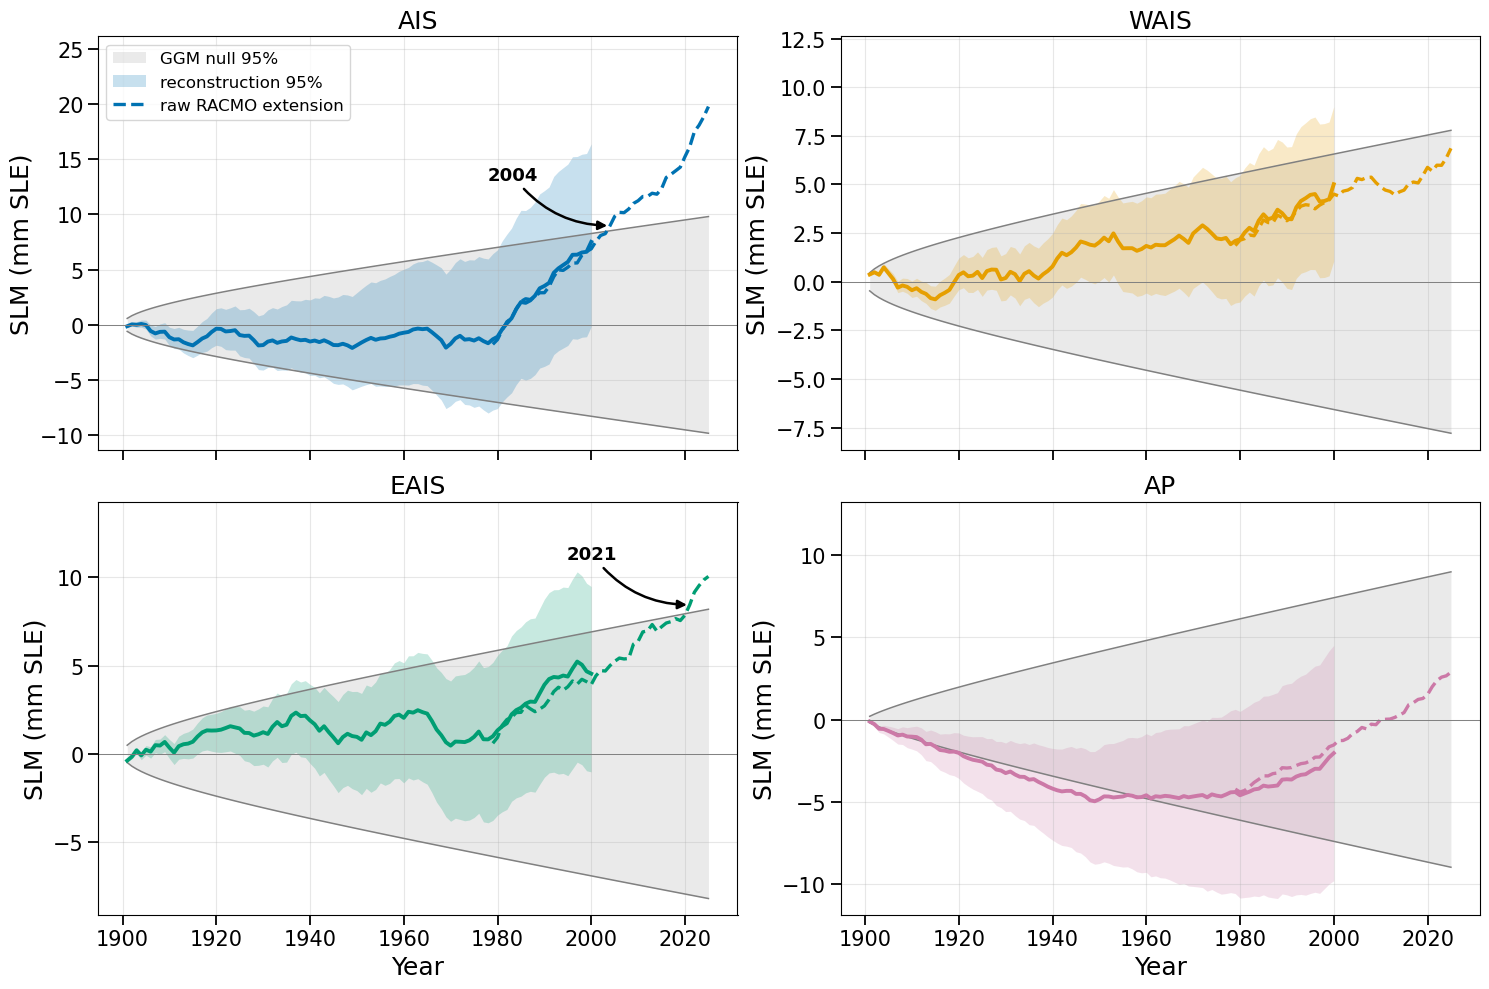

In [21]:
from scipy.stats import norm
CB = {"AIS": "#0072B2", "WAIS": "#E69F00", "EAIS": "#009E73", "AP": "#CC79A7"}
GT, NB, NA = 361.8, 100, 125
def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB+NA) * fit["sigma_w"]**2)
    return np.array([np.sqrt((a := np.concatenate([np.full(NB,-n/NB),np.ones(n)])) @ R[:NB+n,:NB+n] @ a)/GT
                     for n in range(1, NA+1)])
def emergence(traj, sig, yy):
    out = traj > 1.96*sig
    for i in range(len(yy)):
        if out[i:].all(): return int(yy[i])
    return None
years, cent, yr_obs = np.arange(1901, 2026), np.arange(1901, 2001), np.arange(1979, 2026)
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
print(f"{'reg':4s}{'kappa':>7s}{'ToE':>7s}")
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    col = CB[r]
    recon_ts = np.asarray(recon_series[r]); slm_recon = sea_level_mitigation(recon_ts)
    ens = smb_reg_ens[:, :, k]
    slm_mem = np.stack([sea_level_mitigation(ens[:, m]) for m in range(ens.shape[1])])
    lo, hi = np.percentile(slm_mem, [2.5, 97.5], axis=0)
    slm_ext = extend_slm(recon_ts, raw_series[r].loc[1979:2025].values)
    sig = slm_sigma(ggm_fits[r])
    traj = np.concatenate([slm_recon[100:178], slm_ext])
    toe = emergence(traj, sig, years)
    ax.fill_between(years, -1.96*sig, 1.96*sig, color="0.6", alpha=0.20, lw=0, label="GGM null 95%")
    ax.plot(years, 1.96*sig, color="0.5", lw=1.1); ax.plot(years, -1.96*sig, color="0.5", lw=1.1)
    ax.fill_between(cent, lo[100:200], hi[100:200], color=col, alpha=0.22, lw=0, label="reconstruction 95%")
    ax.plot(cent, slm_recon[100:200], color=col, lw=2.8)
    ax.plot(yr_obs, slm_ext, color=col, lw=2.4, ls="--", label="raw RACMO extension")
    if toe:
        yv = traj[toe - 1901]
        ax.annotate(f"{toe}", xy=(toe, yv), xycoords="data",
                    xytext=(-52, 30), textcoords="offset points",
                    ha="right", va="bottom", fontsize=13, fontweight="bold", color="black",
                    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.8,
                                    connectionstyle="arc3,rad=0.25"))
    ax.axhline(0, color="gray", lw=0.7)
    ax.set_title(r, fontsize=18)
    ax.set_ylabel("SLM (mm SLE)", fontsize=18)
    ax.tick_params(axis="both", which="major", labelsize=15, length=7, width=1.3)
    ax.grid(alpha=0.3)
    if k == 0: ax.legend(fontsize=12)
    lo_, hi_ = ax.get_ylim(); ax.set_ylim(lo_, hi_ + 0.15*(hi_ - lo_))       # headroom for the label
    print(f"{r:4s}{ggm_fits[r]['kappa']:7.2f}{str(toe):>7s}")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=18)
fig.tight_layout(); plt.show()


reg   kappa    ToE
AIS    0.00   2004
WAIS   0.00   None
EAIS   0.00   2021
AP     0.63   None


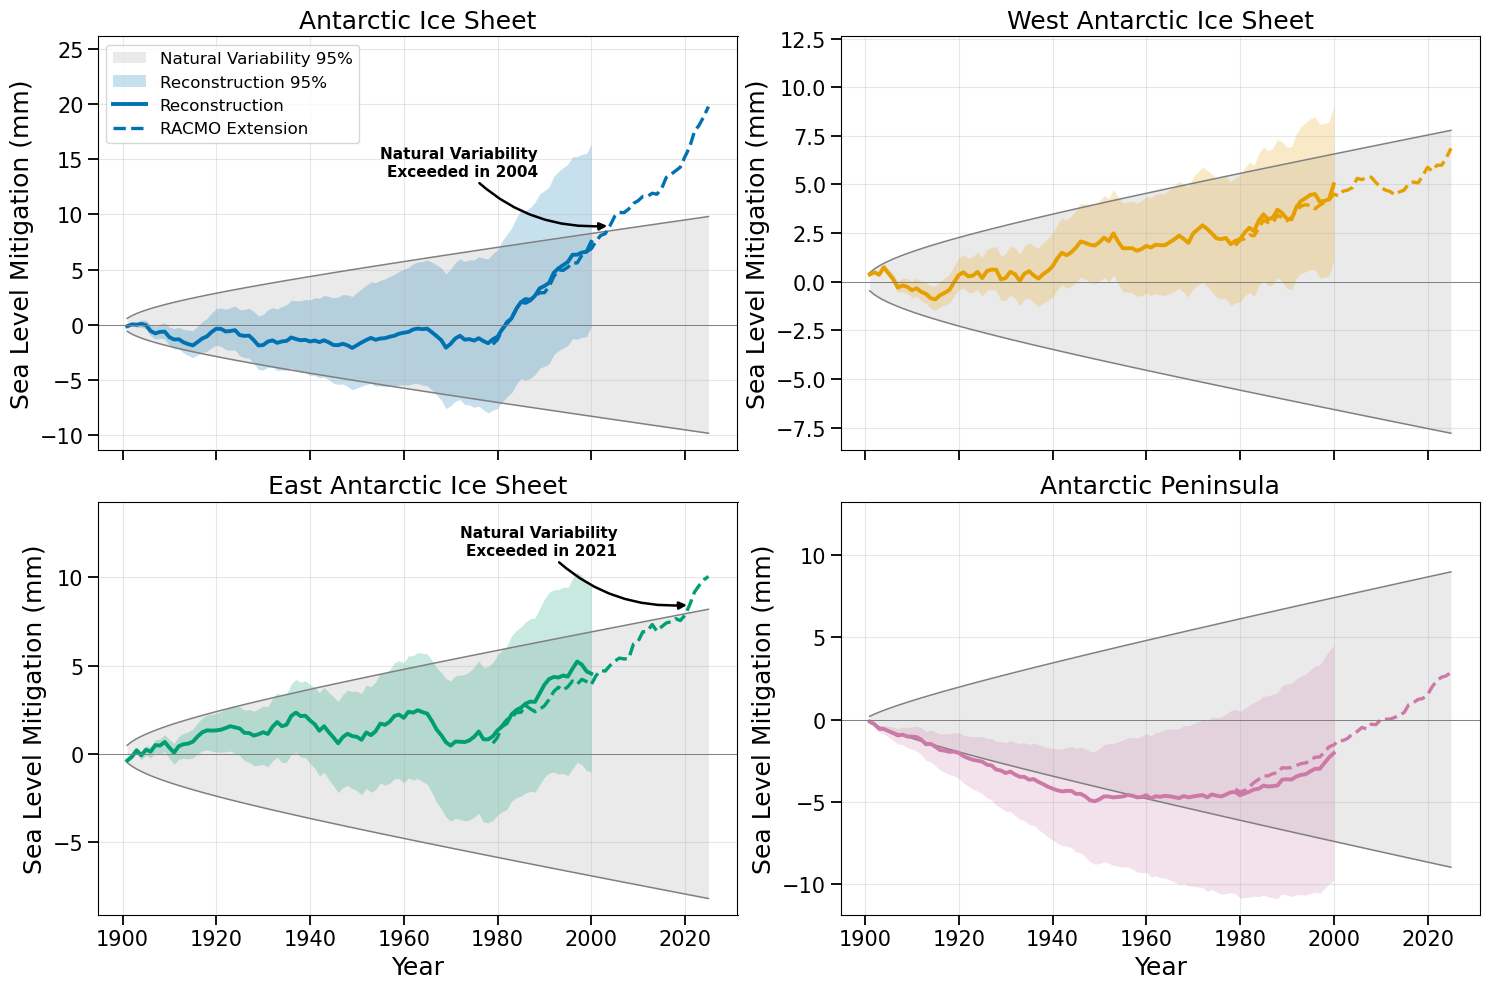

In [22]:
from scipy.stats import norm
CB = {"AIS": "#0072B2", "WAIS": "#E69F00", "EAIS": "#009E73", "AP": "#CC79A7"}
FULLNAME = {"AIS": "Antarctic Ice Sheet", "WAIS": "West Antarctic Ice Sheet",
            "EAIS": "East Antarctic Ice Sheet", "AP": "Antarctic Peninsula"}
GT, NB, NA = 361.8, 100, 125
def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB+NA) * fit["sigma_w"]**2)
    return np.array([np.sqrt((a := np.concatenate([np.full(NB,-n/NB),np.ones(n)])) @ R[:NB+n,:NB+n] @ a)/GT
                     for n in range(1, NA+1)])
def emergence(traj, sig, yy):
    out = traj > 1.96*sig
    for i in range(len(yy)):
        if out[i:].all(): return int(yy[i])
    return None
years, cent, yr_obs = np.arange(1901, 2026), np.arange(1901, 2001), np.arange(1979, 2026)
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
print(f"{'reg':4s}{'kappa':>7s}{'ToE':>7s}")
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    col = CB[r]
    recon_ts = np.asarray(recon_series[r]); slm_recon = sea_level_mitigation(recon_ts)
    ens = smb_reg_ens[:, :, k]
    slm_mem = np.stack([sea_level_mitigation(ens[:, m]) for m in range(ens.shape[1])])
    lo, hi = np.percentile(slm_mem, [2.5, 97.5], axis=0)
    slm_ext = extend_slm(recon_ts, raw_series[r].loc[1979:2025].values)
    sig = slm_sigma(ggm_fits[r])
    traj = np.concatenate([slm_recon[100:178], slm_ext])
    toe = emergence(traj, sig, years)
    ax.fill_between(years, -1.96*sig, 1.96*sig, color="0.6", alpha=0.20, lw=0, label="Natural Variability 95%")
    ax.plot(years, 1.96*sig, color="0.5", lw=1.1); ax.plot(years, -1.96*sig, color="0.5", lw=1.1)
    ax.fill_between(cent, lo[100:200], hi[100:200], color=col, alpha=0.22, lw=0, label="Reconstruction 95%")
    ax.plot(cent, slm_recon[100:200], color=col, lw=2.8, label="Reconstruction")
    ax.plot(yr_obs, slm_ext, color=col, lw=2.4, ls="--", label="RACMO Extension")
    if toe:
        yv = traj[toe - 1901]
        ax.annotate(f"Natural Variability\nExceeded in {toe}", xy=(toe, yv), xycoords="data",
                    xytext=(-52, 34), textcoords="offset points",
                    ha="right", va="bottom", fontsize=11, fontweight="bold", color="black",
                    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.8,
                                    connectionstyle="arc3,rad=0.25"))
    ax.axhline(0, color="gray", lw=0.7)
    ax.set_title(FULLNAME[r], fontsize=18)
    ax.set_ylabel("Sea Level Mitigation (mm)", fontsize=18)
    ax.tick_params(axis="both", which="major", labelsize=15, length=7, width=1.3)
    ax.grid(alpha=0.3)
    if k == 0: ax.legend(fontsize=12)
    lo_, hi_ = ax.get_ylim(); ax.set_ylim(lo_, hi_ + 0.15*(hi_ - lo_))       # headroom for the label
    print(f"{r:4s}{ggm_fits[r]['kappa']:7.2f}{str(toe):>7s}")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=18)
fig.tight_layout(); plt.show()


In [23]:
# ===== Load GRACE (JPL mascon RL06) → grace_annual + grace_masks =====
import os
grace = xr.open_dataset(os.path.expanduser("~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5)*(np.sin(np.deg2rad(glat+0.25))-np.sin(np.deg2rad(glat-0.25))))[:, None]*np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat)
gidf = basin_mask[grounded_mask]                                       # basin id at each grounded cell
d, ii_g = cKDTree(to_xyz(lat_racmo[grounded_mask], lon_racmo[grounded_mask])).query(
    to_xyz(glat2d.ravel(), glon2d.ravel()))
near_basin = np.where(d*6371.0 < 150, gidf[ii_g], 0).reshape(glat2d.shape)   # nearest basin within 150 km
grace_masks = {"AIS": near_basin > 0, "WAIS": np.isin(near_basin, [3,7,8,9,10]),
               "EAIS": np.isin(near_basin, [1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(near_basin, [4,5,6])}
gyear = pd.DatetimeIndex(grace["time"].values).year
def grace_annual(mask):
    m = np.array([np.nansum(np.where(mask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    return pd.Series(m, index=gyear).groupby(level=0).mean()            # Gt, annual mean of 3-monthly solutions
print("GRACE ready:", ewh.shape, "| cells/basin:", {r: int(grace_masks[r].sum()) for r in region_names})


GRACE ready: (256, 60, 720) | cells/basin: {'AIS': 29215, 'WAIS': 6456, 'EAIS': 21845, 'AP': 914}


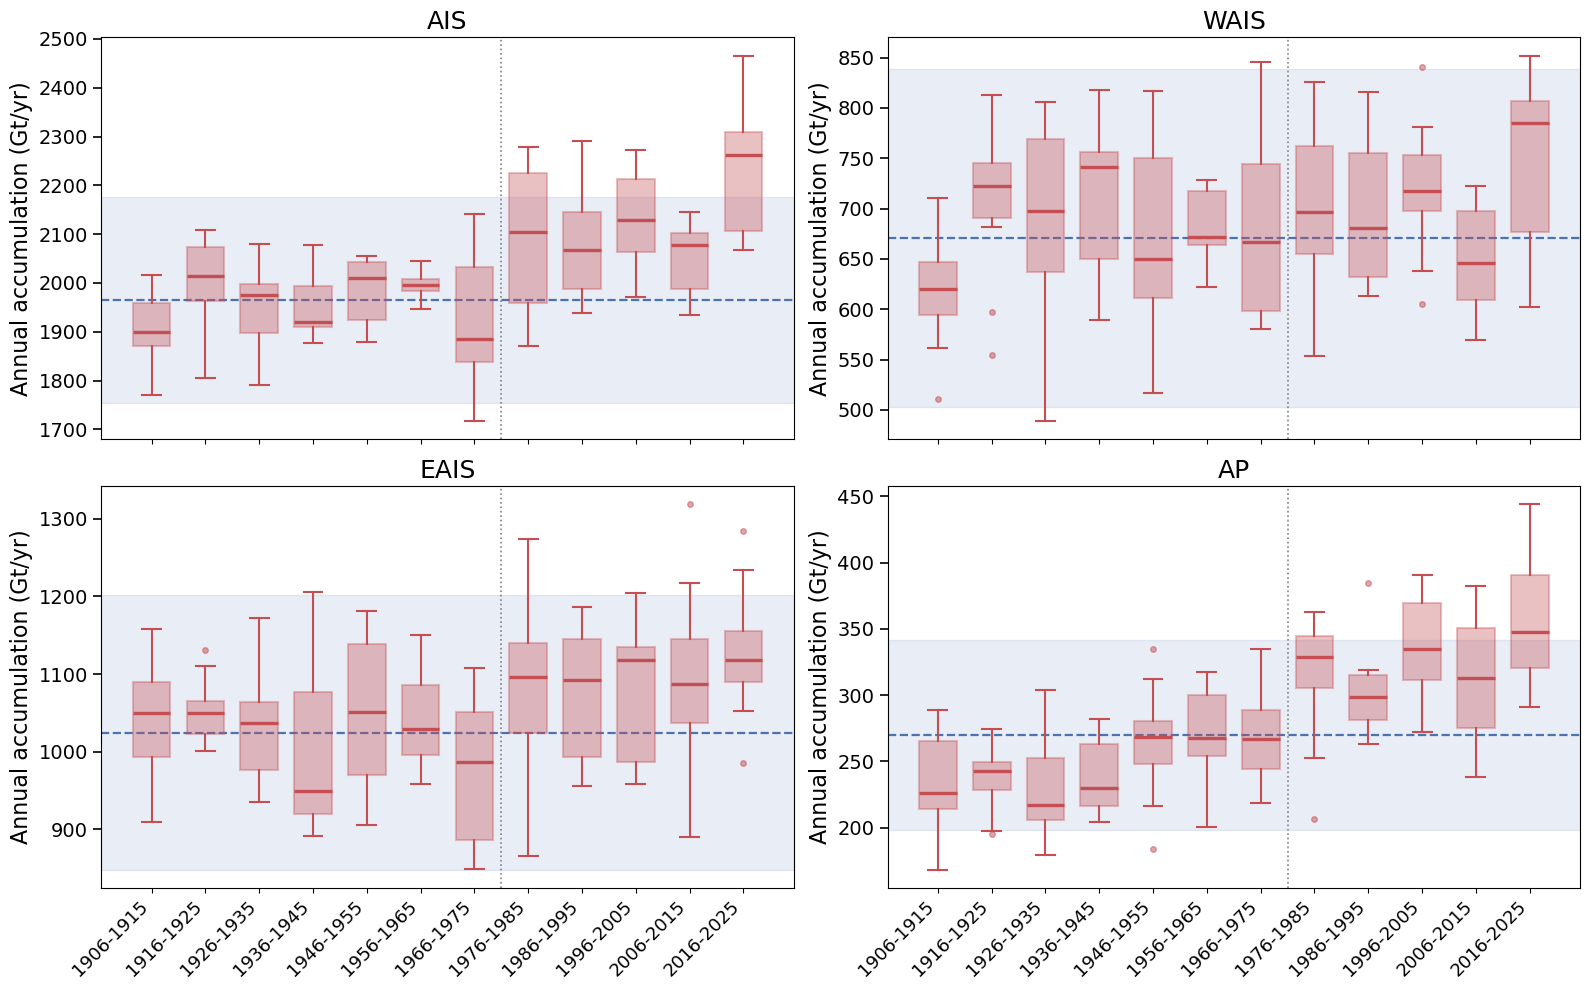

In [25]:
rng = np.random.default_rng(0); NULL_C, OBS_C = "#4C72B0", "#C44E52"
def combined(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]])
starts = list(range(1906, 2017, 10)); decades = [(s, s+9) for s in starts]; labels = [f"{s}-{s+9}" for s in starts]
split_x = next(i for i, (a, b) in enumerate(decades) if b >= 1979) - 0.5
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
for ax, r in zip(axes.ravel(), region_names):
    comb = combined(r); base = comb.loc[1801:1900].mean(); fit = ggm_fits[r]
    sd = np.sqrt(_ggm_acf(fit["kappa"], fit["phi"], 1)[0] * fit["sigma_w"]**2)
    ax.axhspan(base-1.96*sd, base+1.96*sd, color=NULL_C, alpha=0.12, label="GGM natural variability (5–95%)")
    ax.axhline(base, color=NULL_C, ls="--", lw=1.6, label="preindustrial mean")
    ax.axvline(split_x, color="0.5", ls=":", lw=1.2)
    data = [comb.loc[a:b].values for (a, b) in decades]; xpos = np.arange(len(decades))
    ax.boxplot(data, positions=xpos, widths=0.7, patch_artist=True, manage_ticks=False, zorder=3,
               boxprops=dict(facecolor=OBS_C, alpha=0.35, edgecolor=OBS_C, lw=1.5),
               medianprops=dict(color=OBS_C, lw=2.4), whiskerprops=dict(color=OBS_C, lw=1.5),
               capprops=dict(color=OBS_C, lw=1.5),
               flierprops=dict(marker="o", ms=4, mfc=OBS_C, mec=OBS_C, alpha=0.5))
    ax.set_title(r, fontsize=18)
    ax.set_ylabel("Annual accumulation (Gt/yr)", fontsize=16)
    ax.set_xticks(xpos); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=13)
    ax.tick_params(axis="y", labelsize=14, length=6, width=1.2)
    #ax.legend(fontsize=12, loc="lower left"); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()


data ranges — |a/c| max 1.788 (limit 1.8) | b max 0.726 | |d| max 0.548 (limit 0.75)


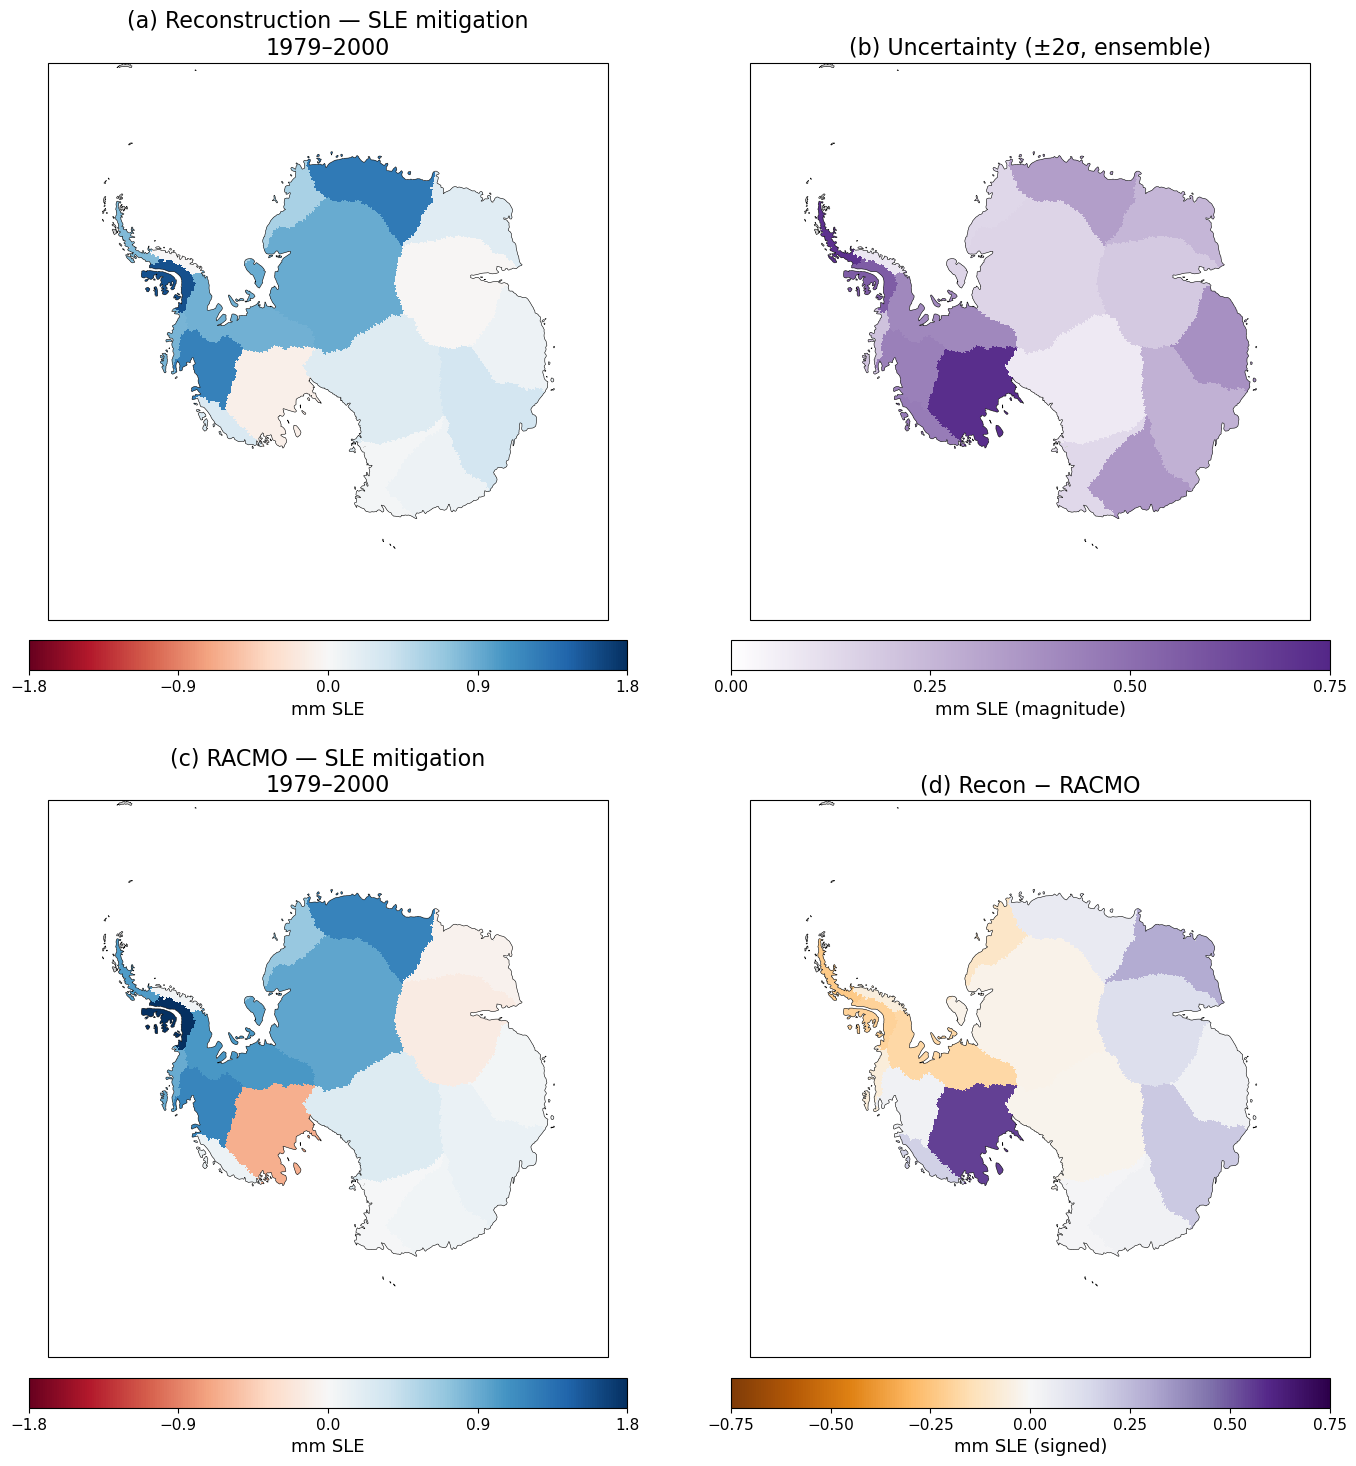

In [26]:
# ===== Basin-scale: recon SLE mitigation, its ±2σ, RACMO SLE mitigation, recon−RACMO (1979–2000) =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.colors as mcolors
GT = 361.8
yb0, yb1 = 1801, 1900          # preindustrial baseline (reconstruction mean)
yp0, yp1 = 1979, 2000          # evaluation window
npy = yp1 - yp0 + 1
ib = slice(yb0-1801, yb1-1801+1)      # 0:100
ip = slice(yp0-1801, yp1-1801+1)      # 178:200

def paint_basin(dct):
    f = np.full(basin_mask.shape, np.nan)
    for b, v in dct.items(): f[basin_mask == b] = v
    return f

recon_mit, unc2s, racmo_mit, diff = {}, {}, {}, {}
for b in basin_ids_unique:
    base = smb_basin_recon[b].loc[yb0:yb1].mean()                       # preindustrial baseline (Gt/yr)
    recon_mit[b] = (smb_basin_recon[b].loc[yp0:yp1] - base).sum() / GT  # mm SLE, positive = mitigation
    racmo_mit[b] = (smb_basin_obs[b].loc[yp0:yp1]  - base).sum() / GT   # RACMO, same baseline
    ens    = smb_basin_ens[:, :, bcol[b]]                               # (200, members)
    base_m = ens[ib].mean(0)                                            # per-member baseline
    cum_m  = (ens[ip].sum(0) - npy*base_m) / GT                         # per-member mitigation
    unc2s[b] = 2*cum_m.std(ddof=1)
    diff[b]  = recon_mit[b] - racmo_mit[b]                              # mm SLE difference

PURPLE = "#542788"                                    # PuOr's purple extreme
white_purple = mcolors.LinearSegmentedColormap.from_list("wp", ["white", PURPLE])
AC, BD = 1.8, 0.75                                    # rounded shared limits
panels = [("(a) Reconstruction — SLE mitigation\n1979–2000", recon_mit, "RdBu",       -AC, AC, "mm SLE",            np.arange(-1.8, 1.81, 0.9)),
          ("(b) Uncertainty (±2σ, ensemble)",                unc2s,     white_purple,   0, BD, "mm SLE (magnitude)", np.arange(0.0, 0.76, 0.25)),
          ("(c) RACMO — SLE mitigation\n1979–2000",          racmo_mit, "RdBu",       -AC, AC, "mm SLE",            np.arange(-1.8, 1.81, 0.9)),
          ("(d) Recon − RACMO",                              diff,      "PuOr",       -BD, BD, "mm SLE (signed)",   np.arange(-0.75, 0.76, 0.25))]

fig, axes = plt.subplots(2, 2, figsize=(15, 15), subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, (title, dct, cmap, vmn, vmx, ulab, ticks) in zip(axes.ravel(), panels):
    ax.set_extent([-180,180,-90,-60], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint_basin(dct), transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmn, vmax=vmx, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, lw=0.4, zorder=3)
    ax.set_title(title, fontsize=16)
    cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.03, shrink=0.78)
    cb.set_ticks(ticks); cb.set_label(ulab, fontsize=13); cb.ax.tick_params(labelsize=11)
plt.tight_layout()
print(f"data ranges — |a/c| max {np.nanmax(np.abs(list(recon_mit.values())+list(racmo_mit.values()))):.3f} "
      f"(limit {AC}) | b max {np.nanmax(list(unc2s.values())):.3f} | |d| max "
      f"{np.nanmax(np.abs(list(diff.values()))):.3f} (limit {BD})")
plt.show()


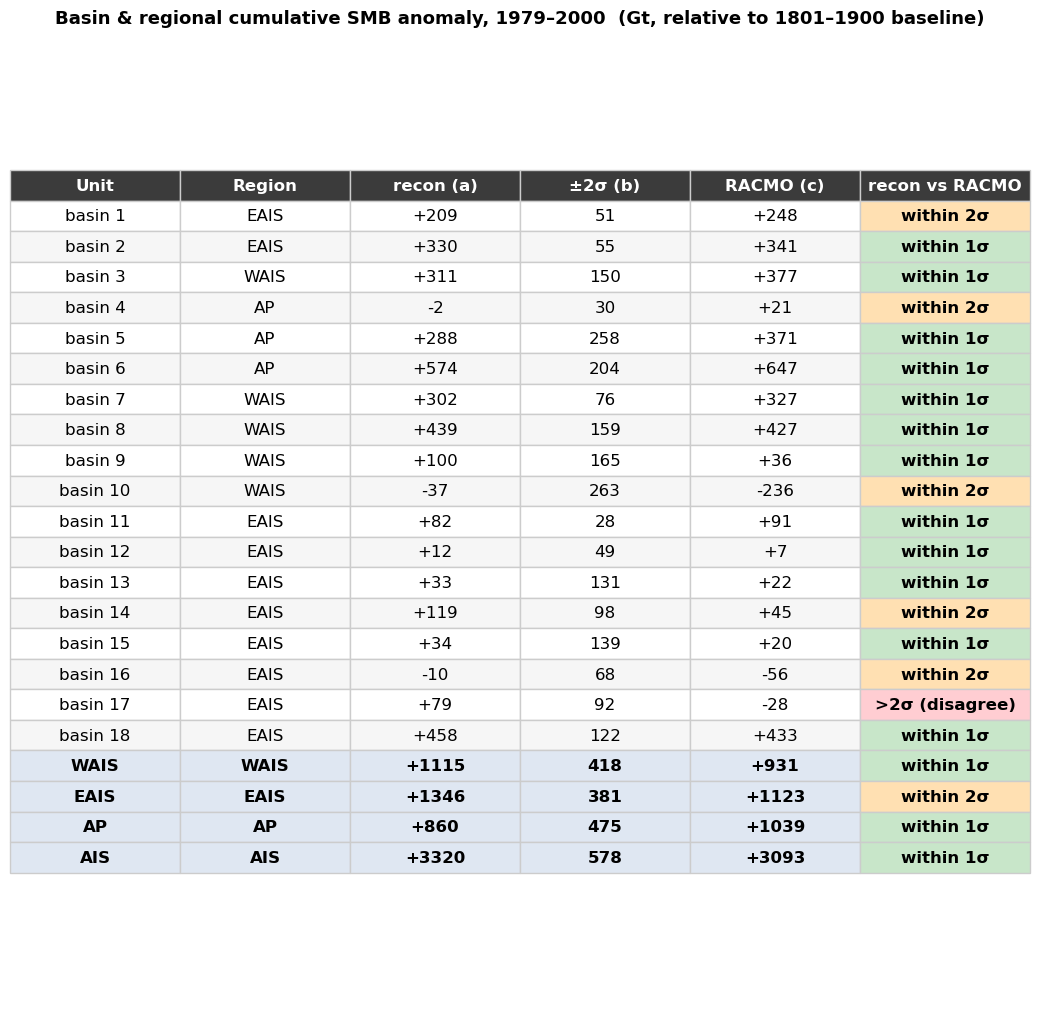

In [27]:
# ===== Table as inline image, in Gt, with 1σ / 2σ agreement flag between recon (a) and RACMO (c) =====
import matplotlib.pyplot as plt
reg_of = {}
for rr, ids in [("WAIS",[3,7,8,9,10]), ("EAIS",[1,2,11,12,13,14,15,16,17,18]), ("AP",[4,5,6])]:
    for b in ids: reg_of[b] = rr

def agree(diff, sig):                                         # sig = 1σ; returns (label, category)
    ad = abs(diff)
    if sig <= 0:            return ("n/a", -1)
    if ad <= sig:          return ("within 1σ", 0)
    if ad <= 2*sig:        return ("within 2σ", 1)
    return (">2σ (disagree)", 2)

rows = []
for b in basin_ids_unique:
    lab, cat = agree(recon_mit[b] - racmo_mit[b], unc2s[b]/2)
    rows.append((f"basin {b}", reg_of.get(b, "?"), recon_mit[b], unc2s[b], racmo_mit[b], lab, cat, False))
for r in ["WAIS", "EAIS", "AP", "AIS"]:                       # regional aggregates
    k = region_names.index(r)
    base_r = np.asarray(recon_series[r])[ib].mean()
    rec = (np.asarray(recon_series[r])[ip] - base_r).sum() / GT
    rac = (raw_series[r].loc[yp0:yp1] - base_r).sum() / GT
    ens_r = smb_reg_ens[:, :, k]; bm = ens_r[ib].mean(0)
    cm = (ens_r[ip].sum(0) - npy*bm) / GT
    sig_r = cm.std(ddof=1)
    lab, cat = agree(rec - rac, sig_r)
    rows.append((r, r, rec, 2*sig_r, rac, lab, cat, True))

col_labels = ["Unit", "Region", "recon (a)", "±2σ (b)", "RACMO (c)", "recon vs RACMO"]
cell_text = [[u, reg, f"{a*GT:+.0f}", f"{s*GT:.0f}", f"{c*GT:+.0f}", lab]
             for (u, reg, a, s, c, lab, cat, _) in rows]
cats  = [row[6] for row in rows]; is_agg = [row[7] for row in rows]
CAT_COL = {0: "#c8e6c9", 1: "#ffe0b2", 2: "#ffcdd2", -1: "#eeeeee"}   # green / amber / red / gray

fig, ax = plt.subplots(figsize=(10.5, 0.42*len(rows) + 1.0)); ax.axis("off")
tbl = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(12); tbl.scale(1, 1.5)
ncol = len(col_labels)
for (r_i, c_i), cell in tbl.get_celld().items():
    cell.set_edgecolor("0.8")
    if r_i == 0:
        cell.set_facecolor("#3b3b3b"); cell.get_text().set_color("white"); cell.get_text().set_fontweight("bold")
        continue
    cat, agg = cats[r_i-1], is_agg[r_i-1]
    if c_i == ncol - 1:                                       # agreement column — always color-coded
        cell.set_facecolor(CAT_COL[cat]); cell.get_text().set_fontweight("bold")
    elif agg:
        cell.set_facecolor("#dfe7f2"); cell.get_text().set_fontweight("bold")
    elif (r_i % 2) == 0:
        cell.set_facecolor("#f6f6f6")
ax.set_title("Basin & regional cumulative SMB anomaly, 1979–2000  (Gt, relative to 1801–1900 baseline)",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout(); plt.show()


region       recon ±2σ    RACMO
WAIS        1115 ±418       931
EAIS        1346 ±381      1123
AP           860 ±475      1039
AIS         3320 ±578      3093


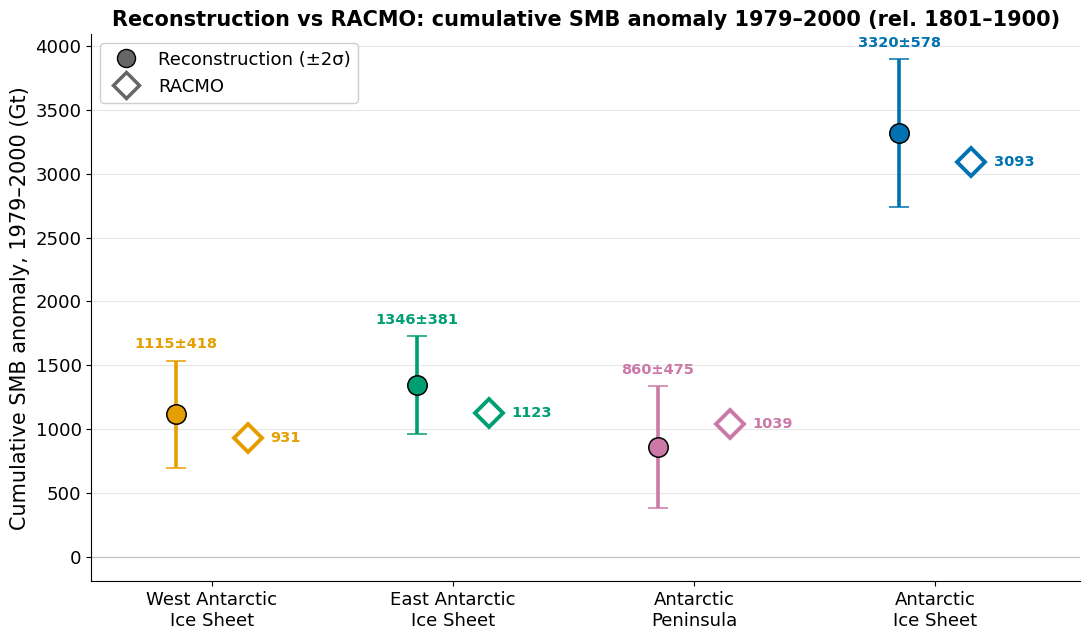

In [51]:
# ===== Reconstruction (±2σ) vs RACMO dot — cumulative SMB anomaly 1979–2000, per region =====
from matplotlib.lines import Line2D
CB = {"AIS": "#0072B2", "WAIS": "#E69F00", "EAIS": "#009E73", "AP": "#CC79A7"}
FULLNAME = {"AIS": "Antarctic\nIce Sheet", "WAIS": "West Antarctic\nIce Sheet",
            "EAIS": "East Antarctic\nIce Sheet", "AP": "Antarctic\nPeninsula"}
GT = 361.8; yp0, yp1, npy = 1979, 2000, 22
ib, ip = slice(0, 100), slice(1979-1801, 2000-1801+1)
regions4 = ["WAIS", "EAIS", "AP", "AIS"]

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.axhline(0, color="0.8", lw=0.9, zorder=0)
print(f"{'region':<6}{'recon ±2σ':>16}{'RACMO':>9}")
for i, r in enumerate(regions4):
    k = region_names.index(r); col = CB[r]
    base_r = np.asarray(recon_series[r])[ib].mean()
    ens_r = smb_reg_ens[:, :, k]; bm = ens_r[ib].mean(0)
    cm = ens_r[ip].sum(0) - npy*bm
    rec = (np.asarray(recon_series[r])[ip] - base_r).sum(); s2 = 2*cm.std(ddof=1)
    rac = (raw_series[r].loc[yp0:yp1] - base_r).sum()
    ax.errorbar(i-0.15, rec, yerr=s2, fmt="o", ms=14, color=col, ecolor=col,
                elinewidth=2.6, capsize=7, capthick=2.6, mec="black", mew=1.1, zorder=4)
    ax.plot(i+0.15, rac, "D", ms=14, mfc="white", mec=col, mew=2.8, zorder=5)
    ax.annotate(f"{rec:.0f}±{s2:.0f}", (i-0.15, rec+s2), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=10.5, color=col, fontweight="bold")
    ax.annotate(f"{rac:.0f}", (i+0.15, rac), textcoords="offset points", xytext=(16, 0),
                ha="left", va="center", fontsize=10.5, color=col, fontweight="bold")
    print(f"{r:<6}{rec:>10.0f} ±{s2:<4.0f}{rac:>9.0f}")
ax.set_xticks(range(4)); ax.set_xticklabels([FULLNAME[r] for r in regions4], fontsize=13)
ax.set_xlim(-0.5, 3.6); ax.set_ylabel("Cumulative SMB anomaly, 1979–2000 (Gt)", fontsize=15)
ax.tick_params(axis="y", labelsize=13); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
ax.legend(handles=[Line2D([0],[0], marker="o", lw=0, ms=13, mfc="0.4", mec="black", label="Reconstruction (±2σ)"),
                   Line2D([0],[0], marker="D", lw=0, ms=13, mfc="white", mec="0.4", mew=2.5, label="RACMO")],
          fontsize=13, loc="upper left", framealpha=0.95)
ax.set_title("Reconstruction vs RACMO: cumulative SMB anomaly 1979–2000 (rel. 1801–1900)",
             fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()


region  Reconstructi  RACMO2.4p1 (     MAR v3.10  HIRHAM (11 k         MetUM
WAIS            1023           858           721          1392           558
EAIS            1161          1084          1308          1325          1227
AP               924          1032           966          1345           848
AIS             3108          2973          2995          4062          2633


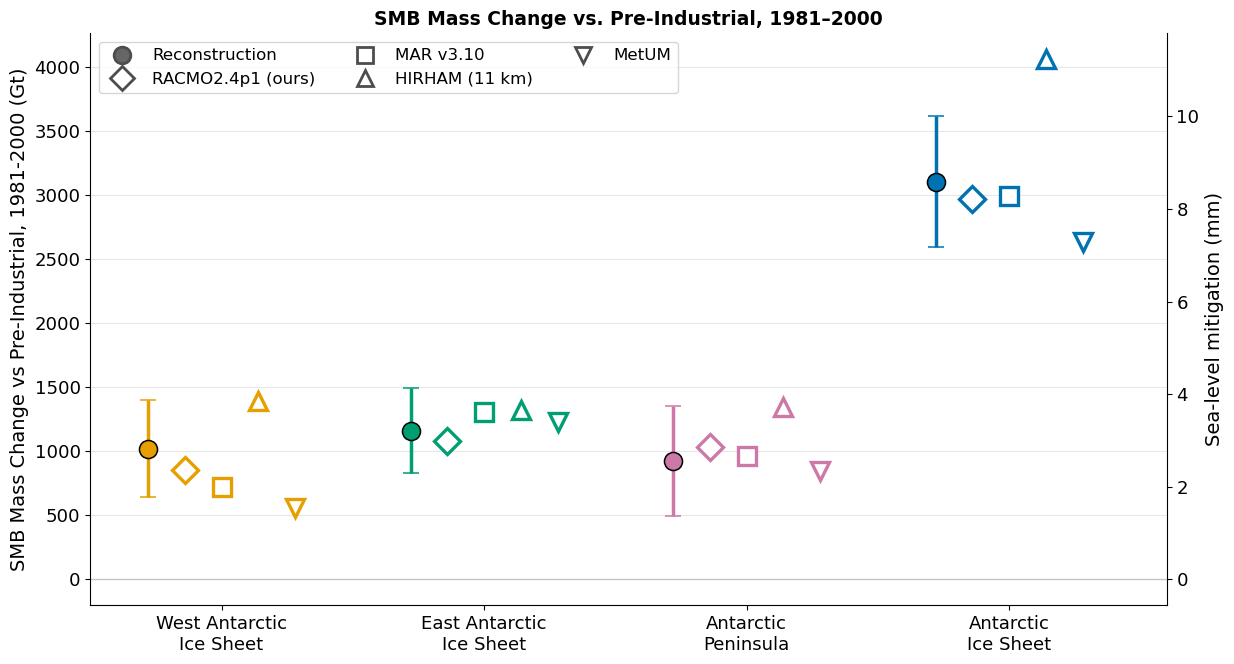

In [69]:
# ===== Cumulative SMB anomaly 1981–2000 (rel. 1801–1900): recon (±2σ) vs RACMO2.4p1, RCMs de-biased to RACMO at 1981 =====
import xarray as xr
from matplotlib.lines import Line2D
CB = {"AIS":"#0072B2","WAIS":"#E69F00","EAIS":"#009E73","AP":"#CC79A7"}
FULLNAME = {"AIS":"Antarctic\nIce Sheet","WAIS":"West Antarctic\nIce Sheet",
            "EAIS":"East Antarctic\nIce Sheet","AP":"Antarctic\nPeninsula"}
GT = 361.8
ds = xr.open_dataset(os.path.expanduser("~/DataFiles/Ant_SMB_AllModels_1981_2016.nc"), decode_times=False)
yr_rcm = ds["Year"].values.ravel().astype(int); selr = (yr_rcm >= 1981) & (yr_rcm <= 2000)
REG = {"AIS":"GAIS","WAIS":"WAIS","EAIS":"EAIS","AP":"AP"}
rcm_series = lambda mdl, r: ds[f"SMB_{REG[r]}_{mdl}"].values.ravel()[selr]      # annual SMB 1981–2000 (Gt/yr)

yp0, yp1, npy = 1981, 2000, 20
ib, ip = slice(0, 100), slice(1981-1801, 2000-1801+1)
regions4 = ["WAIS", "EAIS", "AP", "AIS"]
prods = [("Reconstruction","recon","o",True), ("RACMO2.4p1 (ours)","racmo","D",False),
         ("MAR v3.10","MAR","s",False), ("HIRHAM (11 km)","HIRHAMH","^",False), ("MetUM","MetUM","v",False)]
offs = np.linspace(-0.28, 0.28, len(prods))

def cum_anom(kind, r, base_r):
    if kind == "recon": return (np.asarray(recon_series[r])[ip] - base_r).sum()
    if kind == "racmo": return (raw_series[r].loc[yp0:yp1] - base_r).sum()
    s = rcm_series(kind, r)
    s_db = s + (raw_series[r].loc[1981] - s[0])                     # de-bias: align RCM to RACMO2.4p1 at 1981
    return (s_db - base_r).sum()

fig, ax = plt.subplots(figsize=(12.5, 6.8))
ax.axhline(0, color="0.8", lw=0.9, zorder=0)
print(f"{'region':<6}" + "".join(f"{n[:12]:>14}" for n,_,_,_ in prods))
for i, r in enumerate(regions4):
    col = CB[r]; base_r = np.asarray(recon_series[r])[ib].mean()
    k = region_names.index(r); ens_r = smb_reg_ens[:, :, k]; bm = ens_r[ib].mean(0)
    s2 = 2*(ens_r[ip].sum(0) - npy*bm).std(ddof=1)
    vals = []
    for (name, kind, mk, err), dx in zip(prods, offs):
        v = cum_anom(kind, r, base_r); vals.append(v)
        if err:
            ax.errorbar(i+dx, v, yerr=s2, fmt=mk, ms=13, color=col, ecolor=col,
                        elinewidth=2.5, capsize=6, capthick=2.5, mec="black", mew=1.1, zorder=4)
        else:
            ax.plot(i+dx, v, mk, ms=13, mfc="white", mec=col, mew=2.4, zorder=5)
    print(f"{r:<6}" + "".join(f"{x:>14.0f}" for x in vals))
ax.set_xticks(range(4)); ax.set_xticklabels([FULLNAME[r] for r in regions4], fontsize=13)
ax.set_xlim(-0.5, 3.6); ax.set_ylabel("SMB Mass Change vs Pre-Industrial, 1981-2000 (Gt)", fontsize=14)
ax.tick_params(axis="y", labelsize=13); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
for sp in ("top","right"): ax.spines[sp].set_visible(False)
secax = ax.secondary_yaxis("right", functions=(lambda g: g/GT, lambda m: m*GT))     # Gt -> mm SLE
secax.set_ylabel("Sea-level mitigation (mm)", fontsize=14); secax.tick_params(labelsize=13)
ax.legend(handles=[Line2D([0],[0], marker=mk, lw=0, ms=12, mfc=("0.4" if err else "white"), mec="0.3", mew=2, label=name)
                   for (name,_,mk,err) in prods], fontsize=12, loc="upper left", ncol=3)
ax.set_title("SMB Mass Change vs. Pre-Industrial, 1981–2000", fontsize=13.5, fontweight="bold")
plt.tight_layout(); plt.show()


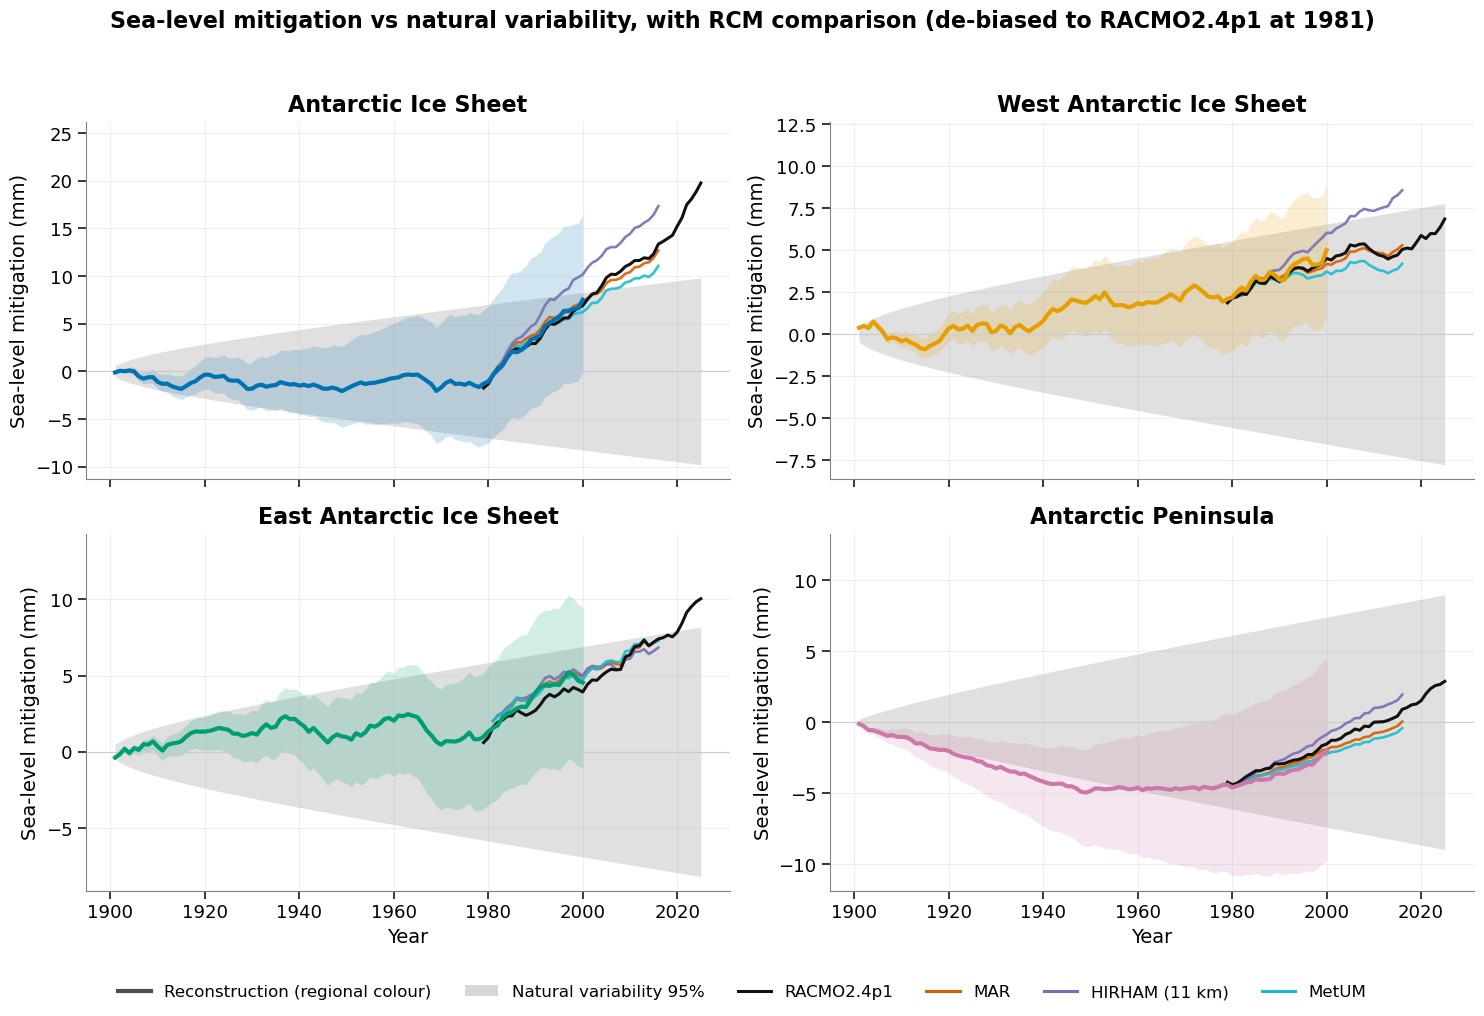

In [84]:
from scipy.stats import norm
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
CB = {"AIS": "#0072B2", "WAIS": "#E69F00", "EAIS": "#009E73", "AP": "#CC79A7"}
FULLNAME = {"AIS":"Antarctic Ice Sheet","WAIS":"West Antarctic Ice Sheet",
            "EAIS":"East Antarctic Ice Sheet","AP":"Antarctic Peninsula"}
MCOL = {"RACMO2.4p1":"#111111", "MAR":"#D55E00", "HIRHAM (11 km)":"#7570B3", "MetUM":"#17BECF"}
GT, NB, NA = 361.8, 100, 125
ds = xr.open_dataset(os.path.expanduser("~/DataFiles/Ant_SMB_AllModels_1981_2016.nc"), decode_times=False)
yr_rcm = ds["Year"].values.ravel().astype(int)
REG = {"AIS":"GAIS","WAIS":"WAIS","EAIS":"EAIS","AP":"AP"}
rcm_smb = lambda mdl, r: ds[f"SMB_{REG[r]}_{mdl}"].values.ravel()
RCM = [("MAR","MAR"), ("HIRHAM (11 km)","HIRHAMH"), ("MetUM","MetUM")]
def rcm_slm_debias(recon_ts, smb, racmo1981, start=1981, baseline=slice(0, 100)):
    r = np.asarray(recon_ts, float); base = r[baseline].mean()
    smb_db = smb + (racmo1981 - smb[0])
    return np.sum(r[:start-1801] - base)/GT + np.cumsum((smb_db - base)/GT)

def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB+NA) * fit["sigma_w"]**2)
    return np.array([np.sqrt((a := np.concatenate([np.full(NB,-n/NB),np.ones(n)])) @ R[:NB+n,:NB+n] @ a)/GT
                     for n in range(1, NA+1)])
years, cent, yr_obs = np.arange(1901, 2026), np.arange(1901, 2001), np.arange(1979, 2026)
plt.rcParams["font.size"] = 12
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    col = CB[r]
    recon_ts = np.asarray(recon_series[r]); slm_recon = sea_level_mitigation(recon_ts)
    ens = smb_reg_ens[:, :, k]
    slm_mem = np.stack([sea_level_mitigation(ens[:, m]) for m in range(ens.shape[1])])
    lo, hi = np.percentile(slm_mem, [2.5, 97.5], axis=0)
    slm_ext = extend_slm(recon_ts, raw_series[r].loc[1979:2025].values)
    sig = slm_sigma(ggm_fits[r]); racmo1981 = raw_series[r].loc[1981]
    ax.fill_between(years, -1.96*sig, 1.96*sig, color="0.78", alpha=0.55, lw=0)
    ax.fill_between(cent, lo[100:200], hi[100:200], color=col, alpha=0.18, lw=0)
    ax.plot(yr_obs, slm_ext, color=MCOL["RACMO2.4p1"], lw=2.2, zorder=6)
    for lab, mdl in RCM:
        ax.plot(yr_rcm, rcm_slm_debias(recon_ts, rcm_smb(mdl, r), racmo1981),
                color=MCOL[lab], lw=1.9, alpha=0.9, zorder=5)
    ax.plot(cent, slm_recon[100:200], color=col, lw=3.0, zorder=7)          # reconstruction on top
    ax.axhline(0, color="0.8", lw=0.8)
    ax.set_title(FULLNAME[r], fontsize=16, fontweight="bold", pad=8)
    ax.set_ylabel("Sea-level mitigation (mm)", fontsize=14)
    ax.tick_params(axis="both", labelsize=13, length=6, width=1.1); ax.grid(alpha=0.20)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color("0.5")
    lo_, hi_ = ax.get_ylim(); ax.set_ylim(lo_, hi_ + 0.15*(hi_ - lo_))
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=14)
handles = [Line2D([0],[0], color="0.3", lw=3, label="Reconstruction (regional colour)"),
           Patch(facecolor="0.78", alpha=0.7, label="Natural variability 95%")] + \
          [Line2D([0],[0], color=MCOL[m], lw=2.2, label=m) for m in ["RACMO2.4p1","MAR","HIRHAM (11 km)","MetUM"]]
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Sea-level mitigation vs natural variability, with RCM comparison (de-biased to RACMO2.4p1 at 1981)",
             fontsize=16, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0.04, 1, 0.97]); plt.show()


reg    % quad     net 2050 (mm): median [68%] [95%]
AIS       83%   -14.11  [-26.46,-1.59]  [-38.43,9.69]
WAIS      50%   -26.07  [-31.61,-18.64]  [-35.83,-12.60]
EAIS      34%     9.58  [0.59,19.45]  [-8.10,29.57]
AP        59%    -1.13  [-5.33,3.62]  [-8.63,8.19]


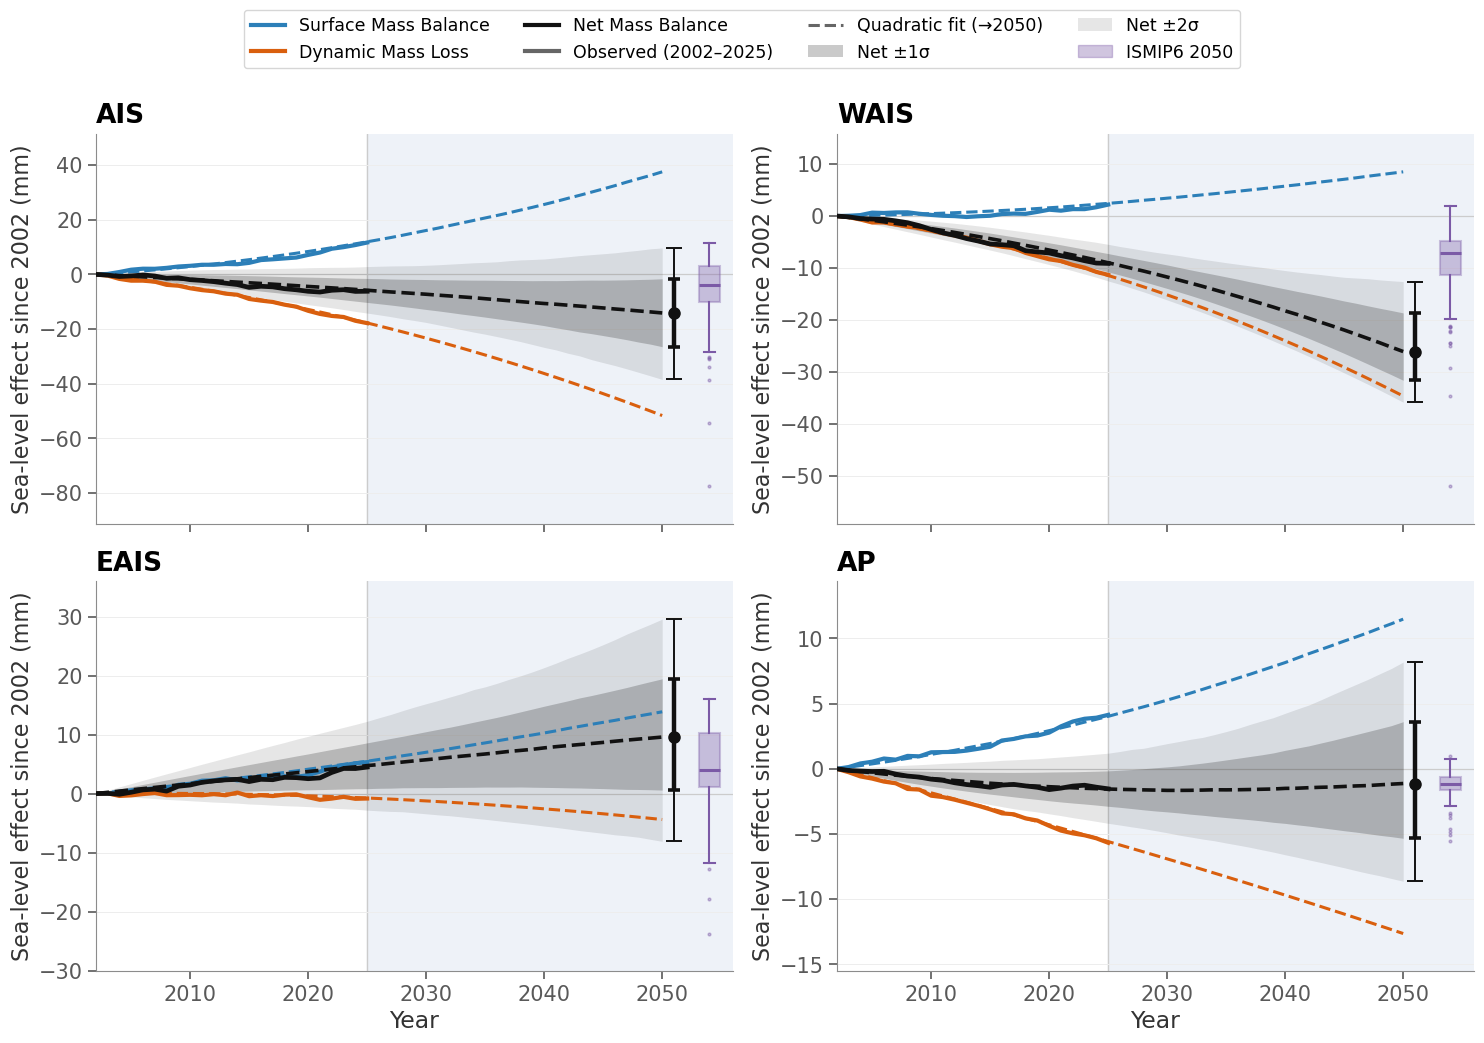

In [85]:
# ===== Cross-over → 2050: observed + fit, ISMIP boxplot, net-balance with 1σ/2σ =====
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
GT = 361.8; TARGET = 2050; N_BOOT = 4000
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
C_SMB, C_DIS, C_NET, C_IS = "#2C7FB8", "#D95F0E", "#111111", "#7B5AA6"
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()
def baseline_error(r):
    k = region_idx[r]; ib = [y-1801 for y in range(1801, 1901)]
    return smb_reg_ens[ib, :, k].mean(0).std(ddof=1)
def polyfit_cov(t, y, deg):
    X = np.vander(t, deg+1); beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta; dof = max(len(t)-(deg+1), 1); s2 = (resid @ resid)/dof
    return beta, s2 * np.linalg.inv(X.T @ X)
aic = lambda rss, n, k: n*np.log(rss/n + 1e-12) + 2*k

ismip = pd.read_csv(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_mass_Gt.csv"))
rng = np.random.default_rng(0)
allyr = np.arange(2002, TARGET+1); T = (allyr-2002).astype(float)
hist = np.arange(2002, 2026); th = (hist-2002).astype(float); n = len(th)
X1 = np.vander(th, 2); pinv1 = np.linalg.inv(X1.T@X1) @ X1.T
X2 = np.vander(th, 3); pinv2 = np.linalg.inv(X2.T@X2) @ X2.T
NET_X, IS_X = 2051.0, 2054.0
fig, axes = plt.subplots(2, 2, figsize=(15, 10.5), sharex=True)
print(f"{'reg':<5}{'% quad':>8}{'net 2050 (mm): median [68%] [95%]':>38}")
for i, (ax, r) in enumerate(zip(axes.ravel(), region_names)):
    B = baseline_mean(r); sig_base = baseline_error(r)
    smb_a = (raw_series[r].loc[2002:2025] - B).values
    g = grace_annual(grace_masks[r]).reindex(hist); black = (g - g.loc[2002]).values
    red_obs = np.cumsum(smb_a); red_obs -= red_obs[0]; green_obs = black - red_obs
    gc, gcov = polyfit_cov(th, green_obs, 2)
    br = pinv1 @ smb_a; resid_r = smb_a - X1 @ br
    a_b = (X1 @ br)[None,:] + resid_r[rng.integers(0, n, (N_BOOT, n))] + rng.normal(0, sig_base, (N_BOOT,1))
    c0 = a_b.mean(1); rss0 = ((a_b - c0[:,None])**2).sum(1)
    fit1 = (a_b @ pinv1.T) @ X1.T; rss1 = ((a_b - fit1)**2).sum(1)
    sel_quad = aic(rss1, n, 2) < aic(rss0, n, 1)
    red_b = np.cumsum(a_b, axis=1); red_b -= red_b[:, [0]]
    bc1 = red_b @ pinv1.T; bc2 = red_b @ pinv2.T
    smb_coef = np.zeros((N_BOOT, 3)); smb_coef[sel_quad] = bc2[sel_quad]; smb_coef[~sel_quad, 1:] = bc1[~sel_quad]
    dis_coef = rng.multivariate_normal(gc, gcov, N_BOOT)
    mit_s = (smb_coef[:,0:1]*T**2 + smb_coef[:,1:2]*T + smb_coef[:,2:3]) / GT
    dis_s = (dis_coef[:,0:1]*T**2 + dis_coef[:,1:2]*T + dis_coef[:,2:3]) / GT
    mit_s -= mit_s[:, [0]]; dis_s -= dis_s[:, [0]]; net_s = mit_s + dis_s
    P = lambda a, q: np.percentile(a, q, axis=0)
    n50 = net_s[:, -1]; nm = np.median(n50)
    lo1, hi1 = np.percentile(n50, [16, 84]); lo2, hi2 = np.percentile(n50, [2.5, 97.5])

    smb_obs, dis_obs, net_obs = red_obs/GT, green_obs/GT, black/GT
    v = (grace_annual(grace_masks[r]).loc[2016] - grace_annual(grace_masks[r]).loc[2002] + ismip[f"{r}_2050"].values) / GT

    ax.axvspan(2025, IS_X+2, color="#eef2f8", zorder=0)
    ax.axvline(2025, color="0.8", lw=1.0, zorder=0.5); ax.axhline(0, color="0.8", lw=0.9, zorder=1)
    # net mass-balance 1σ / 2σ bands
    ax.fill_between(allyr, P(net_s,2.5), P(net_s,97.5), color=C_NET, alpha=0.10, lw=0, zorder=2)
    ax.fill_between(allyr, P(net_s,16),  P(net_s,84),  color=C_NET, alpha=0.22, lw=0, zorder=2.5)
    for obs, med, col, lwo, lwm in [(smb_obs, P(mit_s,50), C_SMB, 3.0, 2.2),
                                    (dis_obs, P(dis_s,50), C_DIS, 3.0, 2.2),
                                    (net_obs, P(net_s,50), C_NET, 3.4, 2.6)]:
        ax.plot(hist, obs, color=col, lw=lwo, zorder=4)
        ax.plot(allyr, med, color=col, lw=lwm, ls="--", zorder=4)
    # net prediction @ 2050 with nested 1σ (thick) + 2σ (thin) whiskers
    ax.errorbar(NET_X, nm, yerr=[[nm-lo2],[hi2-nm]], fmt="none", ecolor=C_NET, elinewidth=1.4, capsize=6, capthick=1.4, zorder=6)
    ax.errorbar(NET_X, nm, yerr=[[nm-lo1],[hi1-nm]], fmt="o", ms=8, mfc=C_NET, mec=C_NET, ecolor=C_NET, elinewidth=3.2, capsize=4, capthick=2.6, zorder=7)
    ax.boxplot([v], positions=[IS_X], widths=1.8, patch_artist=True, manage_ticks=False, zorder=5,
               boxprops=dict(facecolor=C_IS, alpha=0.35, edgecolor=C_IS, lw=1.5),
               medianprops=dict(color=C_IS, lw=2.2), whiskerprops=dict(color=C_IS, lw=1.5),
               capprops=dict(color=C_IS, lw=1.5), flierprops=dict(marker=".", ms=4, mfc=C_IS, mec=C_IS, alpha=0.4))

    allv = np.concatenate([smb_obs, dis_obs, net_obs, P(mit_s,50), P(dis_s,50),
                           P(net_s,2.5), P(net_s,97.5), [lo2, hi2], v])
    lo, hi = allv.min(), allv.max(); pad = 0.12*(hi-lo)
    ax.set_ylim(lo-pad, hi+pad); ax.set_xlim(2002, IS_X+2); ax.set_xticks(np.arange(2010, 2051, 10))
    ax.set_title(r, fontweight="bold", fontsize=19, loc="left", pad=8)
    ax.grid(axis="y", color="0.93", lw=0.7); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color("0.55")
    ax.tick_params(labelsize=15, colors="0.35", length=6, width=1.2)
    ax.set_ylabel("Sea-level effect since 2002 (mm)", fontsize=16, color="0.2")
    print(f"{r:<5}{100*sel_quad.mean():>7.0f}%   {nm:>6.2f}  [{lo1:.2f},{hi1:.2f}]  [{lo2:.2f},{hi2:.2f}]")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=17, color="0.2")

handles = [Line2D([0],[0], color=C_SMB, lw=3, label="Surface Mass Balance"),
           Line2D([0],[0], color=C_DIS, lw=3, label="Dynamic Mass Loss"),
           Line2D([0],[0], color=C_NET, lw=3, label="Net Mass Balance"),
           Line2D([0],[0], color="0.4", lw=3, ls="-",  label="Observed (2002–2025)"),
           Line2D([0],[0], color="0.4", lw=2.2, ls="--", label="Quadratic fit (→2050)"),
           Patch(facecolor=C_NET, alpha=0.22, label="Net ±1σ"),
           Patch(facecolor=C_NET, alpha=0.10, label="Net ±2σ"),
           Patch(facecolor=C_IS, alpha=0.35, edgecolor=C_IS, label="ISMIP6 2050")]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=4, fontsize=12.5, frameon=True)
fig.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()


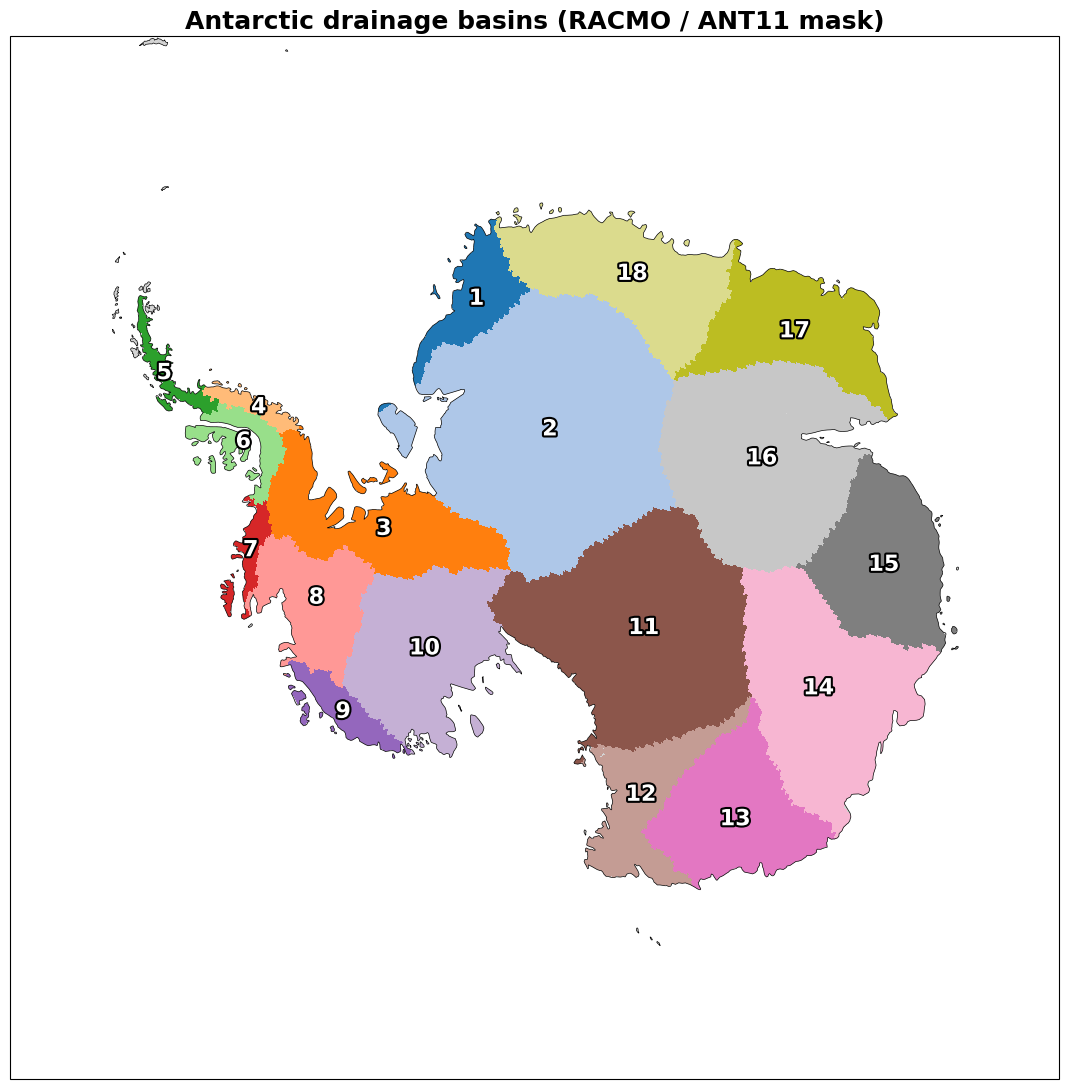

In [28]:
# ===== Basin reference map: each basin a solid color with its number overlaid =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.colors as mcolors, matplotlib.patheffects as pe

proj = ccrs.SouthPolarStereo()
idx_of = {b: i for i, b in enumerate(basin_ids_unique)}
nb = len(basin_ids_unique)
field = np.full(basin_mask.shape, np.nan)
for b in basin_ids_unique: field[basin_mask == b] = idx_of[b]

base_cols = list(plt.get_cmap("tab20").colors) + list(plt.get_cmap("tab20b").colors)
cmap = mcolors.ListedColormap([base_cols[i % len(base_cols)] for i in range(nb)])

fig, ax = plt.subplots(figsize=(11, 11), subplot_kw={"projection": proj})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.pcolormesh(lon_racmo, lat_racmo, field, transform=ccrs.PlateCarree(),
              cmap=cmap, vmin=-0.5, vmax=nb-0.5, zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
for b in basin_ids_unique:                                   # label at each basin's centroid
    m = basin_mask == b
    xy = proj.transform_points(ccrs.PlateCarree(), lon_racmo[m], lat_racmo[m])
    cx, cy = np.median(xy[:, 0]), np.median(xy[:, 1])        # median = robust to concave shapes
    ax.text(cx, cy, str(b), transform=proj, ha="center", va="center",
            fontsize=16, fontweight="bold", color="white", zorder=4,
            path_effects=[pe.withStroke(linewidth=3, foreground="black")])
ax.set_title("Antarctic drainage basins (RACMO / ANT11 mask)", fontsize=18, fontweight="bold")
plt.tight_layout(); plt.show()


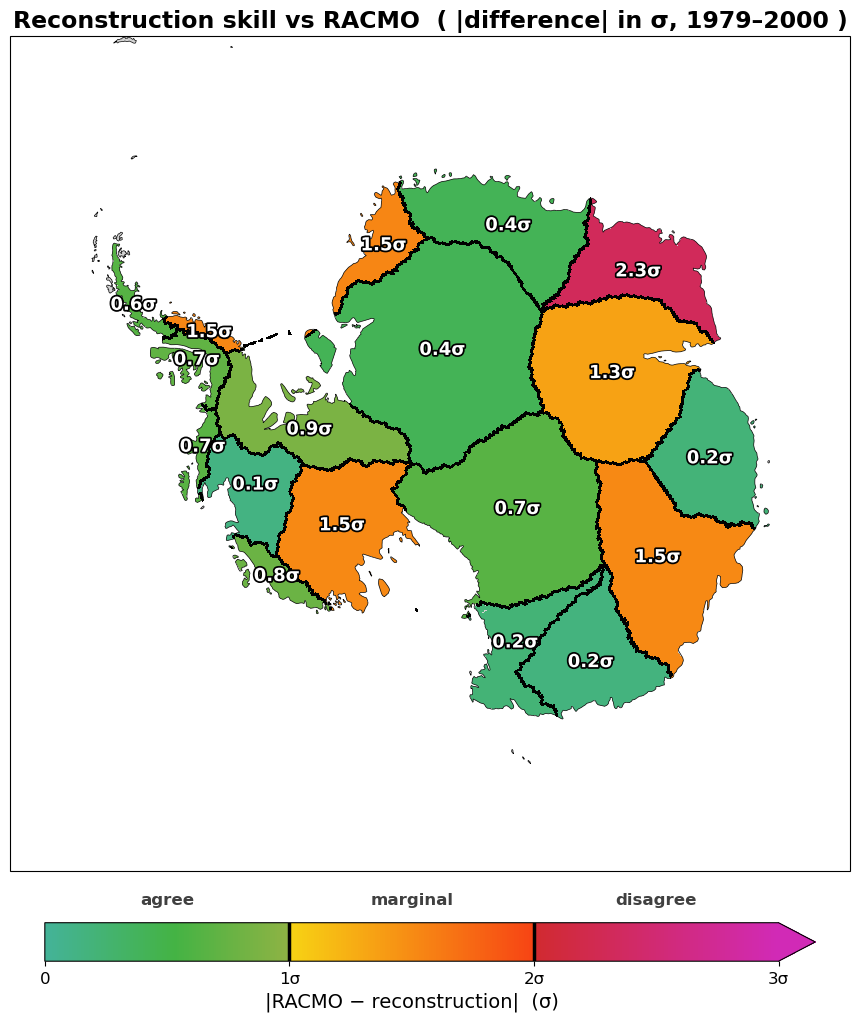

In [29]:
# ===== Skill-validation map: |RACMO − recon| in σ, hue-graded, clean basin boundaries =====
import cartopy.crs as ccrs, cartopy.feature as cfeature, matplotlib.patheffects as pe
import colorsys
from matplotlib.colors import ListedColormap, Normalize

def paint_basin(dct):
    f = np.full(basin_mask.shape, np.nan)
    for b, v in dct.items(): f[basin_mask == b] = v
    return f

absz = {}
for b in basin_ids_unique:
    ens    = smb_basin_ens[:, :, bcol[b]]
    base_m = ens[ib].mean(0)
    cum_m  = (ens[ip].sum(0) - npy*base_m) / GT
    mu, sig = cum_m.mean(), cum_m.std(ddof=1)
    absz[b] = abs(racmo_mit[b] - mu) / sig if sig > 0 else np.nan

ZCAP = 3.0
BANDS = [(0.0, 1.0, 0.46, 0.22, 0.62, 0.70),
         (1.0, 2.0, 0.14, 0.035, 0.92, 0.97),
         (2.0, ZCAP, 0.995, 0.86, 0.80, 0.82)]
def band_color(z):
    if not np.isfinite(z): return (0.93, 0.93, 0.93, 1.0)
    for zlo, zhi, h0, h1, S, V in BANDS:
        if z < zhi or zhi == ZCAP:
            f = np.clip((z - zlo) / (zhi - zlo), 0, 1)
            return (*colorsys.hsv_to_rgb((h0 + f*(h1 - h0)) % 1.0, S, V), 1.0)
grad = ListedColormap([band_color(x) for x in np.linspace(0, ZCAP, 300)]); norm = Normalize(0, ZCAP)

# --- internal basin boundaries only: cells where a neighbor is a DIFFERENT positive basin ---
bm = basin_mask; edge = np.zeros(bm.shape, bool)
dh = (bm[:, :-1] > 0) & (bm[:, 1:] > 0) & (bm[:, :-1] != bm[:, 1:]); edge[:, :-1] |= dh; edge[:, 1:] |= dh
dv = (bm[:-1, :] > 0) & (bm[1:, :] > 0) & (bm[:-1, :] != bm[1:, :]); edge[:-1, :] |= dv; edge[1:, :] |= dv
Zedge = np.where(edge, 1.0, np.nan)

proj = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(11, 11), subplot_kw={"projection": proj})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
im = ax.pcolormesh(lon_racmo, lat_racmo, paint_basin(absz), transform=ccrs.PlateCarree(),
                   cmap=grad, norm=norm, shading="nearest", zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
ax.pcolormesh(lon_racmo, lat_racmo, Zedge, transform=ccrs.PlateCarree(),         # basin boundaries
              cmap=ListedColormap(["black"]), vmin=0, vmax=1, shading="nearest", zorder=3.5)
for b in basin_ids_unique:
    m = basin_mask == b
    xy = proj.transform_points(ccrs.PlateCarree(), lon_racmo[m], lat_racmo[m])
    z = absz[b]; txt = f"{z:.1f}σ" if np.isfinite(z) else "n/a"
    ax.text(np.median(xy[:,0]), np.median(xy[:,1]), txt, transform=proj, ha="center", va="center",
            fontsize=13, fontweight="bold", color="white", zorder=4,
            path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])

cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.72, extend="max")
cb.set_ticks([0, 1, 2, 3]); cb.set_ticklabels(["0", "1σ", "2σ", "3σ"])
cb.set_label("|RACMO − reconstruction|  (σ)", fontsize=14); cb.ax.tick_params(labelsize=12)
for xb in (1, 2): cb.ax.axvline(xb, color="black", lw=2.5)
tr = cb.ax.get_xaxis_transform()
for xc, lab in [(0.5, "agree"), (1.5, "marginal"), (2.5, "disagree")]:
    cb.ax.text(xc, 1.4, lab, transform=tr, ha="center", va="bottom", fontsize=12, fontweight="bold", color="0.25")
ax.set_title("Reconstruction skill vs RACMO  ( |difference| in σ, 1979–2000 )", fontsize=17, fontweight="bold")
plt.tight_layout(); plt.show()


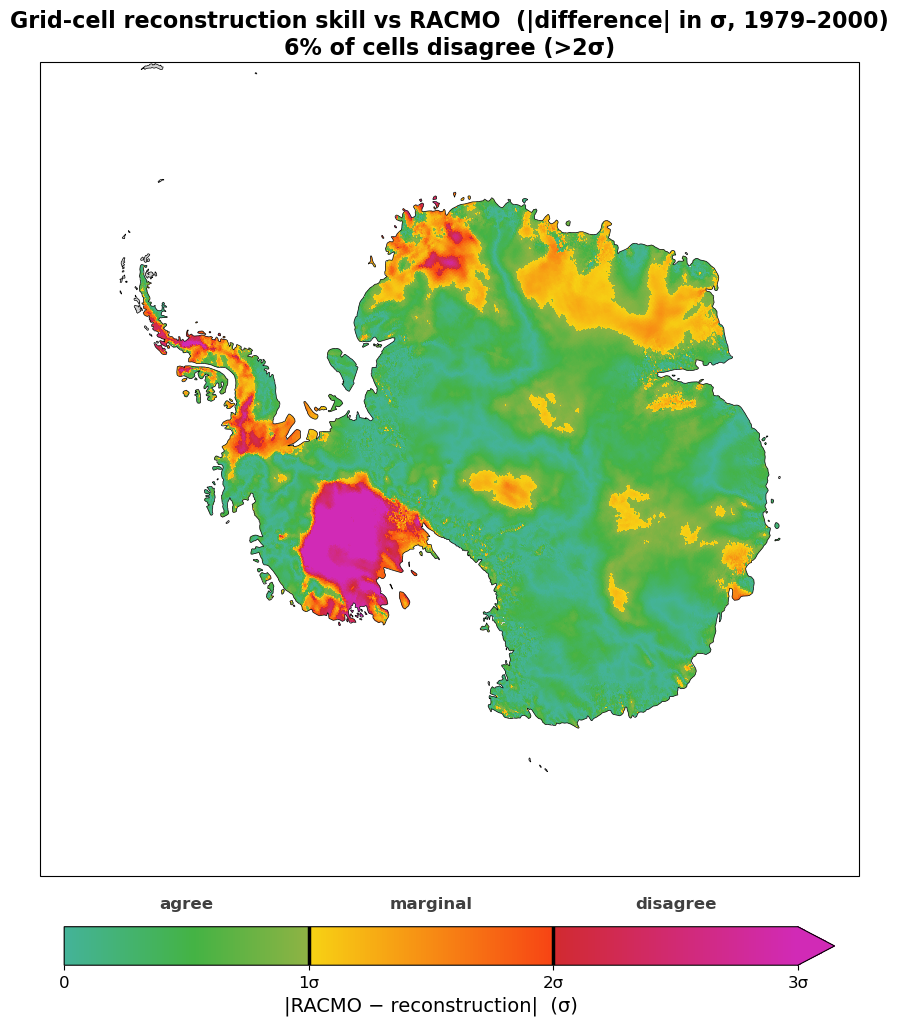

In [30]:
# ===== Skill-validation map at GRID-CELL resolution: |RACMO − recon| in σ (1979–2000) =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
import colorsys
from matplotlib.colors import ListedColormap, Normalize

GT = 361.8
ibS, ipS, npy = slice(0, 100), slice(178, 200), 22          # baseline 1801–1900, window 1979–2000

# per-cell posterior std → (200, NY, NX)
s2 = np.full((200, NY*NX), np.nan, np.float32); s2[:, valid_cells] = smb_std_v
s2 = s2.reshape(200, NY, NX)

recon_win = racmo_smb_recon[ipS]                            # posterior-mean SMB, 1979–2000 (f=1 here)
racmo_win = smb_ann.sel(year=slice(1979, 2000)).values      # raw RACMO, same years
diff  = (racmo_win - recon_win).sum(0) / GT                 # window reconstruction error (baseline cancels)
var_m = (s2[ipS]**2).sum(0) + (npy/100.0)**2 * (s2[ibS]**2).sum(0)   # window + baseline variance (yrs indep.)
sig_m = np.sqrt(var_m) / GT
with np.errstate(divide="ignore", invalid="ignore"):
    zc = np.abs(diff) / sig_m
vmask2d = valid_cells.reshape(NY, NX)
zc[~vmask2d | ~np.isfinite(sig_m) | (sig_m <= 0)] = np.nan

ZCAP = 3.0
BANDS = [(0.0, 1.0, 0.46, 0.22, 0.62, 0.70),                # green : blue-green → yellow-green
         (1.0, 2.0, 0.14, 0.035, 0.92, 0.97),               # orange: yellow → orange
         (2.0, ZCAP, 0.995, 0.86, 0.80, 0.82)]              # red   : red → magenta
def band_color(z):
    if not np.isfinite(z): return (0.93, 0.93, 0.93, 1.0)
    for zlo, zhi, h0, h1, S, V in BANDS:
        if z < zhi or zhi == ZCAP:
            f = np.clip((z - zlo) / (zhi - zlo), 0, 1)
            return (*colorsys.hsv_to_rgb((h0 + f*(h1 - h0)) % 1.0, S, V), 1.0)
grad = ListedColormap([band_color(x) for x in np.linspace(0, ZCAP, 300)]); norm = Normalize(0, ZCAP)

proj = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(11, 11), subplot_kw={"projection": proj})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
im = ax.pcolormesh(lon_racmo, lat_racmo, zc, transform=ccrs.PlateCarree(),
                   cmap=grad, norm=norm, shading="nearest", zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)

cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.72, extend="max")
cb.set_ticks([0, 1, 2, 3]); cb.set_ticklabels(["0", "1σ", "2σ", "3σ"])
cb.set_label("|RACMO − reconstruction|  (σ)", fontsize=14); cb.ax.tick_params(labelsize=12)
for xb in (1, 2): cb.ax.axvline(xb, color="black", lw=2.5)
tr = cb.ax.get_xaxis_transform()
for xc, lab in [(0.5, "agree"), (1.5, "marginal"), (2.5, "disagree")]:
    cb.ax.text(xc, 1.4, lab, transform=tr, ha="center", va="bottom", fontsize=12, fontweight="bold", color="0.25")
frac2 = np.isfinite(zc) & (zc > 2)
ax.set_title(f"Grid-cell reconstruction skill vs RACMO  (|difference| in σ, 1979–2000)\n"
             f"{100*np.nansum(frac2)/np.isfinite(zc).sum():.0f}% of cells disagree (>2σ)",
             fontsize=16, fontweight="bold")
plt.tight_layout(); plt.show()


In [31]:
b = 10; GT = 361.8
base = smb_basin_recon[b].loc[1801:1900].mean()
rc = smb_basin_recon[b].loc[1979:2000]; ra = smb_basin_obs[b].loc[1979:2000]
yr = np.arange(1979, 2001)
print(f"baseline (recon 1801–1900) : {base:8.2f} Gt/yr")
print(f"recon  1979–2000 mean       : {rc.mean():8.2f}   RACMO mean : {ra.mean():8.2f}   (recon−RACMO = {rc.mean()-ra.mean():+.2f})")
print(f"mitigation  recon           : {(rc-base).sum()/GT:+.3f} mm   RACMO : {(ra-base).sum()/GT:+.3f} mm")
print(f"slope  recon                : {np.polyfit(yr, rc.values,1)[0]:+.3f} Gt/yr²   RACMO : {np.polyfit(yr, ra.values,1)[0]:+.3f} Gt/yr²")


baseline (recon 1801–1900) :   141.90 Gt/yr
recon  1979–2000 mean       :   140.20   RACMO mean :   131.19   (recon−RACMO = +9.01)
mitigation  recon           : -0.103 mm   RACMO : -0.651 mm
slope  recon                : -1.941 Gt/yr²   RACMO : -0.832 Gt/yr²


In [32]:
# ===== SAM/temperature attribution — setup: Marshall SAM, helpers, per-cell sensitivities =====
import os, urllib.request
sam_path = os.path.expanduser("~/DataFiles/marshall_sam.txt")
if not os.path.exists(sam_path):
    urllib.request.urlretrieve("http://www.nerc-bas.ac.uk/public/icd/gjma/newsam.1957.2007.txt", sam_path)
_raw = pd.read_csv(sam_path, sep=r"\s+", header=0, index_col=0)
sam = _raw.apply(pd.to_numeric, errors="coerce").dropna().mean(axis=1); sam.index = sam.index.astype(int)
print("Marshall SAM:", int(sam.index.min()), "-", int(sam.index.max()), " n =", len(sam))

def detrend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return A - A.mean(0) - tc[:, None] * ((tc[:, None]*A).sum(0)/(tc@tc))[None, :]
def trend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return (tc[:, None] * A).sum(0) / (tc @ tc)
def _cols(da, y0, y1, scale=1.0):
    return da.sel(year=slice(y0, y1)).values.reshape(y1-y0+1, -1)[:, valid_cells] * scale
def paint_cells(v): f = np.full(NY*NX, np.nan); f[valid_cells] = v; return f.reshape(NY, NX)
def rc(a, b): m = np.isfinite(a) & np.isfinite(b); return np.corrcoef(a[m], b[m])[0, 1]

# per-cell interannual sensitivities (detrended 1979+), plain mm w.e. units
SAM_HI   = int(min(2025, sam.index.max()))
smb_rd   = detrend_cols(_cols(smb_ann, 1979, SAM_HI))
smb_rd25 = detrend_cols(_cols(smb_ann, 1979, 2025))
t2m_rd   = detrend_cols(_cols(t2m_ann, 1979, 2025))
sam_s    = sam.reindex(np.arange(1979, SAM_HI+1)).values
sam_sd   = sam_s - np.polyval(np.polyfit(np.arange(len(sam_s)), sam_s, 1), np.arange(len(sam_s)))
SAMsens_rate = (sam_sd[:, None]*smb_rd).sum(0) / (sam_sd @ sam_sd)          # mm w.e. yr⁻¹ per SAM unit
Tsens_rate   = (t2m_rd*smb_rd25).sum(0) / (t2m_rd*t2m_rd).sum(0)            # mm w.e. yr⁻¹ per K
print("Sensitivity patterns ready:", SAMsens_rate.shape, Tsens_rate.shape)


Marshall SAM: 1957 - 2025  n = 69
Sensitivity patterns ready: (101022,) (101022,)


SAM years used: 2000–2025   (SAM trend +0.27/dec)
SAM-congruent explains        42.2% (r=+0.65)
Tsens × RACMO ΔT explains     34.1% of residual variance (r=+0.58)


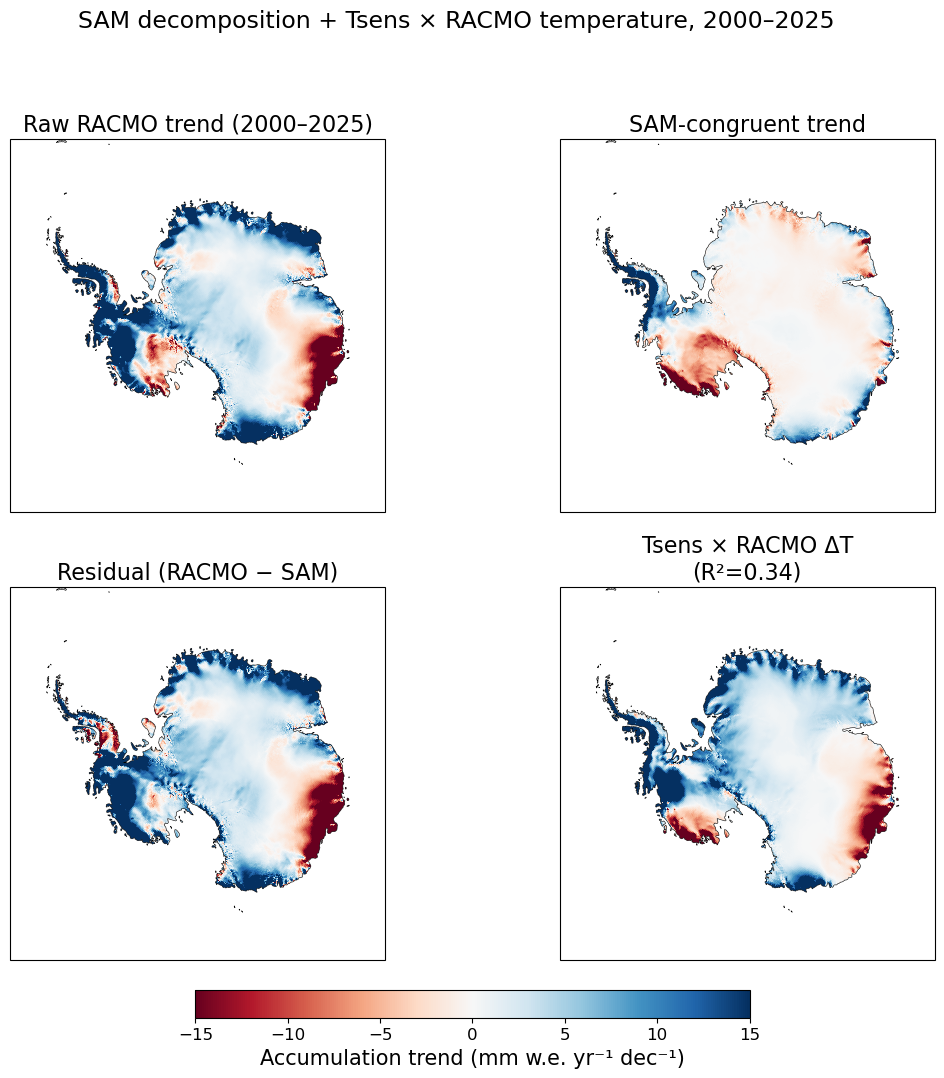

In [33]:
# ===== SAM decomposition + Tsens × RACMO temperature, 2000–2025 =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
yr0, yr1 = 2000, 2025
raw_tr25 = trend_cols(smb_ann.sel(year=slice(yr0, yr1)).values.reshape(-1, NY*NX)[:, valid_cells]) * 10
t2m_tr25 = trend_cols(t2m_ann.sel(year=slice(yr0, yr1)).values.reshape(-1, NY*NX)[:, valid_cells]) * 10   # K/dec
syr = sam.loc[yr0:yr1]; sam_tr25 = np.polyfit(np.arange(len(syr)), syr.values, 1)[0] * 10
samcong25 = SAMsens_rate * sam_tr25; resid25 = raw_tr25 - samcong25
pred_T = Tsens_rate * t2m_tr25                              # Tsens × actual RACMO warming
r_res, r_sam = rc(resid25, pred_T), rc(raw_tr25, samcong25)
print(f"SAM years used: {int(syr.index.min())}–{int(syr.index.max())}   (SAM trend {sam_tr25:+.2f}/dec)")
print(f"SAM-congruent explains       {100*r_sam**2:5.1f}% (r={r_sam:+.2f})")
print(f"Tsens × RACMO ΔT explains    {100*r_res**2:5.1f}% of residual variance (r={r_res:+.2f})")
vlim = 15
panels = [("Raw RACMO trend (2000–2025)", raw_tr25), ("SAM-congruent trend", samcong25),
          ("Residual (RACMO − SAM)", resid25), (f"Tsens × RACMO ΔT\n(R²={r_res**2:.2f})", pred_T)]
fig, axes = plt.subplots(2, 2, figsize=(13, 13), subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, (title, field) in zip(axes.ravel(), panels):
    ax.set_extent([-180,180,-90,-60], ccrs.PlateCarree()); ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint_cells(field), transform=ccrs.PlateCarree(),
                       cmap="RdBu", vmin=-vlim, vmax=vlim, shading="nearest", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.4, zorder=3)
    ax.set_title(title, fontsize=16)
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.03, shrink=0.55)
cb.set_label("Accumulation trend (mm w.e. yr⁻¹ dec⁻¹)", fontsize=15); cb.ax.tick_params(labelsize=12)
fig.suptitle("SAM decomposition + Tsens × RACMO temperature, 2000–2025", fontsize=17); plt.show()


In [34]:
# ===== Load Bromwich reconstructed T2m (independent) → brom_trend + cell mapping ii =====
import urllib.request
brom_path = os.path.expanduser("~/DataFiles/bromwich_recon_t2m_1958-2025.nc")
if not os.path.exists(brom_path):
    urllib.request.urlretrieve("https://amrdcdata.ssec.wisc.edu/dataset/16c76c35-5cf7-4001-9adc-b7b36a9ac94c/"
        "resource/29e548a9-2405-4aef-9d1e-387ab8489a12/download/recon_t2m_1958-2025_ano.final.nc", brom_path)
brom = xr.open_dataset(brom_path); bann = brom["RECON"].groupby("time.year").mean("time")
def brom_trend(y0, y1):
    sub = bann.sel(year=slice(y0, y1)).values.reshape(y1-y0+1, -1)
    tc = np.arange(sub.shape[0], dtype=float); tc -= tc.mean()
    return (tc[:, None]*sub).sum(0) / (tc @ tc) * 10                        # K/dec per Bromwich cell
blat, blon = brom["lat"].values.ravel(), brom["lon"].values.ravel()
_, ii = cKDTree(to_xyz(blat, blon)).query(to_xyz(lat_racmo.ravel()[valid_cells], lon_racmo.ravel()[valid_cells]))
print("Bromwich ready:", int(bann.year.values.min()), "-", int(bann.year.values.max()))


Bromwich ready: 1958 - 2025


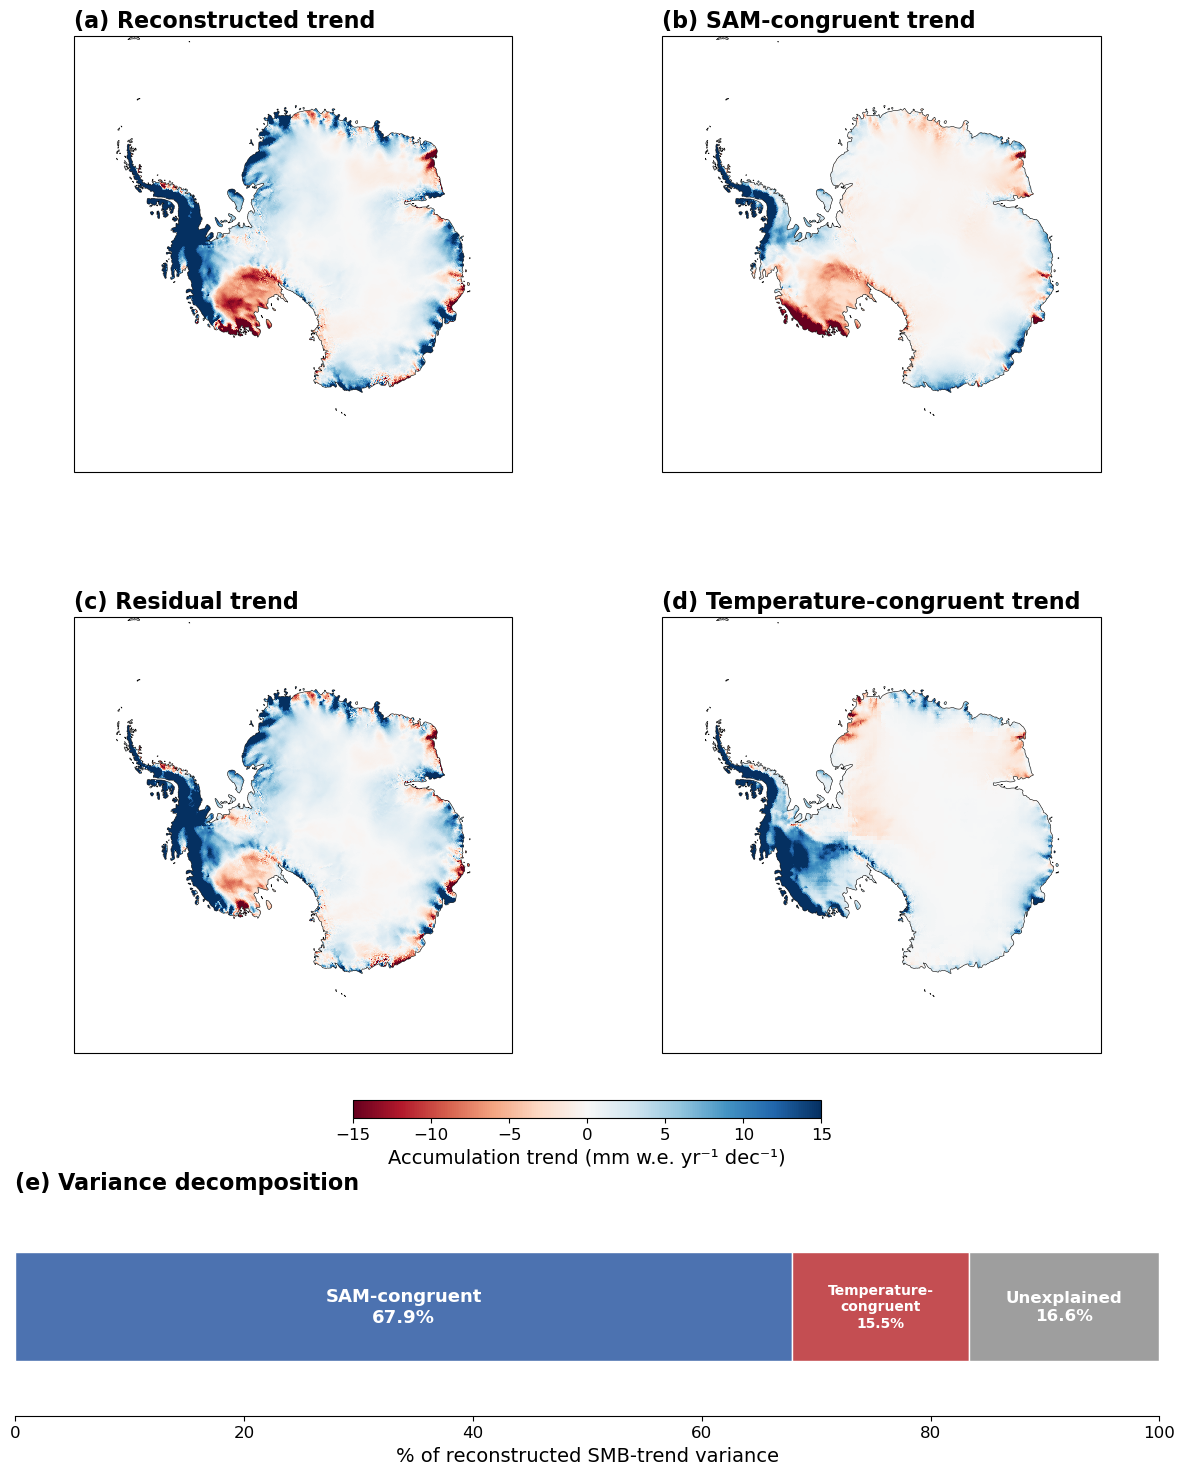

In [83]:
# ===== SAM decomposition + temperature-congruent trend + variance decomposition — reconstruction, 1958–2000 =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
sl58 = slice(1958-1801, 2000-1801+1)
recon_tr58 = trend_cols(racmo_smb_recon.reshape(200, -1)[sl58][:, valid_cells]) * 10
syr = sam.loc[1958:2000]; sam_tr58 = np.polyfit(np.arange(len(syr)), syr.values, 1)[0] * 10
samcong58 = SAMsens_rate * sam_tr58; resid58 = recon_tr58 - samcong58
pred_brom = Tsens_rate * brom_trend(1958, 2000)[ii]
r_res, r_sam = rc(resid58, pred_brom), rc(recon_tr58, samcong58)
r_sam2, r_res2 = 100*r_sam**2, 100*r_res**2

vlim = 15
panels = [("(a) Reconstructed trend", recon_tr58), ("(b) SAM-congruent trend", samcong58),
          ("(c) Residual trend", resid58), ("(d) Temperature-congruent trend", pred_brom)]
fig = plt.figure(figsize=(13, 15))
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 0.5], hspace=0.40, wspace=0.06,
                       left=0.06, right=0.94, top=0.97, bottom=0.05)
map_axes = []
for idx, (title, field) in enumerate(panels):
    ax = fig.add_subplot(gs[idx//2, idx % 2], projection=ccrs.SouthPolarStereo()); map_axes.append(ax)
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree()); ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint_cells(field), transform=ccrs.PlateCarree(),
                       cmap="RdBu", vmin=-vlim, vmax=vlim, shading="nearest", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.4, zorder=3)
    ax.set_title(title, fontsize=16, fontweight="bold", loc="left")

# --- (e) single variance-decomposition bar (all shares of TOTAL, sum to 100%) ---
axe = fig.add_subplot(gs[2, :])
C_SAM, C_T, C_U = "#4C72B0", "#C44E52", "#9e9e9e"
S = r_sam2; Rr = 100 - S; T = r_res2/100 * Rr; U = Rr - T
axe.barh(0, S, left=0,   height=0.5, color=C_SAM, edgecolor="white")
axe.barh(0, T, left=S,   height=0.5, color=C_T,   edgecolor="white")
axe.barh(0, U, left=S+T, height=0.5, color=C_U,   edgecolor="white")
axe.text(S/2,     0, f"SAM-congruent\n{S:.1f}%",              ha="center", va="center", color="white", fontweight="bold", fontsize=13)
axe.text(S+T/2,   0, f"Temperature-\ncongruent\n{T:.1f}%",   ha="center", va="center", color="white", fontweight="bold", fontsize=10)
axe.text(S+T+U/2, 0, f"Unexplained\n{U:.1f}%",               ha="center", va="center", color="white", fontweight="bold", fontsize=12)
axe.set_xlim(0, 100); axe.set_ylim(-0.5, 0.5); axe.set_yticks([])
axe.set_xlabel("% of reconstructed SMB-trend variance", fontsize=14); axe.tick_params(axis="x", labelsize=12)
for sp in ("top", "right", "left"): axe.spines[sp].set_visible(False)
axe.set_title("(e) Variance decomposition", fontsize=16, fontweight="bold", loc="left")

# --- horizontal colorbar centered in the gap between maps and (e) ---
p2 = map_axes[2].get_position(); pe = axe.get_position(); gap = p2.y0 - pe.y1
cax = fig.add_axes([0.32, pe.y1 + 0.55*gap, 0.36, 0.012])
cb = fig.colorbar(im, cax=cax, orientation="horizontal")
cb.set_label("Accumulation trend (mm w.e. yr⁻¹ dec⁻¹)", fontsize=14); cb.ax.tick_params(labelsize=12)
plt.show()


In [36]:
# ===== Order-dependent attribution: variance-explained table (no figures) =====
# SMB: reconstruction for 1958–2000, raw RACMO for 2000–2025.  Requires Bromwich loaded (brom_trend, ii).
import pandas as pd
def smb_trend(y0, y1, use_recon):
    if use_recon:
        sl = slice(y0-1801, y1-1801+1)
        return trend_cols(racmo_smb_recon.reshape(200, -1)[sl][:, valid_cells]) * 10
    return trend_cols(smb_ann.sel(year=slice(y0, y1)).values.reshape(-1, NY*NX)[:, valid_cells]) * 10
def t_congruent(y0, y1, src):
    ttr = brom_trend(y0, y1)[ii] if src == "brom" else \
          trend_cols(t2m_ann.sel(year=slice(y0, y1)).values.reshape(-1, NY*NX)[:, valid_cells]) * 10
    return Tsens_rate * ttr
def sam_congruent(y0, y1):
    syr = sam.loc[y0:y1]; return SAMsens_rate * (np.polyfit(np.arange(len(syr)), syr.values, 1)[0] * 10)

scenarios = [(1958, 2000, True,  "brom"),      # recon SMB, Bromwich T (no RACMO T before 1979)
             (2000, 2025, False, "racmo")]     # raw RACMO SMB, RACMO T
rows = []
for y0, y1, use_recon, tsrc in scenarios:
    raw = smb_trend(y0, y1, use_recon); samcong = sam_congruent(y0, y1); tcong = t_congruent(y0, y1, tsrc)
    label = f"{y0}-{y1} ({'recon' if use_recon else 'raw'} SMB, {tsrc} T)"
    r1 = rc(raw, samcong); r2 = rc(raw - samcong, tcong)                 # SAM first
    rows.append((label, "SAM → T", "SAM", 100*r1**2, "T (resid)", 100*r2**2))
    r1 = rc(raw, tcong);   r2 = rc(raw - tcong, samcong)                 # T first
    rows.append((label, "T → SAM", "T", 100*r1**2, "SAM (resid)", 100*r2**2))

tab = pd.DataFrame(rows, columns=["scenario", "order", "1st regressor", "1st %", "2nd regressor", "2nd %"])
print(tab.to_string(index=False, float_format=lambda x: f"{x:5.1f}"))


                     scenario   order 1st regressor  1st % 2nd regressor  2nd %
1958-2000 (recon SMB, brom T) SAM → T           SAM   67.9     T (resid)   48.2
1958-2000 (recon SMB, brom T) T → SAM             T   62.9   SAM (resid)   13.8
 2000-2025 (raw SMB, racmo T) SAM → T           SAM   42.2     T (resid)   34.1
 2000-2025 (raw SMB, racmo T) T → SAM             T   64.5   SAM (resid)   11.1


/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_42183/919089076.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", fontsize=13, framealpha=0.9)


area-weighted mean VR  57.3%  |  fraction of area >20% constrained: 100.0%  |  max 96%


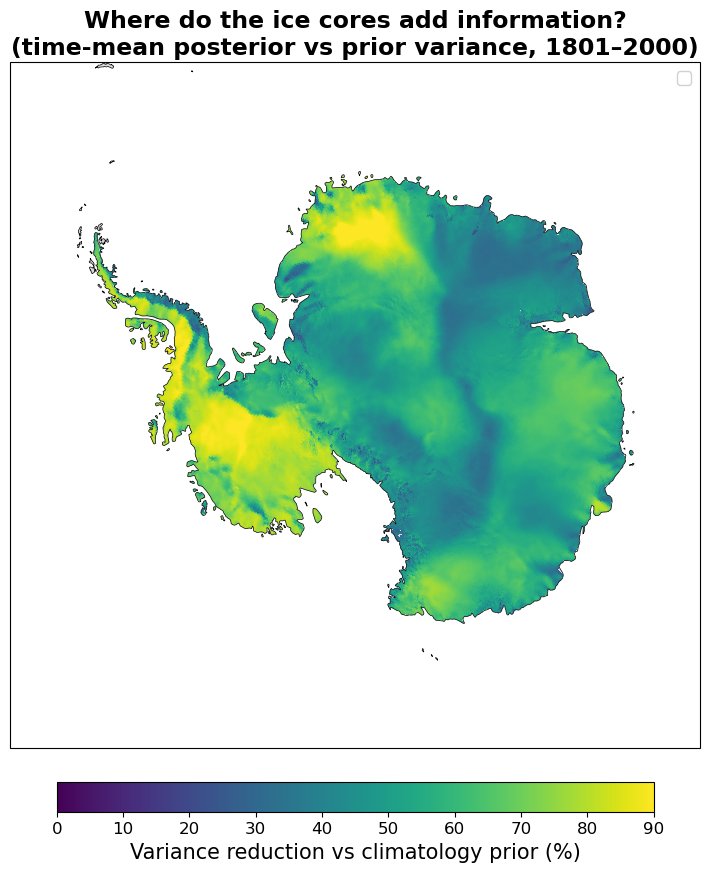

In [37]:
# ===== Constraint map: variance reduction (posterior vs RACMO-climatology prior), with core sites =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
def paint_cells(v): f = np.full(NY*NX, np.nan); f[valid_cells] = v; return f.reshape(NY, NX)

WIN = slice(0, 200)                                        # 1801–2000; try slice(100,200) for the mature network
prior_std = smb_cells.std(0, ddof=1)                       # prior = spread of the 42-member climatology ensemble
post_std  = smb_std_v[WIN].mean(0)                         # time-mean EnSRF posterior spread
vr = np.clip(1 - (post_std/np.maximum(prior_std, 1e-9))**2, 0, 1) * 100     # % variance reduction

vmax = int(np.ceil(np.nanpercentile(vr, 99)/10)*10)
cmap = plt.cm.viridis.copy(); cmap.set_bad("0.85")
proj = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(11, 11), subplot_kw={"projection": proj})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
im = ax.pcolormesh(lon_racmo, lat_racmo, paint_cells(vr), transform=ccrs.PlateCarree(),
                   cmap=cmap, vmin=0, vmax=vmax, shading="nearest", zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
#ax.scatter(core_lons, core_lats, transform=ccrs.PlateCarree(), s=30, marker="^",
           #facecolor="none", edgecolor="red", linewidths=1.5, zorder=4, label="ice cores")
cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.7)
cb.set_label("Variance reduction vs climatology prior (%)", fontsize=15); cb.ax.tick_params(labelsize=12)
ax.legend(loc="upper right", fontsize=13, framealpha=0.9)
ax.set_title("Where do the ice cores add information?\n(time-mean posterior vs prior variance, 1801–2000)",
             fontsize=17, fontweight="bold")
mk = np.isfinite(vr)
print(f"area-weighted mean VR {np.average(vr[mk], weights=_va[mk]):5.1f}%  |  "
      f"fraction of area >20% constrained: {100*np.average((vr>20)[mk], weights=_va[mk]):4.1f}%  |  max {vr.max():.0f}%")
plt.show()


(a) Is SLM INCREASING?                    significant (p<0.05): 54.4% of area
(b) Is SLM ACCELERATING?                  significant (p<0.05): 7.9% of area


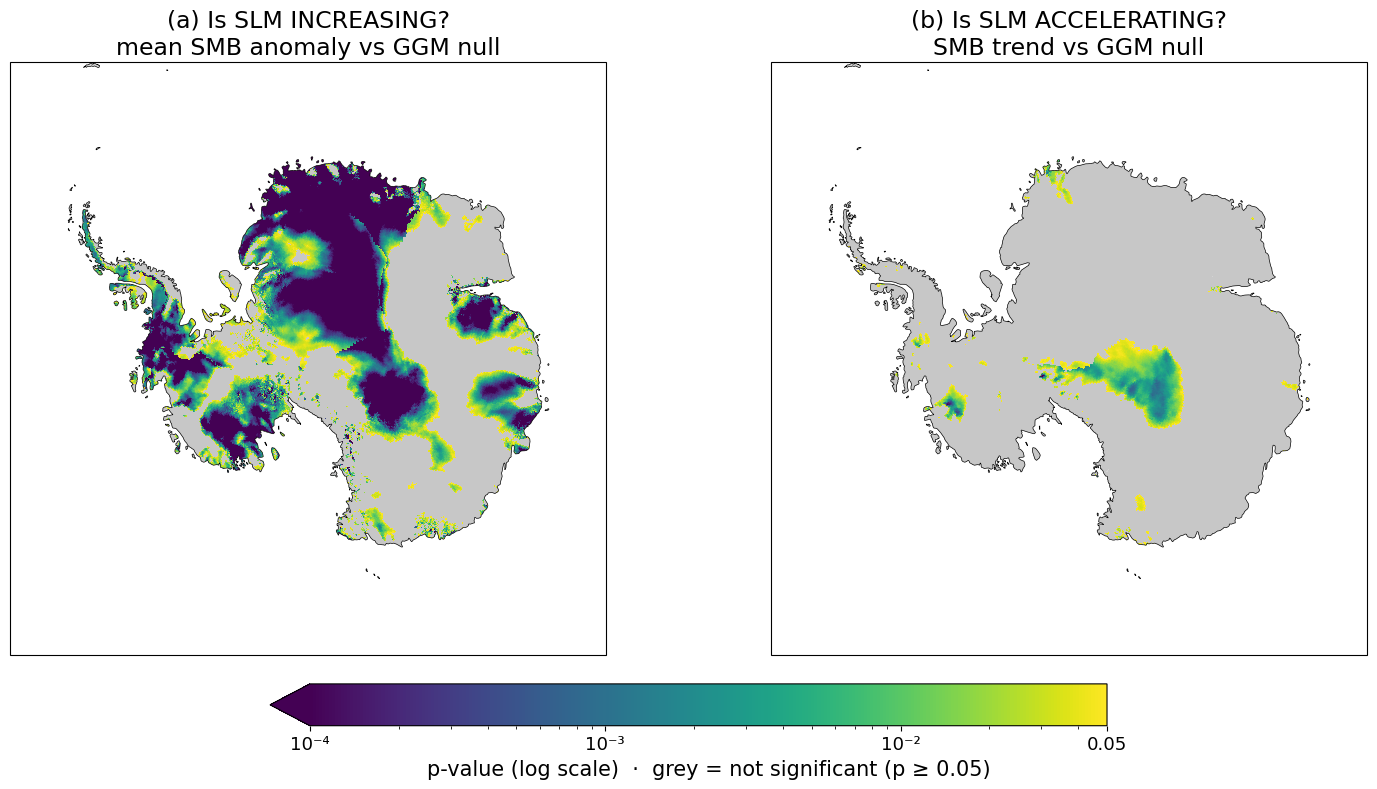

In [38]:
# ===== Two per-cell significance maps: SLM increasing & accelerating vs GGM null (log p-value) =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
from scipy.special import erfc
from matplotlib.colors import ListedColormap, LogNorm
def paint_cells(v): f = np.full(NY*NX, np.nan); f[valid_cells] = v; return f.reshape(NY, NX)
def _detrend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return A - A.mean(0) - tc[:, None]*((tc[:, None]*A).sum(0)/(tc@tc))[None, :]

YR0, YR1 = 2002, 2025; N = YR1-YR0+1
xw = np.arange(N, dtype=float); cw = xw - xw.mean(); cw = cw/(cw@cw)
Xw   = smb_ann.sel(year=slice(YR0, YR1)).values.reshape(N, -1)[:, valid_cells]
Xrec = racmo_smb_recon.reshape(200, -1)[:, valid_cells]
base = Xrec[:100].mean(0)
obs_mean  = Xw.mean(0) - base
obs_trend = (cw[:, None]*Xw).sum(0)
sigma0 = np.sqrt(_detrend_cols(Xrec[:100]).var(0, ddof=1) + (smb_std_v[:100]**2).mean(0))
basin_mean_cor = smb_basin_ens.mean(1); sm_u, st_u = {}, {}
for b in basin_ids_unique:
    f = ggm_fit(basin_mean_cor[0:100, bcol[b]])
    C = _toeplitz(_ggm_acf(f["kappa"], f["phi"], N)); C = C/C[0, 0]
    sm_u[b] = np.sqrt(np.ones(N) @ C @ np.ones(N))/N
    st_u[b] = np.sqrt(cw @ C @ cw)
bpos = {b: i for i, b in enumerate(basin_ids_unique)}
sm = np.array([sm_u[b] for b in basin_ids_unique])[[bpos[b] for b in basin_ids]]
st = np.array([st_u[b] for b in basin_ids_unique])[[bpos[b] for b in basin_ids]]
SQ2 = np.sqrt(2)
p_incr  = erfc(np.abs(obs_mean)  / (np.maximum(sigma0*sm, 1e-12)*SQ2))
p_accel = erfc(np.abs(obs_trend) / (np.maximum(sigma0*st, 1e-12)*SQ2))

PFLOOR = 1e-4                                                   # darkest color; smaller p clips here
cmap = plt.cm.viridis.copy(); cmap.set_bad((0, 0, 0, 0))       # nan (not-significant) → transparent
norm = LogNorm(vmin=PFLOOR, vmax=0.05, clip=True)
proj = ccrs.SouthPolarStereo()
fig, axes = plt.subplots(1, 2, figsize=(18, 9.5), subplot_kw={"projection": proj})
for ax, p, ttl in [(axes[0], p_incr,  "(a) Is SLM INCREASING?\nmean SMB anomaly vs GGM null"),
                   (axes[1], p_accel, "(b) Is SLM ACCELERATING?\nSMB trend vs GGM null")]:
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.pcolormesh(lon_racmo, lat_racmo, paint_cells(np.ones_like(p)), transform=ccrs.PlateCarree(),
                  cmap=ListedColormap(["0.78"]), vmin=0, vmax=1, shading="nearest", zorder=1)
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint_cells(np.where(p < 0.05, np.clip(p, 1e-8, 0.05), np.nan)),
                       transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, shading="nearest", zorder=1.5)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
    ax.set_title(ttl, fontsize=17)
    print(f"{ttl.splitlines()[0]:40s}  significant (p<0.05): {100*np.average((p<0.05), weights=_va):.1f}% of area")
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.04, shrink=0.6, extend="min")
cb.set_ticks([1e-4, 1e-3, 1e-2, 0.05]); cb.set_ticklabels(["10⁻⁴", "10⁻³", "10⁻²", "0.05"])
cb.set_label("p-value (log scale)  ·  grey = not significant (p ≥ 0.05)", fontsize=15); cb.ax.tick_params(labelsize=13)
plt.show()


reg    kappa accel(Gt/yr²)  p_accel  meanAnom(Gt/yr)  p_incr
AIS     0.00          8.08    0.008            184.1   0.000
WAIS    0.00          3.27    0.194             36.8   0.029
EAIS    0.00          2.43    0.362             84.8   0.000
AP      0.63          2.39    0.132             62.5   0.000


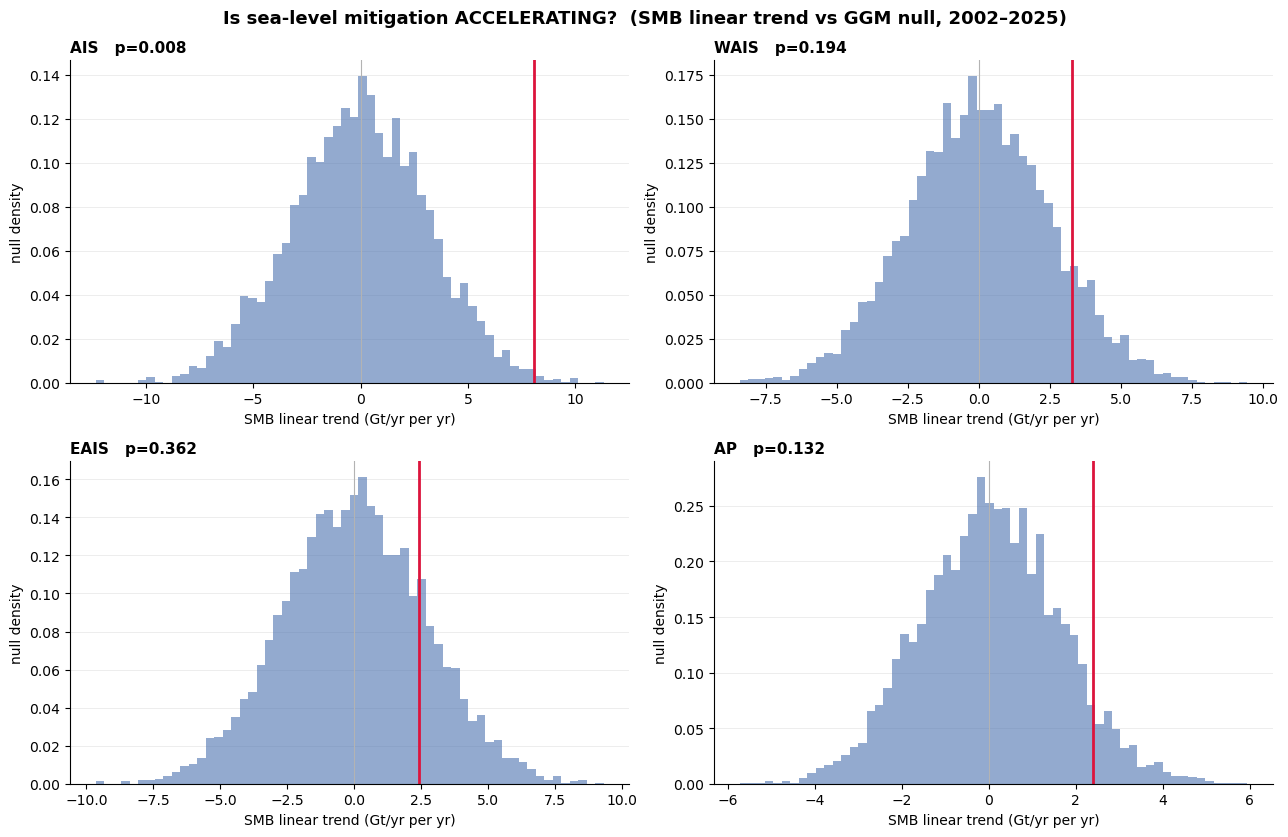

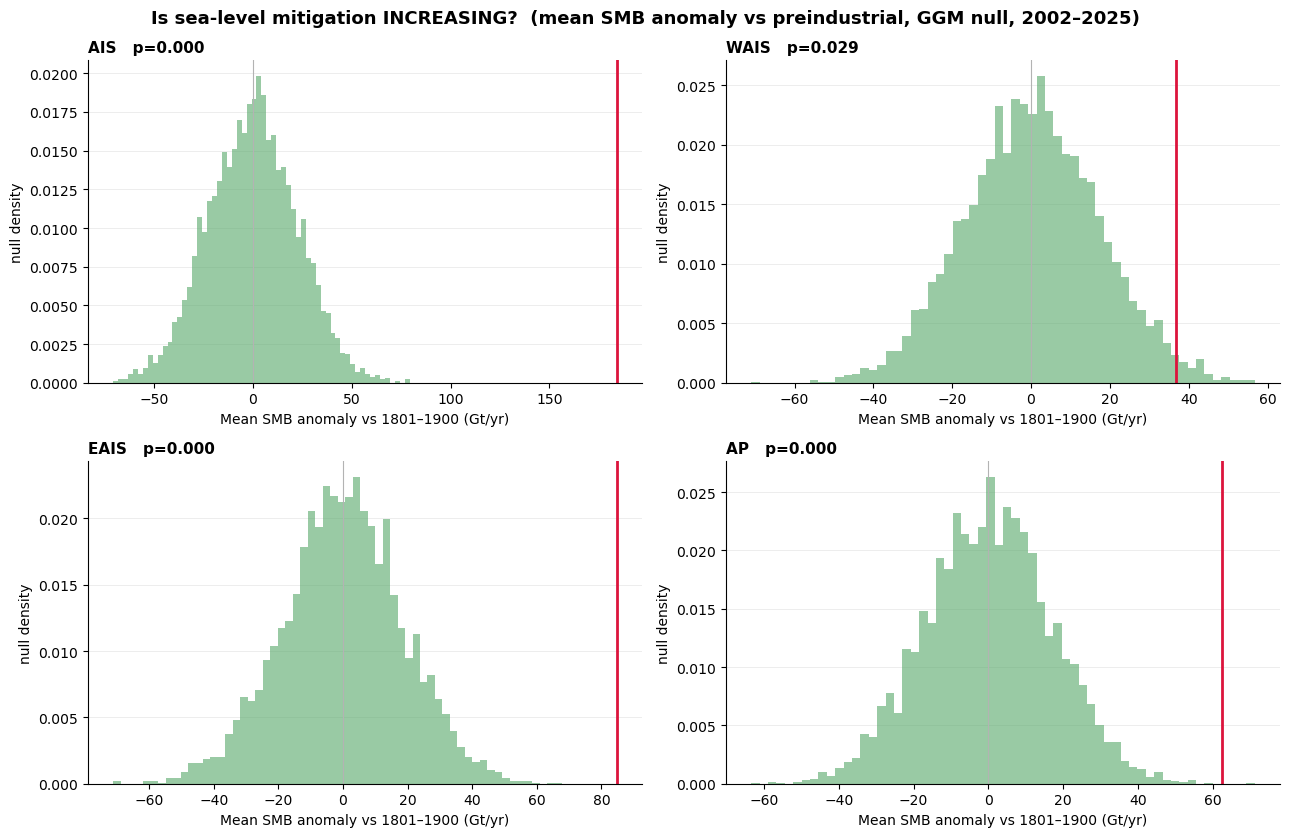

In [39]:
# ===== Two tests on sea-level mitigation: acceleration vs mere increase (GGM null only, 2002–2025) =====
from numpy.random import default_rng
rng = default_rng(0)
YR0, YR1 = 2002, 2025
N = YR1 - YR0 + 1; x = np.arange(N, dtype=float); N_SURR = 5000
lintrend = lambda v: np.polyfit(x, v, 1)[0]
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()

fig_a, axes_a = plt.subplots(2, 2, figsize=(13, 8.5))    # acceleration (SMB trend → SLM curvature)
fig_b, axes_b = plt.subplots(2, 2, figsize=(13, 8.5))    # increase   (mean anomaly → SLM slope)
print(f"{'reg':<5}{'kappa':>7}{'accel(Gt/yr²)':>14}{'p_accel':>9}{'meanAnom(Gt/yr)':>17}{'p_incr':>8}")
for aa, ab, r in zip(axes_a.ravel(), axes_b.ravel(), region_names):
    smb = raw_series[r].loc[YR0:YR1].values.astype(float)
    B = baseline_mean(r)
    obs_trend = lintrend(smb)                            # acceleration of SLM
    obs_mean  = smb.mean() - B                           # slope of SLM = mean SMB anomaly vs preindustrial

    fit = ggm_fits[r]
    acf = _ggm_acf(fit["kappa"], fit["phi"], N) * fit["sigma_w"]**2
    L = np.linalg.cholesky(_toeplitz(acf))
    surr = L @ rng.standard_normal((N, N_SURR))          # zero-mean GGM surrogates, shared by both tests
    null_trend = np.polyfit(x, surr, 1)[0]
    null_mean  = surr.mean(axis=0)
    p_accel = (np.abs(null_trend) >= abs(obs_trend)).mean()
    p_incr  = (np.abs(null_mean)  >= abs(obs_mean)).mean()

    aa.hist(null_trend, bins=60, density=True, color="#4C72B0", alpha=0.6)
    aa.axvline(obs_trend, color="crimson", lw=2)
    aa.axvline(0, color="0.7", lw=0.8)
    aa.set_title(f"{r}   p={p_accel:.3f}", fontsize=11, fontweight="bold", loc="left")
    aa.set_xlabel("SMB linear trend (Gt/yr per yr)"); aa.set_ylabel("null density")
    for sp in ("top","right"): aa.spines[sp].set_visible(False)
    aa.grid(axis="y", color="0.93", lw=0.7); aa.set_axisbelow(True)

    ab.hist(null_mean, bins=60, density=True, color="#55A868", alpha=0.6)
    ab.axvline(obs_mean, color="crimson", lw=2)
    ab.axvline(0, color="0.7", lw=0.8)
    ab.set_title(f"{r}   p={p_incr:.3f}", fontsize=11, fontweight="bold", loc="left")
    ab.set_xlabel("Mean SMB anomaly vs 1801–1900 (Gt/yr)"); ab.set_ylabel("null density")
    for sp in ("top","right"): ab.spines[sp].set_visible(False)
    ab.grid(axis="y", color="0.93", lw=0.7); ab.set_axisbelow(True)

    print(f"{r:<5}{fit['kappa']:>7.2f}{obs_trend:>14.2f}{p_accel:>9.3f}{obs_mean:>17.1f}{p_incr:>8.3f}")

fig_a.suptitle("Is sea-level mitigation ACCELERATING?  (SMB linear trend vs GGM null, 2002–2025)",
               fontsize=13, fontweight="bold")
fig_b.suptitle("Is sea-level mitigation INCREASING?  (mean SMB anomaly vs preindustrial, GGM null, 2002–2025)",
               fontsize=13, fontweight="bold")
fig_a.tight_layout(); fig_b.tight_layout(); plt.show()


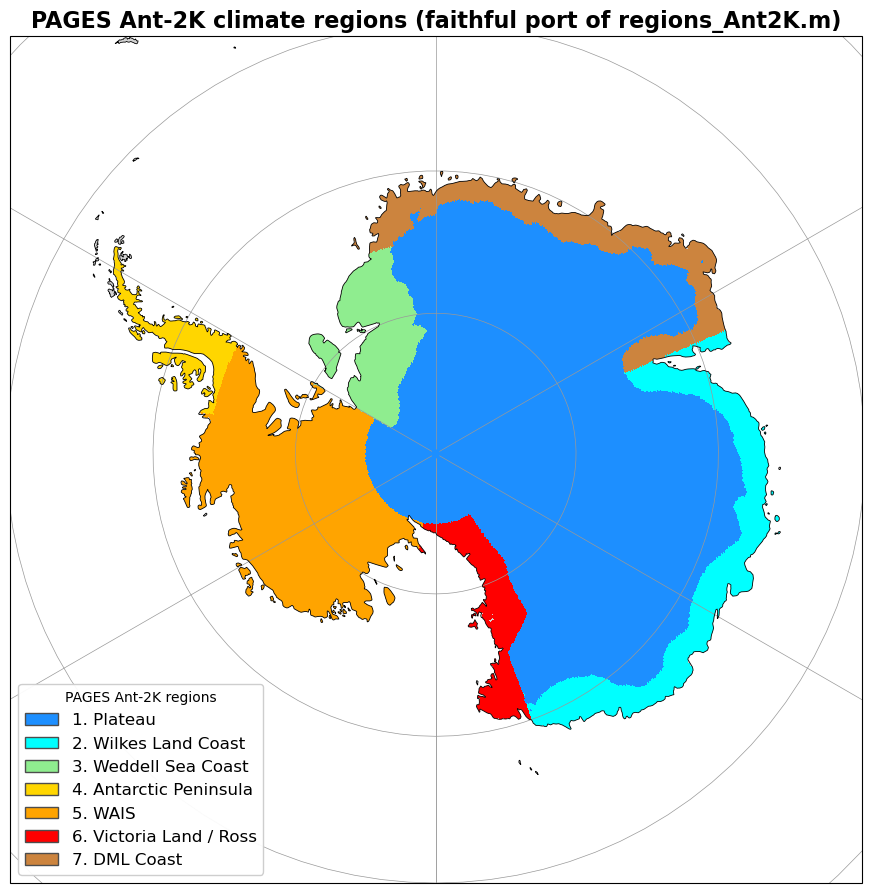

In [45]:
# ===== PAGES Ant-2K 7 climate regions — faithful port (exact vlonlim, NaN outside file range) =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
elev = xr.open_dataset(os.path.expanduser("~/DataFiles/ANT11_masks.nc"))["Topography"].values
assert elev.shape == lat_racmo.shape

_VL_LAT = np.array([-85,-84,-83,-82,-81,-80,-79,-78,-77,-76,-75,-74,-73,-72,-71,-70,-69,-68,-67,-66,-65,-64,-63])
_VL_LON = np.array([150,150,149,148,147,149,150,150,150,155,160,160,160,160,160,160,160,160,160,160,160,160,160])

def regions_ant2k(lat, lon, elev):
    lon = np.mod(lon, 360.0); reg = np.full(lat.shape, np.nan)
    PlateauAlti, Peni, Wed, bAI = 2000.0, -74.0, 330.0, 67.0
    vlonlim = np.interp(lat, _VL_LAT, _VL_LON, left=np.nan, right=np.nan)   # NaN outside file range (as in interp1)
    with np.errstate(invalid="ignore"):                                    # NaN comparisons → False (intended)
        reg[(lon < 145) & (elev > PlateauAlti)] = 1
        reg[(lon >= 145) & (lon < 190) & (elev >= 0) & (lon < vlonlim)] = 1
        reg[(lon >= 145) & (lon < 350) & (lat < -84) & (elev >= 0)] = 1
        reg[(lon < 30) & (elev > PlateauAlti)] = 0
        reg[(lon >= 300) & (elev > PlateauAlti)] = 0
        reg[(lon > Wed) & (elev < PlateauAlti) & (lat > -76) & (elev >= 0)] = 7
        reg[(lon > 0) & (lon < bAI) & (elev < PlateauAlti)] = 7
        reg[(lon > Wed) & (elev < PlateauAlti) & (lat < -75) & (elev >= 0)] = 3
        reg[(lon >= 300) & (lon < Wed) & (elev < PlateauAlti)] = 3
        reg[(lon >= bAI) & (lon < 145) & (elev < PlateauAlti)] = 2
        reg[(lon >= 145) & (lon < 160) & (elev >= 0) & (lon < vlonlim) & (elev < PlateauAlti) & (lat > -72)] = 2
        reg[(lon >= 145) & (lon < 190) & (elev >= 0) & (lat < -74) & (lon > vlonlim)] = 6
        reg[(lon >= 160) & (lon < 190) & (elev >= 0) & (lon > vlonlim)] = 6
        reg[(lon >= 190) & (lon < 280) & (lat > -85) & (elev >= 0)] = 5
        reg[(lon >= 280) & (lon < 300) & (lat > -85) & (lat < Peni+0.5) & (elev >= 0)] = 5
        reg[(lon >= 280) & (lon < 305) & (lat > Peni) & (elev >= 0)] = 4
    return reg

region_pages = regions_ant2k(lat_racmo, lon_racmo, elev)
region_pages[region_pages == 0] = 1
region_pages[~ice_sheet] = np.nan
region_valid = region_pages.reshape(-1)[valid_cells]

REGION_NAMES = {1:"Plateau", 2:"Wilkes Land Coast", 3:"Weddell Sea Coast", 4:"Antarctic Peninsula",
                5:"WAIS", 6:"Victoria Land / Ross", 7:"DML Coast"}
REGION_COLORS = ["#1D8FFF", "#00FFFF", "#8FED8F", "#FFD600", "#FFA400", "#FF0000", "#CC843E"]
cmap = ListedColormap(REGION_COLORS); norm = BoundaryNorm(np.arange(0.5, 8), 7)

fig, ax = plt.subplots(figsize=(11, 11), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.pcolormesh(lon_racmo, lat_racmo, region_pages, transform=ccrs.PlateCarree(),
              cmap=cmap, norm=norm, shading="nearest", zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.6, zorder=3)
ax.gridlines(color="0.6", lw=0.5)
ax.legend(handles=[Patch(facecolor=REGION_COLORS[i], edgecolor="0.3", label=f"{i+1}. {REGION_NAMES[i+1]}")
                   for i in range(7)], loc="lower left", fontsize=12, framealpha=0.95, title="PAGES Ant-2K regions")
ax.set_title("PAGES Ant-2K climate regions (faithful port of regions_Ant2K.m)", fontsize=16, fontweight="bold")
plt.show()


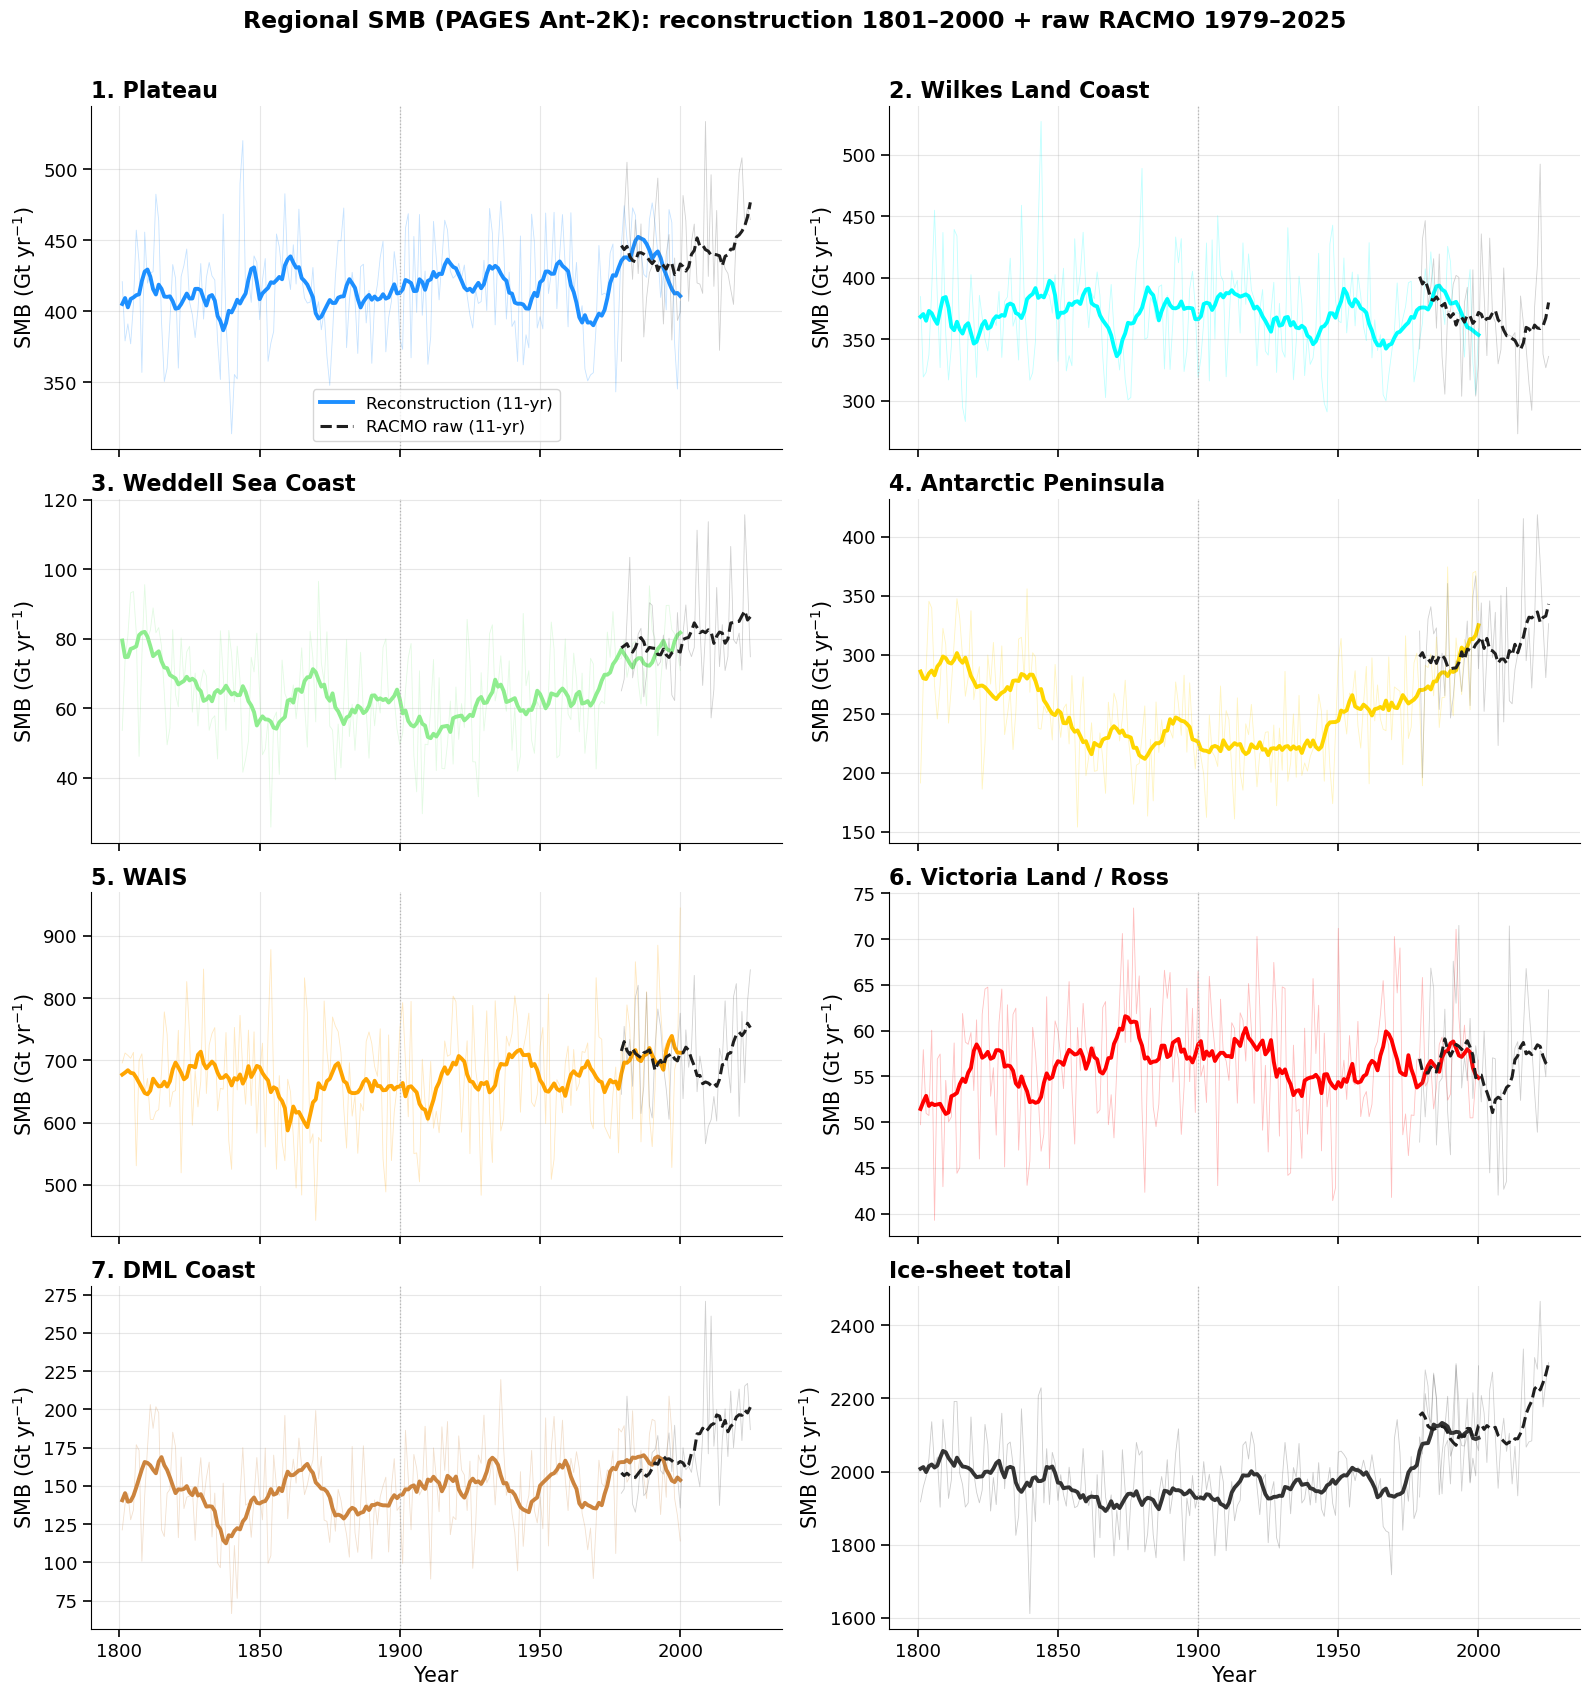

In [46]:
# ===== SMB time series for each of the 7 PAGES Ant-2K regions =====
from matplotlib.lines import Line2D
valid2d = valid_cells.reshape(NY, NX)
regmask = {r: (region_pages == r) & valid2d for r in range(1, 8)}     # grounded cells per region
def integ(cube, r):                                                    # area-integrated SMB (Gt/yr)
    m = regmask[r]
    return (cube[:, m] * cell_area_m2[m]).sum(1) / 1e12
rec = {r: integ(racmo_smb_recon, r) for r in range(1, 8)}              # reconstruction 1801–2000
raw = {r: integ(smb_ann.values, r) for r in range(1, 8)}              # raw RACMO 1979–2025
rec["AIS"] = sum(rec[r] for r in range(1, 8)); raw["AIS"] = sum(raw[r] for r in range(1, 8))
roll = lambda s, w=11: pd.Series(np.asarray(s, float)).rolling(w, center=True, min_periods=6).mean().values

panels = [(r, f"{r}. {REGION_NAMES[r]}", REGION_COLORS[r-1]) for r in range(1, 8)] + [("AIS", "Ice-sheet total", "#333333")]
fig, axes = plt.subplots(4, 2, figsize=(16, 17), sharex=True)
for ax, (key, title, col) in zip(axes.ravel(), panels):
    ax.plot(recon_years, rec[key], color=col, lw=0.6, alpha=0.25)
    ax.plot(recon_years, roll(rec[key]), color=col, lw=2.8, label="Reconstruction (11-yr)")
    ax.plot(years_obs, raw[key], color="0.4", lw=0.6, alpha=0.30)
    ax.plot(years_obs, roll(raw[key]), color="0.12", lw=2.2, ls="--", label="RACMO raw (11-yr)")
    ax.axvline(1900, color="0.7", lw=0.9, ls=":")
    ax.set_title(title, fontsize=16, fontweight="bold", loc="left")
    ax.set_ylabel("SMB (Gt yr$^{-1}$)", fontsize=15)
    ax.tick_params(labelsize=13, length=6, width=1.2); ax.grid(alpha=0.3)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
axes.ravel()[0].legend(fontsize=12, loc="best")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=15)
fig.suptitle("Regional SMB (PAGES Ant-2K): reconstruction 1801–2000 + raw RACMO 1979–2025",
             fontsize=17, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.985]); plt.show()


reg                         r (annual)     n
1. Plateau                        0.35   200
2. Wilkes Land Coast              0.58   200
3. Weddell Sea Coast              0.48   192
4. Antarctic Peninsula            0.60   200
5. WAIS                           0.74   200
6. Victoria Land / Ross           0.41   200
7. DML Coast                      0.42   200


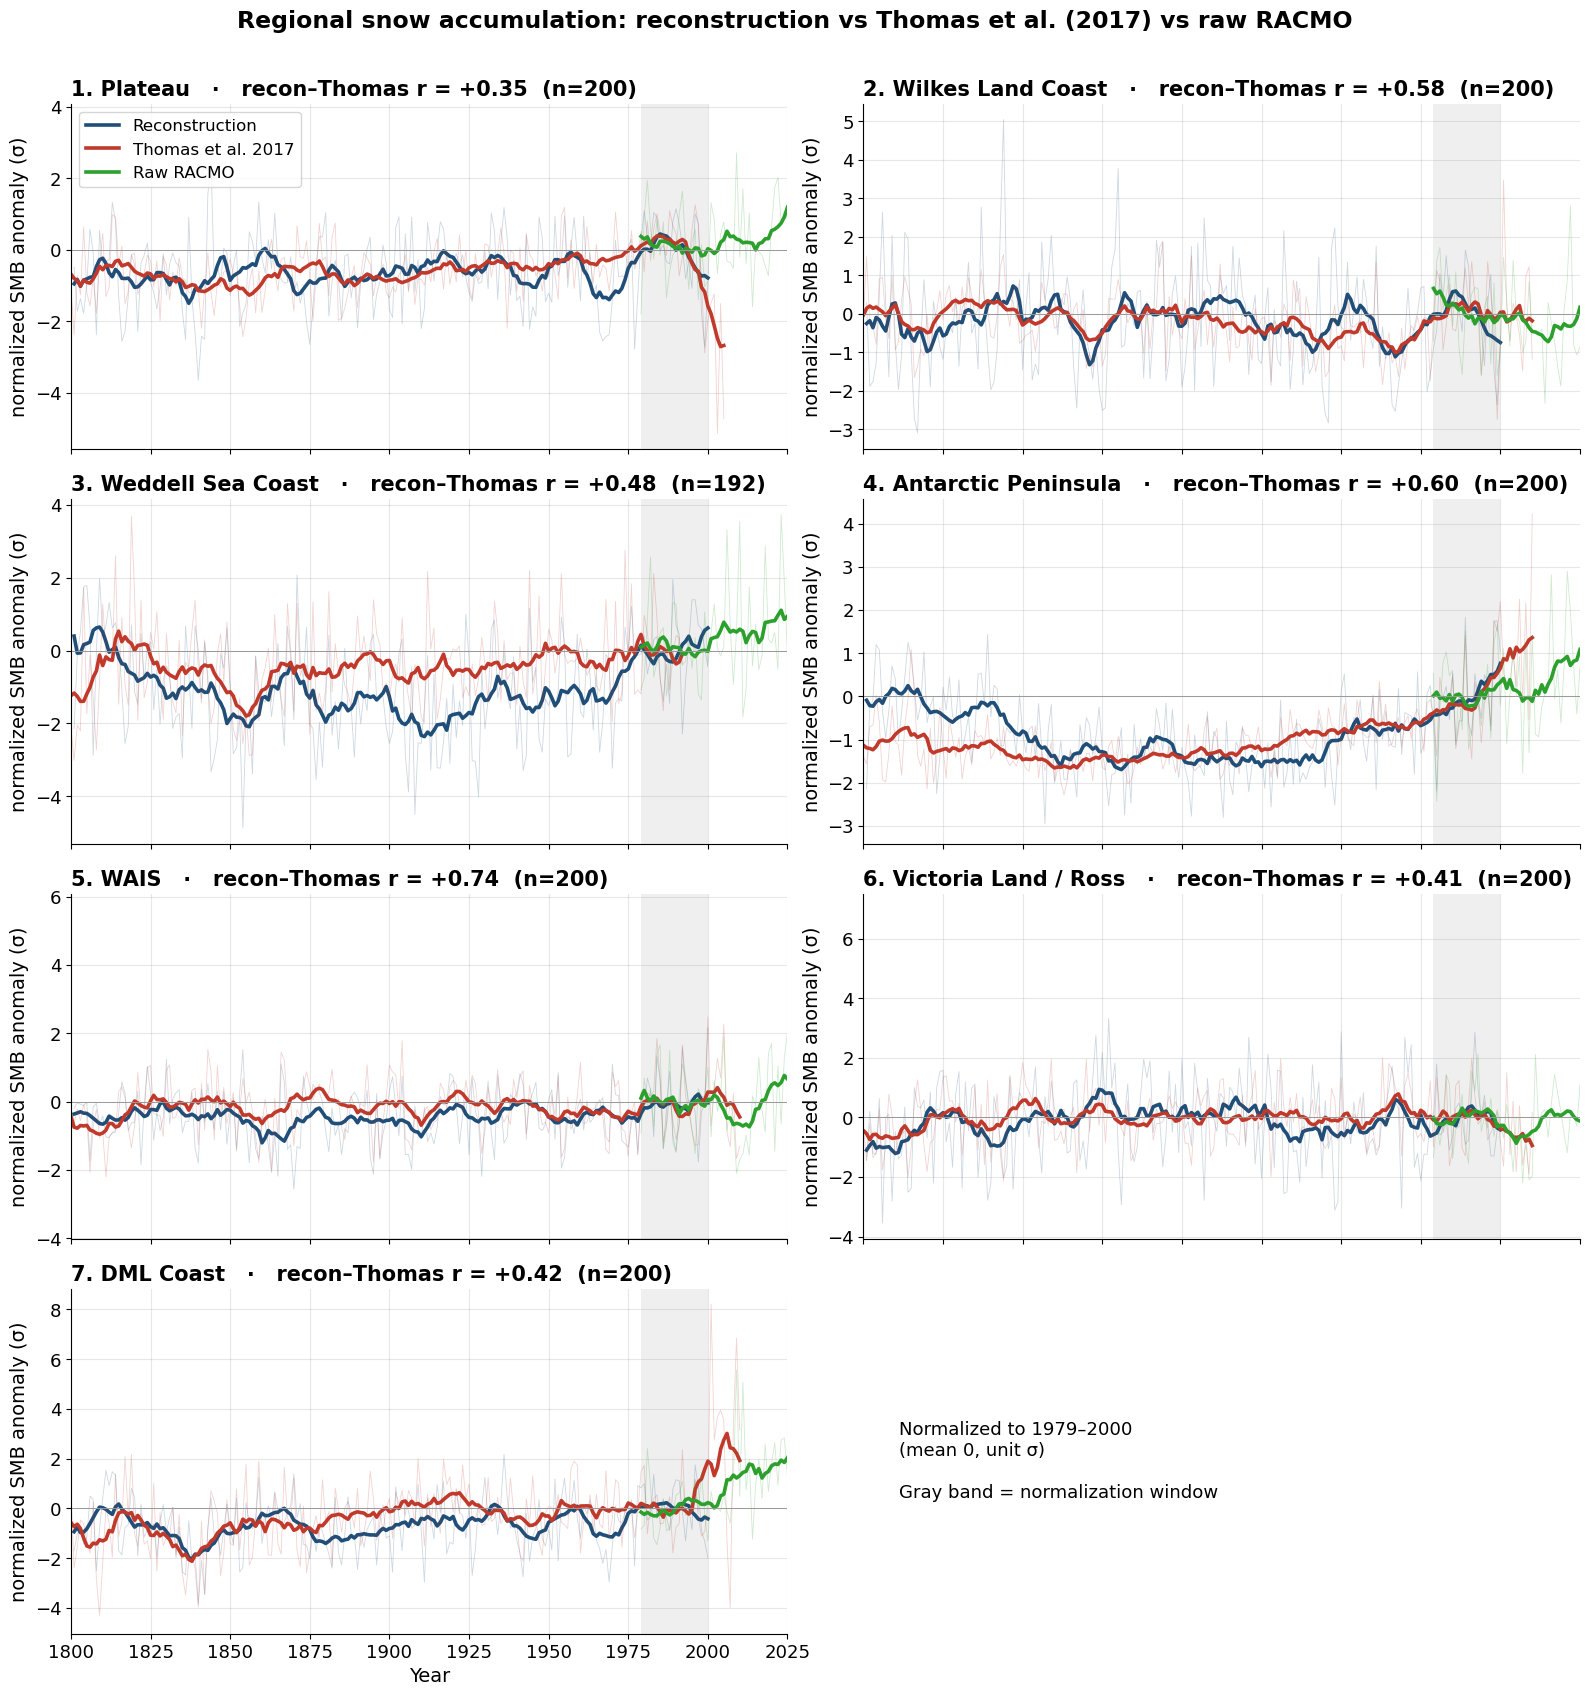

In [47]:
# ===== Compare Thomas et al. (2017) vs reconstruction vs raw RACMO, with recon–Thomas correlations =====
valid2d = valid_cells.reshape(NY, NX)
regmask = {r: (region_pages == r) & valid2d for r in range(1, 8)}
integ = lambda cube, r: (cube[:, regmask[r]] * cell_area_m2[regmask[r]]).sum(1) / 1e12
rec = {r: pd.Series(integ(racmo_smb_recon, r), index=recon_years) for r in range(1, 8)}
raw = {r: pd.Series(integ(smb_ann.values, r), index=years_obs)   for r in range(1, 8)}

tdf = pd.read_excel("/Users/advik/Downloads/ThomasComposites.xlsx", "Regional Composites", header=7)
tdf = tdf.rename(columns={"Site": "Year"})
tdf = tdf[pd.to_numeric(tdf["Year"], errors="coerce").notna()].copy()
tdf["Year"] = tdf["Year"].astype(int); tdf = tdf.set_index("Year").sort_index()
tcol = {int(c.split(".")[0]): c for c in tdf.columns if str(c)[0].isdigit()}
thomas = {r: pd.to_numeric(tdf[tcol[r]], errors="coerce") for r in range(1, 8)}

REF0, REF1 = 1979, 2000
def znorm(s):
    r = s.loc[REF0:REF1].dropna(); return (s - r.mean()) / r.std()
roll = lambda s, w=11: s.rolling(w, center=True, min_periods=6).mean()
C_REC, C_THO, C_RAC = "#1f4e79", "#c0392b", "#2ca02c"

print(f"{'reg':<26}{'r (annual)':>12}{'n':>6}")
fig, axes = plt.subplots(4, 2, figsize=(16, 17), sharex=True)
for ax, r in zip(axes.ravel(), range(1, 8)):
    both = pd.concat([rec[r].rename("rec"), thomas[r].rename("tho")], axis=1).dropna()   # common years
    rr = both["rec"].corr(both["tho"]); n = len(both)
    for s, c, lab in [(znorm(rec[r]), C_REC, "Reconstruction"),
                      (znorm(thomas[r]), C_THO, "Thomas et al. 2017"),
                      (znorm(raw[r]), C_RAC, "Raw RACMO")]:
        ax.plot(s.index, s.values, color=c, lw=0.6, alpha=0.22)
        ax.plot(roll(s).index, roll(s).values, color=c, lw=2.6, label=lab)
    ax.axhline(0, color="0.6", lw=0.7); ax.axvspan(REF0, REF1, color="0.85", alpha=0.4, lw=0, zorder=0)
    ax.set_title(f"{r}. {REGION_NAMES[r]}   ·   recon–Thomas r = {rr:+.2f}  (n={n})",
                 fontsize=15, fontweight="bold", loc="left")
    ax.set_ylabel("normalized SMB anomaly (σ)", fontsize=14)
    ax.tick_params(labelsize=13); ax.grid(alpha=0.3)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    print(f"{str(r)+'. '+REGION_NAMES[r]:<26}{rr:>12.2f}{n:>6}")
axes.ravel()[0].legend(fontsize=12, loc="upper left")
axes.ravel()[7].axis("off")
axes.ravel()[7].text(0.05, 0.5, "Normalized to 1979–2000\n(mean 0, unit σ)\n\nGray band = normalization window",
                     transform=axes.ravel()[7].transAxes, fontsize=13, va="center")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=14)
axes[0, 0].set_xlim(1800, 2025)
fig.suptitle("Regional snow accumulation: reconstruction vs Thomas et al. (2017) vs raw RACMO",
             fontsize=17, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.985]); plt.show()


region                      kappa    ToE
1. Plateau                   0.00   2009
2. Wilkes Land Coast         0.00   None
3. Weddell Sea Coast         0.57   None
4. Antarctic Peninsula       0.62   None
5. WAIS                      0.00   None
6. Victoria Land / Ross      0.00   None
7. DML Coast                 0.53   2011


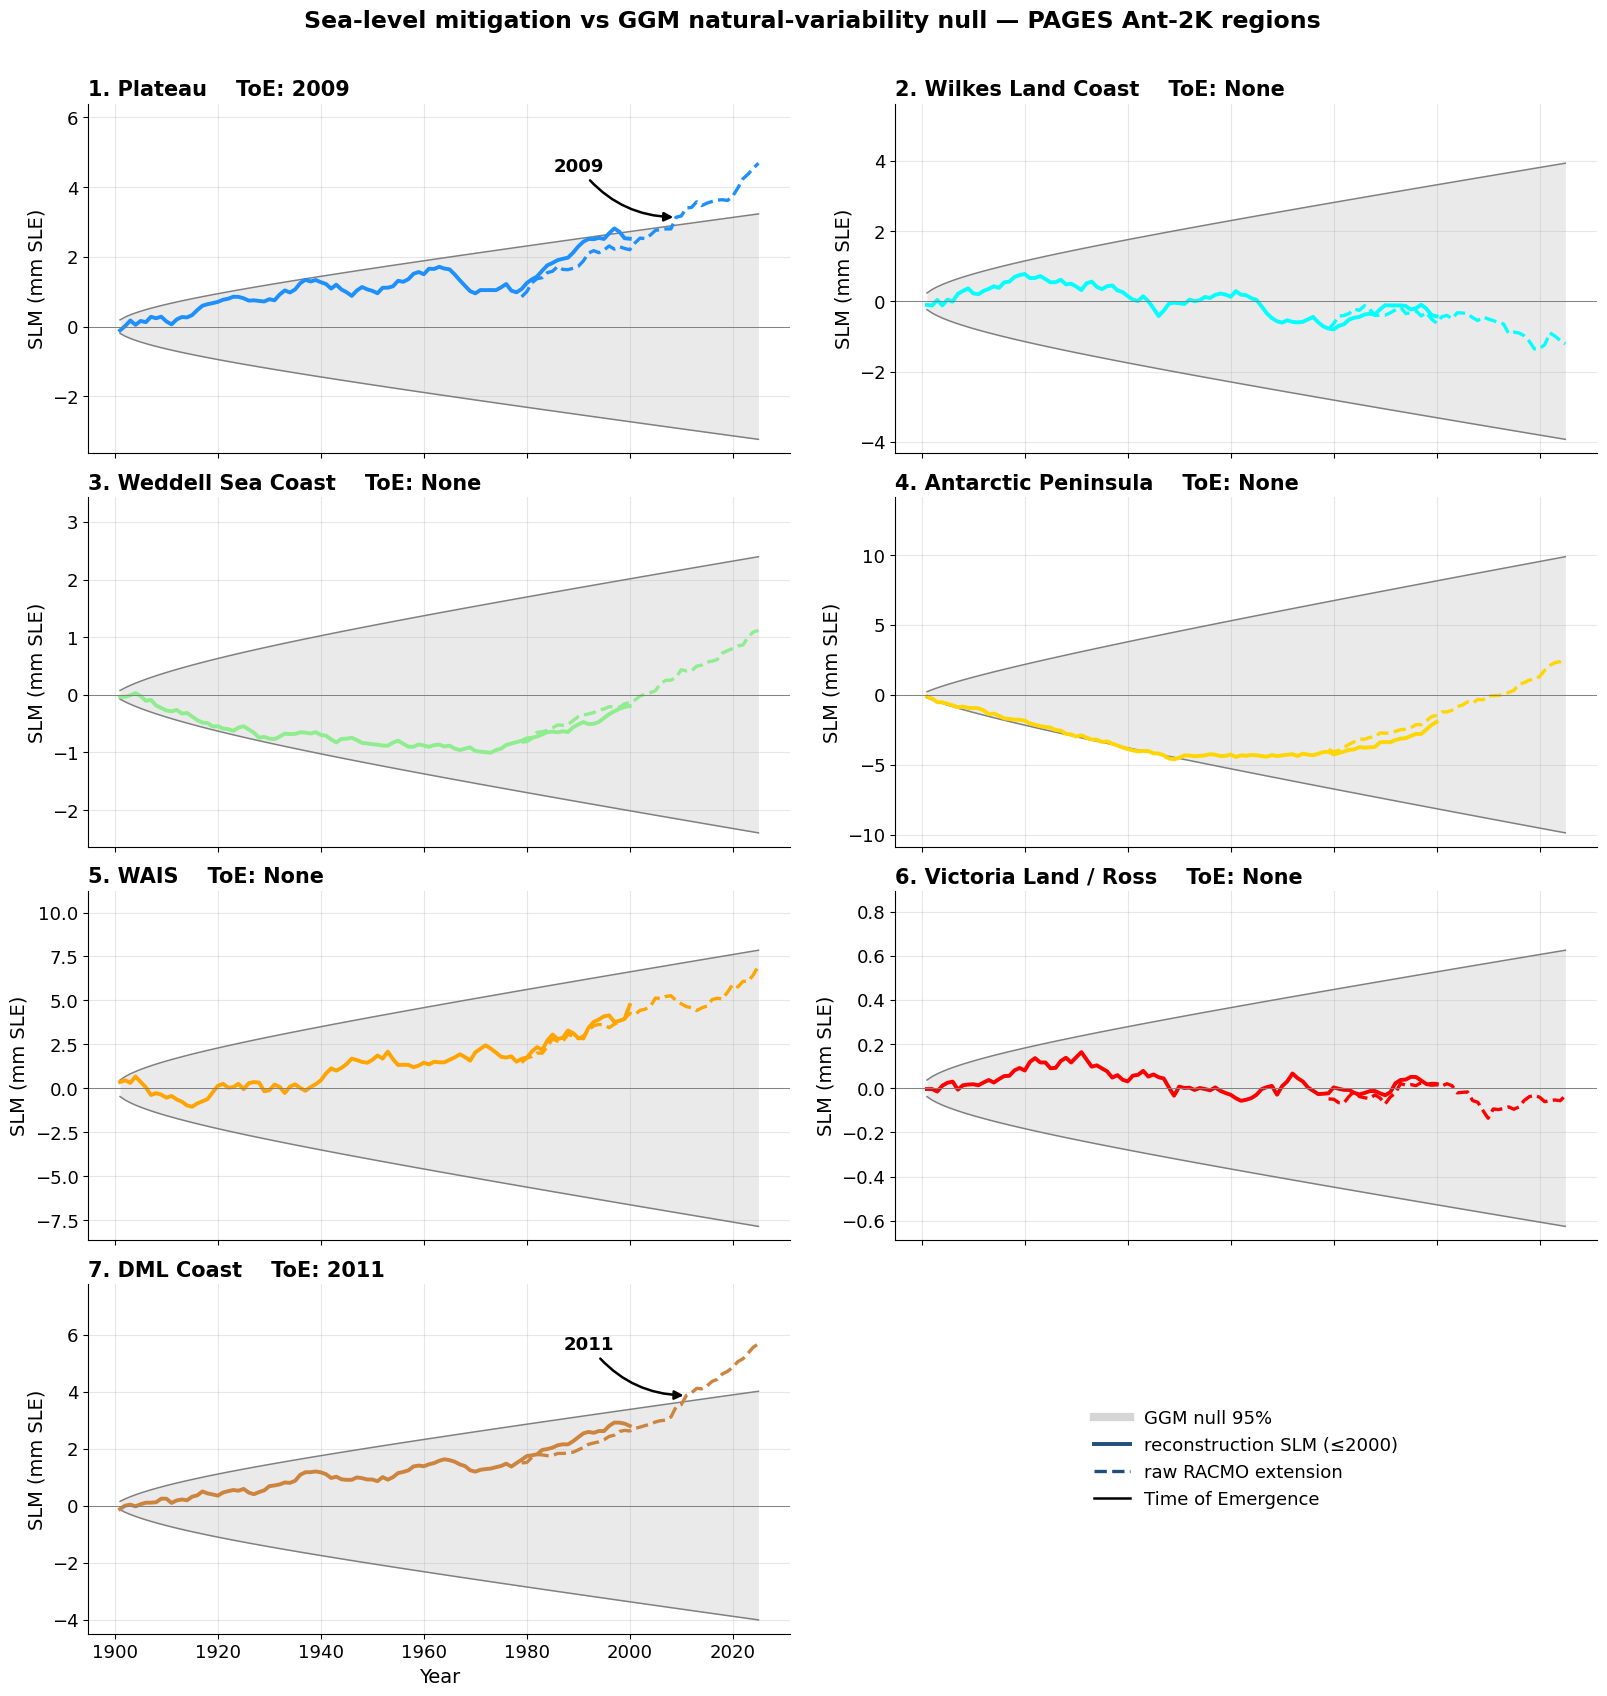

In [48]:
# ===== Sea-level mitigation vs GGM natural-variability null — 7 PAGES regions =====
GT, NB, NA = 361.8, 100, 125
valid2d = valid_cells.reshape(NY, NX)
regmask = {r: (region_pages == r) & valid2d for r in range(1, 8)}
integ = lambda cube, r: (cube[:, regmask[r]] * cell_area_m2[regmask[r]]).sum(1) / 1e12
rec = {r: pd.Series(integ(racmo_smb_recon, r), index=recon_years) for r in range(1, 8)}
raw = {r: pd.Series(integ(smb_ann.values, r), index=years_obs)   for r in range(1, 8)}

def sea_level_mitigation(ts, baseline=slice(0, 100)):
    ts = np.asarray(ts, float); return np.cumsum(ts - ts[baseline].mean()) / GT
def extend_slm(recon_ts, obs_ts, baseline=slice(0, 100)):
    r = np.asarray(recon_ts, float); base = r[baseline].mean(); cum = np.sum(r[:178] - base) / GT
    return cum + np.cumsum((np.asarray(obs_ts) - base) / GT)
def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB+NA) * fit["sigma_w"]**2)
    return np.array([np.sqrt((a := np.concatenate([np.full(NB,-n/NB),np.ones(n)])) @ R[:NB+n,:NB+n] @ a)/GT
                     for n in range(1, NA+1)])
def emergence(traj, sig, yy):
    out = traj > 1.96*sig
    for i in range(len(yy)):
        if out[i:].all(): return int(yy[i])
    return None

ggm_pages = {r: ggm_fit(rec[r].loc[1801:1900].values) for r in range(1, 8)}     # GGM fit to preindustrial recon
years, cent, yr_obs = np.arange(1901, 2026), np.arange(1901, 2001), np.arange(1979, 2026)

fig, axes = plt.subplots(4, 2, figsize=(16, 17), sharex=True)
print(f"{'region':<26}{'kappa':>7}{'ToE':>7}")
for ax, r in zip(axes.ravel(), range(1, 8)):
    col = REGION_COLORS[r-1]
    slm_recon = sea_level_mitigation(rec[r].values)
    slm_ext = extend_slm(rec[r].values, raw[r].values)
    sig = slm_sigma(ggm_pages[r]); traj = np.concatenate([slm_recon[100:178], slm_ext])
    toe = emergence(traj, sig, years)
    ax.fill_between(years, -1.96*sig, 1.96*sig, color="0.6", alpha=0.20, lw=0)
    ax.plot(years, 1.96*sig, color="0.5", lw=1.1); ax.plot(years, -1.96*sig, color="0.5", lw=1.1)
    ax.plot(cent, slm_recon[100:200], color=col, lw=2.8)
    ax.plot(yr_obs, slm_ext, color=col, lw=2.4, ls="--")
    if toe:
        yv = traj[toe-1901]
        ax.annotate(f"{toe}", xy=(toe, yv), xycoords="data", xytext=(-52, 30), textcoords="offset points",
                    ha="right", va="bottom", fontsize=13, fontweight="bold", color="black",
                    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.8, connectionstyle="arc3,rad=0.25"))
    ax.axhline(0, color="gray", lw=0.7)
    ax.set_title(f"{r}. {REGION_NAMES[r]}    ToE: {toe}", fontsize=15, fontweight="bold", loc="left")
    ax.set_ylabel("SLM (mm SLE)", fontsize=14); ax.tick_params(labelsize=13); ax.grid(alpha=0.3)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    lo_, hi_ = ax.get_ylim(); ax.set_ylim(lo_, hi_ + 0.15*(hi_-lo_))
    print(f"{str(r)+'. '+REGION_NAMES[r]:<26}{ggm_pages[r]['kappa']:>7.2f}{str(toe):>7}")
axes.ravel()[7].axis("off")
from matplotlib.lines import Line2D
axes.ravel()[7].legend(handles=[Line2D([0],[0], color="0.6", lw=6, alpha=0.4, label="GGM null 95%"),
                                Line2D([0],[0], color="#1f4e79", lw=2.8, label="reconstruction SLM (≤2000)"),
                                Line2D([0],[0], color="#1f4e79", lw=2.4, ls="--", label="raw RACMO extension"),
                                Line2D([0],[0], color="black", lw=1.8, label="Time of Emergence")],
                       loc="center", fontsize=13, frameon=False)
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=14)
fig.suptitle("Sea-level mitigation vs GGM natural-variability null — PAGES Ant-2K regions",
             fontsize=17, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.985]); plt.show()
